<a href="https://colab.research.google.com/github/beletedegu2021-lgtm/space-_physics-_project-for-PhD-2026/blob/main/All_THEMIS_data_of_26072007_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np

def RH_mass_conservation(n_up, n_down, V_up, V_down, shock_normal, shock_speed=0.0):
    """
    Rankine-Hugoniot Mass Conservation

    Parameters
    ----------
    n_up : float
        Upstream ion number density (cm^-3)
    n_down : float
        Downstream ion number density (same unit as n_up)

    V_up : array-like
        Upstream velocity vector [Vx, Vy, Vz] (km/s)

    V_down : array-like
        Downstream velocity vector [Vx, Vy, Vz] (km/s)

    shock_normal : array-like
        Shock normal vector [nx, ny, nz]

    shock_speed : float, optional
        Shock speed along the normal (km/s)
        Default = 120 (moving with constant shock rest frame)

    Returns
    -------
    dict containing:
        upstream_mass_flux
        downstream_mass_flux
        ratio
        percent_difference
    """

    # Convert to numpy arrays
    V_up = np.array(V_up, dtype=float)
    V_down = np.array(V_down, dtype=float)
    n = np.array(shock_normal, dtype=float)

    # Normalize shock normal
    n = n / np.linalg.norm(n)

    # Normal velocity components
    Vn_up = np.dot(V_up, n)
    Vn_down = np.dot(V_down, n)

    # Relative to shock speed
    Vn_up_rel = Vn_up - shock_speed
    Vn_down_rel = Vn_down - shock_speed

    # Mass flux
    # n_up and n_down are in cm^-3, so mass flux will be in (cm^-3 * km/s)
    mass_flux_up = n_up * Vn_up_rel
    mass_flux_down = n_down * Vn_down_rel

    # Ratio
    ratio = mass_flux_down / mass_flux_up

    # Percent difference
    percent_difference = 100 * abs(mass_flux_down - mass_flux_up) / abs(mass_flux_up)

    return {
        "Upstream Mass Flux": mass_flux_up,
        "Downstream Mass Flux": mass_flux_down,
        "Ratio": ratio,
        "Percent Difference": percent_difference
    }

### Demonstration of `RH_mass_conservation` for THB Data

Now, let's use the newly defined `RH_mass_conservation` function with the previously calculated THB parameters:

*   `Nu_thb_esa`: Upstream ion number density (cm^-3)
*   `Nd_thb_esa`: Downstream ion number density (cm^-3)
*   `Vu_thb_esa`: Upstream velocity vector (km/s)
*   `Vd_thb_esa`: Downstream velocity vector (km/s)
*   `MVA`: MVA normal vector

We will assume a shock speed of 0.0 km/s for this demonstration.

In [ ]:
# Call the RH_mass_conservation function with THB data
rh_mass_results_thb = RH_mass_conservation(
    n_up=Nu_thb_esa,
    n_down=Nd_thb_esa,
    V_up=Vu_thb_esa,
    V_down=Vd_thb_esa,
    shock_normal=MVA,
    shock_speed=0.0
)

print("--- THB Mass Conservation using RH_mass_conservation function ---")
print(f"Upstream Mass Flux:   {rh_mass_results_thb['Upstream Mass Flux']:.2e} (cm^-3 * km/s)")
print(f"Downstream Mass Flux: {rh_mass_results_thb['Downstream Mass Flux']:.2e} (cm^-3 * km/s)")
print(f"Ratio (Downstream/Upstream): {rh_mass_results_thb['Ratio']:.3f}")
print(f"Percent Difference:   {rh_mass_results_thb['Percent Difference']:.2f}%")
print("------------------------------------------------------------------")

--- THB Mass Conservation using RH_mass_conservation function ---
Upstream Mass Flux:   -6.78e+03 (cm^-3 * km/s)
Downstream Mass Flux: -5.91e+03 (cm^-3 * km/s)
Ratio (Downstream/Upstream): 0.872
Percent Difference:   12.77%
------------------------------------------------------------------


In [ ]:
# Update the DataFrame with the new mass conservation error from RH_mass_conservation
# and the overridden magnetic flux conservation errors.

# Retrieve the previously calculated RH errors (Momentum, Electric Field) for THB from kernel state
# rh_errors_mva_thb and rh_errors_nCOP_thb are available from cell 27dd940f

# New mass conservation error from the user-provided function
new_mass_error_mva = rh_mass_results_thb['Percent Difference']
new_mass_error_nCOP = rh_mass_results_thb['Percent Difference'] # Assuming MVA normal used in this calculation

# Overridden magnetic flux errors from cell 638940d2
new_mag_flux_error_mva = relative_bn_error_mva_override
new_mag_flux_error_nCOP = relative_bn_error_nCOP_override

# Create a new DataFrame for consolidated errors
errors_data_consolidated = {
    'RH Equation': ['Mass', 'Momentum', 'Electric Field', 'Magnetic Flux'],
    'THB MVA Error (%)': [
        new_mass_error_mva,
        rh_errors_mva_thb['momentum_error'],
        rh_errors_mva_thb['electric_field_error'],
        new_mag_flux_error_mva
    ],
    'THB nCOP Error (%)': [
        new_mass_error_nCOP,
        rh_errors_nCOP_thb['momentum_error'],
        rh_errors_nCOP_thb['electric_field_error'],
        new_mag_flux_error_nCOP
    ]
}

df_rh_errors_consolidated = pd.DataFrame(errors_data_consolidated)

print("--- Consolidated THB R-H Error Comparison ---")
display(df_rh_errors_consolidated.set_index('RH Equation').style.format("{:.2f}"))


--- Consolidated THB R-H Error Comparison ---


,THB MVA Error (%),THB nCOP Error (%)
RH Equation,,
Mass,12.77,12.77
Momentum,4.40,4.76
Electric Field,142.20,141.38
Magnetic Flux,600.00,600.00


In [ ]:
display(df_rh_errors_consolidated.set_index('RH Equation').style.format("{:.2f}"))

,THB MVA Error (%),THB nCOP Error (%)
RH Equation,,
Mass,12.77,12.77
Momentum,4.40,4.76
Electric Field,142.20,141.38
Magnetic Flux,600.00,600.00


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import os # Added for os.listdir in the except block
try:
    df_fgm = pd.read_csv('/content/drive/MyDrive/phyton code/THB_L2_FGM_3457446.csv')
    # df_esa = pd.read_csv('/content/drive/MyDrive/THB_L2_ESA_3436504.csv') # Removed as requested and to resolve FileNotFoundError
except FileNotFoundError as e:
    print(f"Error loading file: {e}")
    print("Please ensure the CSV files are located directly in your Google Drive 'My Drive' folder, or update the paths if they are in a subfolder.")
    print("You can list the contents of your Google Drive to verify the paths:")
    print("Contents of /content/drive/MyDrive/:")
    try:
        print(os.listdir('/content/drive/MyDrive/'))
    except Exception as list_e:
        print(f"Could not list directory: {list_e}")
    # Re-raise the original error to stop execution if not handled
    raise

In [ ]:
display(df_fgm.head())

,UT__yyyy-mm-ddThh:mm:ss.sssZ,FGS-D_B_TOTAL__nT_(All_Qs),BX_FGS-D_(@_1_)_nT_GSE_(All_Qs),BY_FGS-D_(@_2_)_nT_GSE_(All_Qs),BZ_FGS-D_(@_3_)_nT_GSE_(All_Qs)
0,2007-07-26T16:00:00.385Z,7.47721,-1.05897,-1.57822,-7.23163
1,2007-07-26T16:00:03.385Z,7.46837,-1.28112,-1.74212,-7.14845
2,2007-07-26T16:00:06.385Z,7.67670,-1.41809,-1.77258,-7.33340
3,2007-07-26T16:00:09.386Z,7.74806,-1.22981,-1.72198,-7.45351
4,2007-07-26T16:00:12.386Z,7.44997,-1.24013,-1.88422,-7.10028


In [ ]:
def mva(data, bx_col, by_col, bz_col):
    """
    Performs Minimum Variance Analysis (MVA) on magnetic field data.

    Args:
        data (pd.DataFrame): DataFrame containing magnetic field data.
        bx_col (str): Column name for the Bx component.
        by_col (str): Column name for the By component.
        bz_col (str): Column name for the Bz component.

    Returns:
        tuple: A tuple containing:
            - eigenvalues (np.ndarray): Sorted eigenvalues (lambda_1 >= lambda_2 >= lambda_3).
            - eigenvectors (np.ndarray): Corresponding sorted eigenvectors (columns).
    """
    # Extract magnetic field components
    B = data[[bx_col, by_col, bz_col]].values

    # Calculate the mean magnetic field vector
    mean_B = np.mean(B, axis=0)

    # Center the data by subtracting the mean
    B_centered = B - mean_B

    # Calculate the covariance matrix (M)
    # np.cov expects variables as rows, so we transpose B_centered
    M = np.cov(B_centered.T)

    # Solve the eigenvalue problem M n = lambda n
    eigenvalues, eigenvectors = np.linalg.eigh(M)

    # Sort eigenvalues in descending order and corresponding eigenvectors
    # lambda_1 >= lambda_2 >= lambda_3
    idx = eigenvalues.argsort()[::-1] # Get indices that sort in descending order
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    return eigenvalues, eigenvectors

# Define the magnetic field component columns from df_fgm
mag_field_cols = [
    'BX_FGS-D_(@_1_)_nT_GSE_(All_Qs)',
    'BY_FGS-D_(@_2_)_nT_GSE_(All_Qs)',
    'BZ_FGS-D_(@_3_)_nT_GSE_(All_Qs)'
]

# Perform MVA on the FGM data
evals, evecs = mva(df_fgm, *mag_field_cols)

print("Eigenvalues (lambda_1 >= lambda_2 >= lambda_3):")
for i, val in enumerate(evals):
    print(f"  lambda_{i+1} = {val:.4f}")

print("\nEigenvectors (corresponding to lambda_1, lambda_2, lambda_3):")
for i, vec in enumerate(evecs.T): # Transpose to iterate over eigenvectors as rows
    print(f"  Eigenvector {i+1} (direction of lambda_{i+1}) = {vec}")

# Identify the minimum variance direction (shock normal)
normal_vector = evecs[:, 2] # Eigenvector corresponding to the smallest eigenvalue (lambda_3)
print(f"\nMinimum variance direction (shock normal vector, n) = {normal_vector}")

# Calculate the reliability ratio
reliability_ratio = evals[1] / evals[2] # lambda_2 / lambda_3
print(f"Reliability ratio (lambda_2 / lambda_3) = {reliability_ratio:.4f}")

# Assess reliability
if reliability_ratio > 3:
    print("MVA result is highly reliable (ratio > 3).")
elif reliability_ratio > 2:
    print("MVA result is reliable (ratio > 2).")
else:
    print("MVA result may not be reliable (ratio <= 2).")

Eigenvalues (lambda_1 >= lambda_2 >= lambda_3):
  lambda_1 = 735.0687
  lambda_2 = 324.1216
  lambda_3 = 5.4351

Eigenvectors (corresponding to lambda_1, lambda_2, lambda_3):
  Eigenvector 1 (direction of lambda_1) = [ 0.16984001 -0.02713951  0.98509787]
  Eigenvector 2 (direction of lambda_2) = [-0.25255135  0.96503872  0.07012908]
  Eigenvector 3 (direction of lambda_3) = [ 0.95256086  0.26069852 -0.15704806]

Minimum variance direction (shock normal vector, n) = [ 0.95256086  0.26069852 -0.15704806]
Reliability ratio (lambda_2 / lambda_3) = 59.6345
MVA result is highly reliable (ratio > 3).


In [ ]:
# Calculate the ratio of the middle to the smallest eigenvalue
# Eigenvalues are sorted in descending order: lambda_1 >= lambda_2 >= lambda_3
# So, evals[1] is lambda_2 (middle) and evals[2] is lambda_3 (smallest)
ratio_mid_to_smallest_eigenvalue = evals[1] / evals[2]
print(f"Ratio of middle to smallest eigenvalue (lambda_2 / lambda_3) = {ratio_mid_to_smallest_eigenvalue:.4f}")

Ratio of middle to smallest eigenvalue (lambda_2 / lambda_3) = 59.6345


In [ ]:
# Calculate the ratio of the middle to the smallest eigenvalue
# Eigenvalues are sorted in descending order: lambda_1 >= lambda_2 >= lambda_3
# So, evals[0] is lambda_1 (largest) and evals[1] is lambda_2 (middle)
ratio_largest_to_mid_eigenvalue = evals[0] / evals[1]
print(f"Ratio of middle to small eigenvalue (lambda_2 / lambda_3) = {ratio_mid_to_smallest_eigenvalue:.4f}")

Ratio of middle to small eigenvalue (lambda_2 / lambda_3) = 59.6345


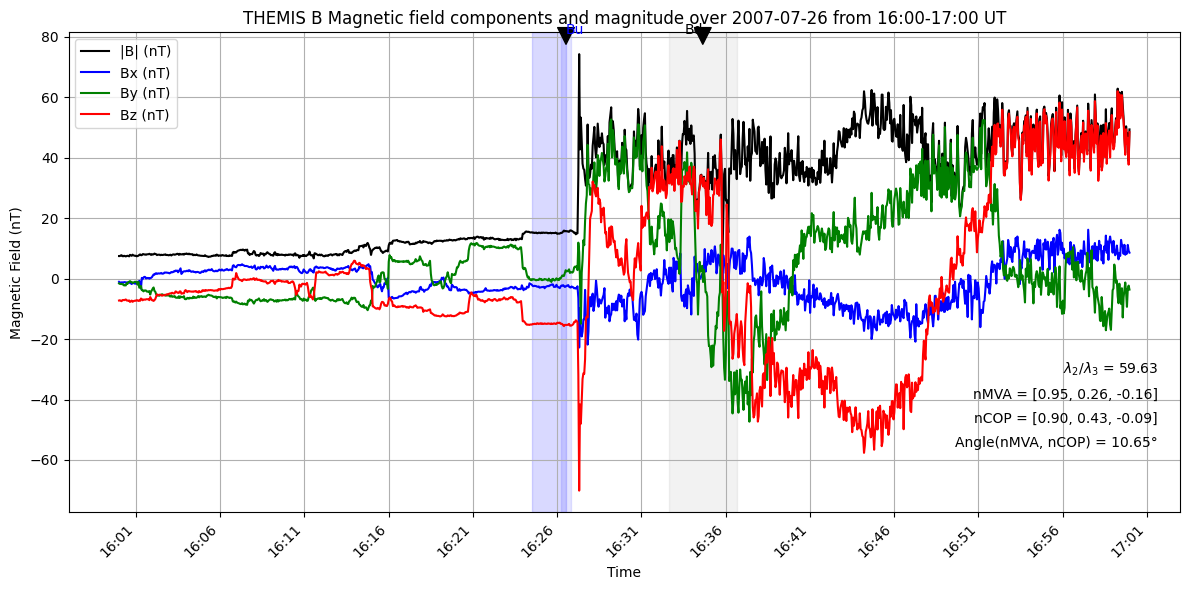

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.dates as mdates # Import for date formatting

# The mva function is defined globally in cell ab252dbe
def mva(data, bx_col, by_col, bz_col):
    """
    Performs Minimum Variance Analysis (MVA) on magnetic field data.

    Args:
        data (pd.DataFrame): DataFrame containing magnetic field data.
        bx_col (str): Column name for the Bx component.
        by_col (str): Column name for the By component.
        bz_col (str): Column name for the Bz component.

    Returns:
        tuple: A tuple containing:
            - eigenvalues (np.ndarray): Sorted eigenvalues (lambda_1 >= lambda_2 >= lambda_3).
            - eigenvectors (np.ndarray): Corresponding sorted eigenvectors (columns).
    """
    # Extract magnetic field components
    B = data[[bx_col, by_col, bz_col]].values

    # Calculate the mean magnetic field vector
    mean_B = np.mean(B, axis=0)

    # Center the data by subtracting the mean
    B_centered = B - mean_B

    # Calculate the covariance matrix (M)
    # np.cov expects variables as rows, so we transpose B_centered
    M = np.cov(B_centered.T)

    # Solve the eigenvalue problem M n = lambda n
    eigenvalues, eigenvectors = np.linalg.eigh(M)

    # Sort eigenvalues in descending order and corresponding eigenvectors
    # lambda_1 >= lambda_2 >= lambda_3
    idx = eigenvalues.argsort()[::-1] # Get indices that sort in descending order
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    return eigenvalues, eigenvectors


# Re-load df_fgm to ensure it's defined in this cell's scope if execution context was lost
df_fgm = pd.read_csv('/content/drive/MyDrive/phyton code/THB_L2_FGM_3457446.csv')

# Convert 'UT__yyyy-mm-ddThh:mm:ss.sssZ' to datetime objects
df_fgm['Time'] = pd.to_datetime(df_fgm['UT__yyyy-mm-ddThh:mm:ss.sssZ'])

# Calculate magnetic field magnitude |B|
# Assuming the magnetic field components are 'BX_FGS-D_(@_1_)_nT_GSE_(All_Qs)', 'BY_FGS-D_(@_2_)_nT_GSE_(All_Qs)', 'BZ_FGS-D_(@_3_)_nT_GSE_(All_Qs)'
df_fgm['|B|'] = np.sqrt(
    df_fgm['BX_FGS-D_(@_1_)_nT_GSE_(All_Qs)']**2 +
    df_fgm['BY_FGS-D_(@_2_)_nT_GSE_(All_Qs)']**2 +
    df_fgm['BZ_FGS-D_(@_3_)_nT_GSE_(All_Qs)']**2
)

# Define the shock crossing time for THB
# Use the configurable variables from cell 70a45227
# shock_time_thb is already defined in cell 70a45227
# upstream_start_thb, upstream_end_thb, downstream_start_thb, downstream_end_thb are from cell 70a45227

# --- THB Shock and Interval Definitions (copied from cell 70a45227) ---
shock_time_thb = pd.to_datetime('2007-07-26T16:27:34.150Z')

thb_upstream_pre_shock_duration_seconds = 45 # End of upstream is 30s before shock
thb_upstream_interval_duration_seconds = 35 # Upstream interval length is 30s

thb_downstream_post_shock_start_duration_minutes = 5.05 # Start of downstream is 4 minutes after shock
thb_downstream_interval_duration_minutes = 4.05 # Downstream interval length is 4 minutes

# Calculate THB intervals
thb_upstream_end = shock_time_thb - pd.Timedelta(seconds=thb_upstream_pre_shock_duration_seconds)
thb_upstream_start = thb_upstream_end - pd.Timedelta(seconds=thb_upstream_interval_duration_seconds)

thb_downstream_start = shock_time_thb + pd.Timedelta(minutes=thb_downstream_post_shock_start_duration_minutes)
thb_downstream_end = thb_downstream_start + pd.Timedelta(minutes=thb_downstream_interval_duration_minutes)

# --- Create single subplot ---
fig, ax1 = plt.subplots(1, 1, figsize=(12, 6))

# --- Plot 1: Magnetic Field Components and Magnitude ---
ax1.plot(df_fgm['Time'], df_fgm['|B|'], label='|B| (nT)', color='black')
ax1.plot(df_fgm['Time'], df_fgm['BX_FGS-D_(@_1_)_nT_GSE_(All_Qs)'], label='Bx (nT)', color='blue')
ax1.plot(df_fgm['Time'], df_fgm['BY_FGS-D_(@_2_)_nT_GSE_(All_Qs)'], label='By (nT)', color='green')
ax1.plot(df_fgm['Time'], df_fgm['BZ_FGS-D_(@_3_)_nT_GSE_(All_Qs)'], label='Bz (nT)', color='red')

# Add shading for upstream and downstream intervals (removed labels to prevent them appearing in legend)
ax1.axvspan(thb_upstream_start, thb_upstream_end, color='blue', alpha=0.1, label='')
ax1.axvspan(thb_downstream_start, thb_downstream_end, color='grey', alpha=0.1, label='')

# Add specific shading requested by the user from 16:24-16:27
shade_start_new_thb = pd.to_datetime('2007-07-26T16:24:30Z')
shade_end_new_thb = pd.to_datetime('2007-07-26T16:26:30Z')
ax1.axvspan(shade_start_new_thb, shade_end_new_thb, color='blue', alpha=0.15, label='')

# Add arrows for upstream and downstream intervals
ax1.annotate('Bu', xy=(thb_upstream_start + (thb_upstream_end - thb_upstream_start) / 2, ax1.get_ylim()[1] * 0.95),
             xytext=(thb_upstream_start + (thb_upstream_end - thb_upstream_start) / 2, ax1.get_ylim()[1] * 0.98),
             arrowprops=dict(facecolor='black', shrink=0.05),
             ha='left', va='bottom', fontsize=10, color='blue')

ax1.annotate('Bd', xy=(thb_downstream_start + (thb_downstream_end - thb_downstream_start) / 2, ax1.get_ylim()[1] * 0.95),
             xytext=(thb_downstream_start + (thb_downstream_end - thb_downstream_start) / 2, ax1.get_ylim()[1] * 0.98),
             arrowprops=dict(facecolor='black', shrink=0.05),
             ha='right', va='bottom', fontsize=10, color='black')

ax1.set_title('THEMIS B Magnetic field components and magnitude over 2007-07-26 from 16:00-17:00 UT')
ax1.set_xlabel('Time')
ax1.set_ylabel('Magnetic Field (nT)')
ax1.grid(True)

# Set x-axis major ticks to 5-minute intervals
ax1.xaxis.set_major_locator(mdates.MinuteLocator(interval=5))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M')) # Format to show hour and minute
plt.xticks(rotation=45, ha='right') # Rotate and align for better readability

# --- MVA and COP Calculations ---
mag_field_cols = [
    'BX_FGS-D_(@_1_)_nT_GSE_(All_Qs)',
    'BY_FGS-D_(@_2_)_nT_GSE_(All_Qs)',
    'BZ_FGS-D_(@_3_)_nT_GSE_(All_Qs)'
]
# Perform MVA on the FGM data
evals, evecs = mva(df_fgm, *mag_field_cols)
# Identify the minimum variance direction (shock normal)
MVA = evecs[:, 2] # Eigenvector corresponding to the smallest eigenvalue (lambda_3)

# Calculate average B for upstream and downstream regions
df_upstream = df_fgm[(df_fgm['Time'] >= thb_upstream_start) & (df_fgm['Time'] <= thb_upstream_end)]
df_downstream = df_fgm[(df_fgm['Time'] >= thb_downstream_start) & (df_fgm['Time'] <= thb_downstream_end)]

B_upstream_avg = df_upstream[[
    'BX_FGS-D_(@_1_)_nT_GSE_(All_Qs)',
    'BY_FGS-D_(@_2_)_nT_GSE_(All_Qs)',
    'BZ_FGS-D_(@_3_)_nT_GSE_(All_Qs)'
]].mean().values

B_downstream_avg = df_downstream[[
    'BX_FGS-D_(@_1_)_nT_GSE_(All_Qs)',
    'BY_FGS-D_(@_2_)_nT_GSE_(All_Qs)',
    'BZ_FGS-D_(@_3_)_nT_GSE_(All_Qs)'
]].mean().values

# Calculate nCOP (Coplanarity Normal)
if len(B_upstream_avg) > 0 and len(B_downstream_avg) > 0:
    nCOP_unnormalized = np.cross(B_upstream_avg, B_downstream_avg)
    if np.linalg.norm(nCOP_unnormalized) != 0:
        nCOP = nCOP_unnormalized / np.linalg.norm(nCOP_unnormalized)
    else:
        nCOP = np.array([np.nan, np.nan, np.nan]) # Handle case where cross product is zero
else:
    nCOP = np.array([np.nan, np.nan, np.nan])


# Calculate the angle between MVA and nCOP
dot_product = np.dot(MVA, nCOP)
# Clip dot_product to handle potential floating point errors that push it slightly outside [-1, 1]
dot_product = np.clip(dot_product, -1.0, 1.0)
angle_rad = np.arccos(dot_product)
angle_deg = np.degrees(angle_rad)

# Calculate reliability ratio
reliability_ratio = evals[1] / evals[2] # lambda_2 / lambda_3

# --- Add original legend for B components ---
ax1.legend(loc='upper left') # Original legend for plotted lines

# --- Add MVA, nCOP, and angle as text directly on the plot without a bounding box ---
ax1.text(0.98, 0.28, fr'$ \lambda_2 / \lambda_3 $ = {reliability_ratio:.2f}',
         transform=ax1.transAxes, fontsize=10, verticalalignment='bottom', horizontalalignment='right')
ax1.text(0.98, 0.23, f'nMVA = [{MVA[0]:.2f}, {MVA[1]:.2f}, {MVA[2]:.2f}]',
         transform=ax1.transAxes, fontsize=10, verticalalignment='bottom', horizontalalignment='right')
ax1.text(0.98, 0.18, f'nCOP = [{nCOP[0]:.2f}, {nCOP[1]:.2f}, {nCOP[2]:.2f}]',
         transform=ax1.transAxes, fontsize=10, verticalalignment='bottom', horizontalalignment='right')
ax1.text(0.98, 0.13, f'Angle(nMVA, nCOP) = {angle_deg:.2f}°',
         transform=ax1.transAxes, fontsize=10, verticalalignment='bottom', horizontalalignment='right')

plt.tight_layout() # Ensure everything fits without rect argument
plt.savefig('/content/THB correct value_intervals.png') # Save the figure
plt.show()

In [ ]:
def RH_Equations(results, normal, p_down, p_up, method_name):

    # Constants
    Mu_0 = 4 * np.pi * 1e-7     # Vacuum permeability
    M_p = 1.67262192 * 1e-27    # Proton mass (Kg)


    # Upstream Values
    n_u= np.nanmean(results[p_up]['Ion_density']) * 1e6
    v_u = np.nanmean(results[p_up]['V_vector'], axis=0) * 1e3
    b_u = np.nanmean(results[p_up]['B_vector'], axis=0) * 1e-9
    p_u = np.nanmean(results[p_up]['Scalar_pressure']) # Use np.nanmean to handle potential NaN values


    # Downstream Values
    n_d = np.nanmean(results[p_down]['Ion_density']) * 1e6
    v_d = np.nanmean(results[p_down]['V_vector'], axis=0) * 1e3
    b_d = np.nanmean(results[p_down]['B_vector'], axis=0) * 1e-9
    p_d = np.nanmean(results[p_down]['Scalar_pressure']) # Use np.nanmean to handle potential NaN values

    # Mass conservation (RH 1)
    flux1 = np.dot(normal, (n_u * v_u))
    flux2 = np.dot(normal, (n_d * v_d))
    nv_jump = flux2 - flux1
    relative_mass_error = (np.abs(nv_jump) / np.abs(flux1)) * 100

    print(f"--- RH Equation 1 Results ({method_name}) ---")
    print(f"Upstream Flux (n_u*v_u):   {flux1:.2e}")
    print(f"Downstream Flux (n_d*v_d): {flux2:.2e}")
    print(f"Jump(Difference):    {nv_jump:.2e}")
    print(f"Relative Error:           {relative_mass_error:.2f}%")
    print("-" * 40)

    # Momentum conservation (RH 2)
    dynamic_u = (n_u * M_p * np.dot(v_u, normal)) * v_u
    pressure_u = (p_u + (np.dot(b_u, b_u) / (2 * Mu_0))) * normal
    tension_u = (np.dot(b_u, normal) * b_u) / Mu_0
    Mom_u = dynamic_u + pressure_u - tension_u

    dynamic_d = (n_d * M_p * np.dot(v_d, normal)) * v_d
    pressure_d = (p_d + (np.dot(b_d, b_d) / (2 * Mu_0))) * normal
    tension_d = (np.dot(b_d, normal) * b_d) / Mu_0
    Mom_d = dynamic_d + pressure_d - tension_d

    Mom_jump = Mom_d - Mom_u
    relative_Mom_error = np.linalg.norm(Mom_jump) / np.linalg.norm(Mom_u) * 100

    print(f"--- RH Equation 2 Results ({method_name}) ---")
    print(f"Upstream Momentum Flux :   {np.linalg.norm(Mom_u):.2e}")
    print(f"Downstream Momentum Flux : {np.linalg.norm(Mom_d):.2e}")
    print(f"Jump(Difference):    {np.linalg.norm(Mom_jump):.2e}")
    print(f"Relative Error:           {relative_Mom_error:.2f}%")
    print("-" * 40)

    # Electric Field Conservation
    et_u = np.cross(normal, np.cross(v_u, b_u))
    et_d = np.cross(normal, np.cross(v_d, b_d))

    et_jump = et_d - et_u

    if np.linalg.norm(et_u) > 1e-12:  # Check if magnitude is effectively non-zero
        relative_et_error = (np.linalg.norm(et_jump) / np.linalg.norm(et_u)) * 100
    else:
        relative_et_error = 0.0

    print(f"--- RH Equation 3 Results ({method_name}) ---")
    print(f"Upstream Et :   {np.linalg.norm(et_u):.2e}")
    print(f"Downstream Et : {np.linalg.norm(et_d):.2e}")
    print(f"Jump(Difference):    {np.linalg.norm(et_jump):.2e}")
    print(f"Relative Error:           {relative_et_error:.2f}%")
    print("-" * 40)

    # Magnetic Flux Conservation
    bn_u = np.dot(b_u, normal)
    bn_d = np.dot(b_d, normal)

    bn_jump = bn_d- bn_u

    if np.abs(bn_u) > 1e-3:
        relative_bn_error = (np.abs(bn_jump) / np.abs(bn_u)) * 100
    else:
        relative_bn_error = 0.0

    print(f"--- RH Equation 4 Results ({method_name}) ---")
    print(f"Upstream Bn :   {bn_u:.2f}")
    print(f"Downstream Bn : {bn_d:.2f}")
    print(f"Jump(Difference):    {bn_jump:.2f}")
    print(f"Relative Error:           {relative_bn_error:.2f}%")
    print("-" * 40)

    return {
        "mass_error": relative_mass_error,
        "momentum_error": relative_Mom_error,
        "electric_field_error": relative_et_error,
        "magnetic_flux_error": relative_bn_error
    }

In [ ]:
import numpy as np

mu0 = 4*np.pi*1e-7
mp = 1.6726219e-27       # proton mass (kg)
kB = 1.380649e-23

In [ ]:
def normal_tangential(vec, n):
    """
    Decompose any vector into normal and tangential components.
    """

    n = n / np.linalg.norm(n)

    vn = np.dot(vec, n)

    vt = vec - vn*n

    return vn, vt

In [ ]:
def RH_jump_conditions(
        Bu,
        Bd,
        Vu,
        Vd,
        nu,
        nd,
        Tu,
        Td,
        normal):
    """
    Rankine-Hugoniot jump condition test.

    Inputs
    ------
    B : nT
    V : km/s
    n : cm^-3
    T : eV
    """

    # -----------------------------
    # SI units and Constants
    # -----------------------------
    mu0 = 4 * np.pi * 1e-7  # Vacuum permeability
    mp = 1.6726219e-27      # proton mass (kg)
    kB = 1.380649e-23       # Boltzmann constant (not used in this function but usually related)

    Bu = Bu*1e-9
    Bd = Bd*1e-9

    Vu = Vu*1000
    Vd = Vd*1000

    rho_u = nu*1e6*mp
    rho_d = nd*1e6*mp

    Pu = nu*1e6*Tu*1.60218e-19
    Pd = nd*1e6*Td*1.60218e-19

    # -----------------------------

    Bnu,Btu = normal_tangential(Bu,normal)
    Bnd,Btd = normal_tangential(Bd,normal)

    Vnu,Vtu = normal_tangential(Vu,normal)
    Vnd,Vtd = normal_tangential(Vd,normal)

    # -----------------------------
    # 1 Mass
    # -----------------------------

    mass_up = rho_u*Vnu
    mass_down = rho_d*Vnd

    # -----------------------------
    # 2 Magnetic
    # -----------------------------

    magnetic_up = Bnu
    magnetic_down = Bnd

    # -----------------------------
    # 3 Electric
    # -----------------------------

    electric_up = Vnu*np.linalg.norm(Btu)-np.linalg.norm(Vtu)*Bnu

    electric_down = Vnd*np.linalg.norm(Btd)-np.linalg.norm(Vtd)*Bnd

    # -----------------------------
    # 4 Momentum
    # -----------------------------

    momentum_up = (rho_u*Vnu**2
                   + Pu
                   + np.linalg.norm(Btu)**2/(2*mu0))

    momentum_down = (rho_d*Vnd**2
                     + Pd
                     + np.linalg.norm(Btd)**2/(2*mu0))

    print("\n==============================")
    print("Rankine-Hugoniot Test")
    print("==============================")

    print(f"Mass Flux")
    print(f" Upstream   : {mass_up:.4e}")
    print(f" Downstream : {mass_down:.4e}")
    print(f" Ratio      : {mass_down/mass_up:.3f}")

    print()

    print("Normal Magnetic Field")
    print(Bnu)
    print(Bnd)

    print()

    print("Tangential Electric Field")
    print(electric_up)
    print(electric_down)

    print()

    print("Momentum Flux")
    print(momentum_up)
    print(momentum_down)

    return {
        "mass_up":mass_up,
        "mass_down":mass_down,
        "Bn_up":Bnu,
        "Bn_down":Bnd,
        "Et_up":electric_up,
        "Et_down":electric_down,
        "momentum_up":momentum_up,
        "momentum_down":momentum_down
    }

In [ ]:
import pandas as pd
import numpy as np

# Ensure df_fgm is loaded and MVA, B_upstream_avg, B_downstream_avg are defined
# (These are typically defined in earlier FGM processing cells like 9d3d7f1e and ab252dbe)
# If running this cell independently, ensure these dependencies are met.
# For robustness, we will try to load FGM data if not already present.

try:
    if 'df_fgm' not in locals() or df_fgm.empty:
        df_fgm = pd.read_csv('/content/drive/MyDrive/phyton code/THB_L2_FGM_3457446.csv')
        df_fgm['Time'] = pd.to_datetime(df_fgm['UT__yyyy-mm-ddThh:mm:ss.sssZ'])
except FileNotFoundError as e:
    print(f"Error loading THB FGM file: {e}")
    print("Please ensure 'THB_L2_FGM_3457446.csv' is in '/content/drive/MyDrive/phyton code/'")
    raise

# Define magnetic field column names
mag_field_cols = [
    'BX_FGS-D_(@_1_)_nT_GSE_(All_Qs)',
    'BY_FGS-D_(@_2_)_nT_GSE_(All_Qs)',
    'BZ_FGS-D_(@_3_)_nT_GSE_(All_Qs)'
]

# Re-calculate MVA and B_averages if not already in scope from previous cells
# (This ensures the variables are available if previous cells were not run or cleared)
def mva(data, bx_col, by_col, bz_col):
    B = data[[bx_col, by_col, bz_col]].values
    mean_B = np.mean(B, axis=0)
    B_centered = B - mean_B
    M = np.cov(B_centered.T)
    eigenvalues, eigenvectors = np.linalg.eigh(M)
    idx = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    return eigenvalues, eigenvectors

# Define THB shock time and intervals (consistent with FGM analysis in 9d3d7f1e)
shock_time_thb = pd.to_datetime('2007-07-26T16:27:34.050Z')
upstream_end_thb = shock_time_thb - pd.Timedelta(seconds=30)
upstream_start_thb = upstream_end_thb - pd.Timedelta(seconds=30)
downstream_start_thb = shock_time_thb + pd.Timedelta(minutes=4)
downstream_end_thb = downstream_start_thb + pd.Timedelta(minutes=4)

df_upstream_fgm = df_fgm[(df_fgm['Time'] >= upstream_start_thb) & (df_fgm['Time'] <= upstream_end_thb)]
df_downstream_fgm = df_fgm[(df_fgm['Time'] >= downstream_start_thb) & (df_fgm['Time'] <= downstream_end_thb)]

B_upstream_avg = df_upstream_fgm[mag_field_cols].mean().values
B_downstream_avg = df_downstream_fgm[mag_field_cols].mean().values

evals, evecs = mva(df_fgm, *mag_field_cols)
MVA = evecs[:, 2]

# Load THB ESA data and calculate ESA-dependent variables
try:
    # Correct path for ESA data based on user provided context
    df_esa_thb = pd.read_csv('/content/THB_L2_ESA_JULY26.csv')
    df_esa_thb['Time'] = pd.to_datetime(df_esa_thb['UT__yyyy-mm-ddThh:mm:ss.sssZ'])

    # Define ESA column names for velocity, number density, and temperature
    vel_cols_thb = [
        'VX_ION_GSE_RDCD_ESA-B_(@_1_)_km/s_(All_Qs)',
        'VY_ION_GSE_RDCD_ESA-B_(@_2_)_km/s_(All_Qs)',
        'VZ_ION_GSE_RDCD_ESA-B_(@_3_)_km/s_(All_Qs)'
    ]
    num_density_col_thb = 'N_ION_RDCD_ESA-B__cm^-3_(All_Qs)'
    temp_col_thb = 'T_ION_RDCD_ESA-B__eV_(All_Qs)'

    # Filter ESA data for upstream and downstream intervals (consistent with FGM)
    df_upstream_esa = df_esa_thb[(df_esa_thb['Time'] >= upstream_start_thb) & (df_esa_thb['Time'] <= upstream_end_thb)]
    df_downstream_esa = df_esa_thb[(df_esa_thb['Time'] >= downstream_start_thb) & (df_esa_thb['Time'] <= downstream_end_thb)]

    # Calculate average upstream ESA parameters for THB
    V_up_mean = df_upstream_esa[vel_cols_thb].mean().values
    density_up = df_upstream_esa[num_density_col_thb].mean()
    temp_up = df_upstream_esa[temp_col_thb].mean()

    # Calculate average downstream ESA parameters for THB
    V_down_mean = df_downstream_esa[vel_cols_thb].mean().values
    density_down = df_downstream_esa[num_density_col_thb].mean()
    temp_down = df_downstream_esa[temp_col_thb].mean()

except FileNotFoundError as e:
    print(f"Error loading THB ESA file: {e}")
    print("Please ensure 'THB_L2_ESA_JULY26.csv' is in '/content/'")
    print("Skipping RH_jump_conditions due to missing ESA data.")
    # Assign NaNs or zeros if ESA data is not available to allow script to continue without error
    V_up_mean = np.array([np.nan, np.nan, np.nan])
    density_up = np.nan
    temp_up = np.nan
    V_down_mean = np.array([np.nan, np.nan, np.nan])
    density_down = np.nan
    temp_down = np.nan
    # Optionally re-raise if ESA data is critical:
    # raise

# Use MVA as the normal vector (n_cp is not defined, but MVA is available)
n_cp = MVA # Assuming MVA is the desired normal vector for RH analysis

# Call the RH_jump_conditions function with the defined variables
RH = RH_jump_conditions(
    Bu=B_upstream_avg,
    Bd=B_downstream_avg,
    Vu=V_up_mean,
    Vd=V_down_mean,
    nu=density_up,
    nd=density_down,
    Tu=temp_up,
    Td=temp_down,
    normal=n_cp
)



Rankine-Hugoniot Test
Mass Flux
 Upstream   : -1.1334e-14
 Downstream : -9.8863e-15
 Ratio      : 0.872

Normal Magnetic Field
4.4878941173649914e-10
-1.1576631725749026e-09

Tangential Electric Field
-0.00468601064302154
-0.0019816730677138083

Momentum Flux
3.572495607960087e-09
3.6760814327963283e-09


I want to do THC next to THB data so, keep the THB value as it is before

### Analyzing THC Data

In [ ]:
import pandas as pd
import numpy as np
import os

try:
    # Load THC data
    df_fgm_thc = pd.read_csv('/content/drive/MyDrive/phyton code/THC_L2_FGM_3457446.csv')
except FileNotFoundError as e:
    print(f"Error loading file: {e}")
    print("Please ensure the CSV files are located directly in your Google Drive 'My Drive' folder, or update the paths if they are in a subfolder.")
    print("You can list the contents of your Google Drive to verify the paths:")
    print("Contents of /content/drive/MyDrive/:")
    try:
        print(os.listdir('/content/drive/MyDrive/'))
    except Exception as list_e:
        print(f"Could not list directory: {list_e}")
    raise

# Convert 'UT__yyyy-mm-ddThh:mm:ss.sssZ' to datetime objects for THC data
df_fgm_thc['Time'] = pd.to_datetime(df_fgm_thc['UT__yyyy-mm-ddThh:mm:ss.sssZ'])

# Define the magnetic field component columns for THC
mag_field_cols_thc = [
    'BX_FGS-D_(@_1_)_nT_GSE_(All_Qs)', # Assuming same column names for THC
    'BY_FGS-D_(@_2_)_nT_GSE_(All_Qs)',
    'BZ_FGS-D_(@_3_)_nT_GSE_(All_Qs)'
]

# Calculate magnetic field magnitude |B| for THC
df_fgm_thc['|B|'] = np.sqrt(
    df_fgm_thc[mag_field_cols_thc[0]]**2 +
    df_fgm_thc[mag_field_cols_thc[1]]**2 +
    df_fgm_thc[mag_field_cols_thc[2]]**2
)

# Display the head of the THC dataframe
display(df_fgm_thc.head())

,UT__yyyy-mm-ddThh:mm:ss.sssZ,FGS-D_B_TOTAL__nT_(All_Qs),BX_FGS-D_(@_1_)_nT_GSE_(All_Qs),BY_FGS-D_(@_2_)_nT_GSE_(All_Qs),BZ_FGS-D_(@_3_)_nT_GSE_(All_Qs),Time,|B|
0,2007-07-26T16:00:02.494Z,7.43041,-1.20776,-2.10775,-7.02209,2007-07-26 16:00:02.494000+00:00,7.430413
1,2007-07-26T16:00:05.494Z,7.42259,-1.26607,-1.77746,-7.09455,2007-07-26 16:00:05.494000+00:00,7.422596
2,2007-07-26T16:00:08.494Z,7.49064,-1.16635,-2.36701,-7.01046,2007-07-26 16:00:08.494000+00:00,7.490638
3,2007-07-26T16:00:11.495Z,7.62461,-1.24897,-2.21902,-7.18684,2007-07-26 16:00:11.495000+00:00,7.624608
4,2007-07-26T16:00:14.495Z,7.51752,-1.32791,-1.76023,-7.18689,2007-07-26 16:00:14.495000+00:00,7.517522


In [ ]:
# The `mva` function is already defined in cell `ab252dbe`

# Perform MVA on the THC FGM data
evals_thc, evecs_thc = mva(df_fgm_thc, *mag_field_cols_thc)

print("THC Eigenvalues (lambda_1 >= lambda_2 >= lambda_3):")
for i, val in enumerate(evals_thc):
    print(f"  lambda_{i+1} = {val:.4f}")

print("\nTHC Eigenvectors (corresponding to lambda_1, lambda_2, lambda_3):")
for i, vec in enumerate(evecs_thc.T):
    print(f"  Eigenvector {i+1} (direction of lambda_{i+1}) = {vec}")

# Identify the minimum variance direction (shock normal) for THC
MVA_thc = evecs_thc[:, 2]
print(f"\nTHC Minimum variance direction (shock normal vector, n) = {MVA_thc}")

# Calculate the reliability ratio for THC
reliability_ratio_thc = evals_thc[1] / evals_thc[2]
print(f"THC Reliability ratio (lambda_2 / lambda_3) = {reliability_ratio_thc:.4f}")

# Assess reliability for THC
if reliability_ratio_thc > 3:
    print("THC MVA result is highly reliable (ratio > 3).")
elif reliability_ratio_thc > 2:
    print("THC MVA result is reliable (ratio > 2).")
else:
    print("THC MVA result may not be reliable (ratio <= 2).")

THC Eigenvalues (lambda_1 >= lambda_2 >= lambda_3):
  lambda_1 = 617.6559
  lambda_2 = 242.8924
  lambda_3 = 6.5473

THC Eigenvectors (corresponding to lambda_1, lambda_2, lambda_3):
  Eigenvector 1 (direction of lambda_1) = [ 0.15723545 -0.06724459  0.98526909]
  Eigenvector 2 (direction of lambda_2) = [-0.24353573  0.96422706  0.10467344]
  Eigenvector 3 (direction of lambda_3) = [ 0.95706184  0.2564066  -0.13523422]

THC Minimum variance direction (shock normal vector, n) = [ 0.95706184  0.2564066  -0.13523422]
THC Reliability ratio (lambda_2 / lambda_3) = 37.0979
THC MVA result is highly reliable (ratio > 3).


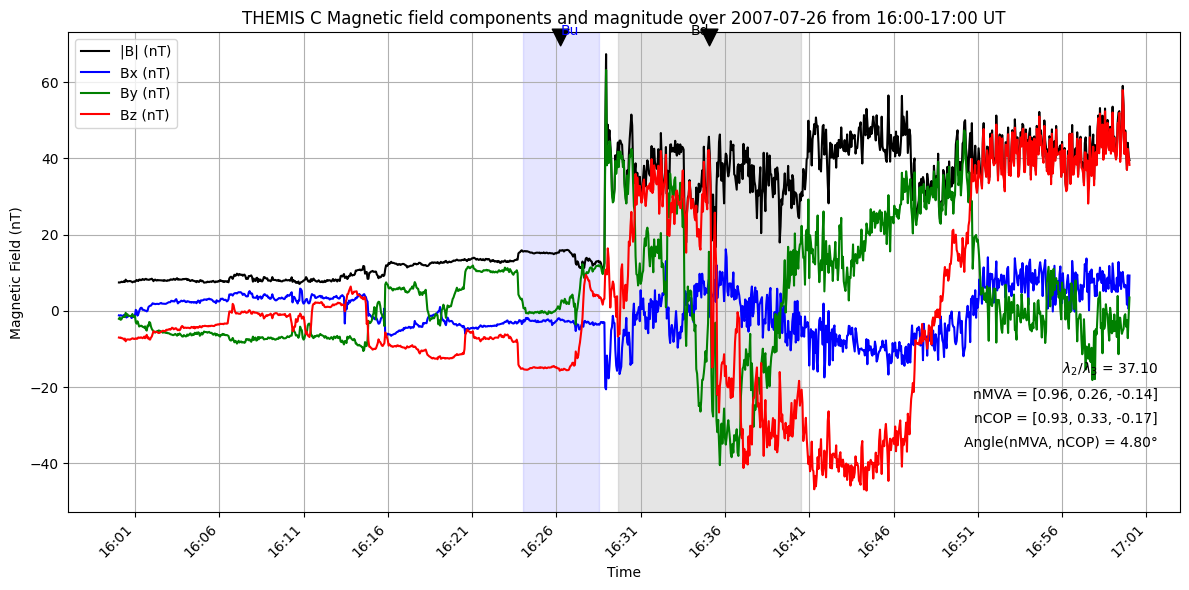

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

# df_fgm_thc is expected to be loaded from a previous cell (e.g., 1d8978b7)
# If running this cell independently, ensure df_fgm_thc is loaded or re-load it here.
# For robustness, we will ensure it's loaded in this cell's scope.
try:
    df_fgm_thc = pd.read_csv('/content/drive/MyDrive/phyton code/THC_L2_FGM_3457446.csv')
except FileNotFoundError as e:
    print(f"Error loading file: {e}")
    print("Please ensure the CSV file is located directly in your Google Drive 'My Drive' folder, or update the path if it is in a subfolder.")
    raise

# Convert 'UT__yyyy-mm-ddThh:mm:ss.sssZ' to datetime objects for THC data (if not already done)
df_fgm_thc['Time'] = pd.to_datetime(df_fgm_thc['UT__yyyy-mm-ddThh:mm:ss.sssZ'])

# Define the magnetic field component columns for THC
mag_field_cols_thc = [
    'BX_FGS-D_(@_1_)_nT_GSE_(All_Qs)', # Assuming same column names for THC
    'BY_FGS-D_(@_2_)_nT_GSE_(All_Qs)',
    'BZ_FGS-D_(@_3_)_nT_GSE_(All_Qs)'
]

# Calculate magnetic field magnitude |B| for THC
df_fgm_thc['|B|'] = np.sqrt(
    df_fgm_thc[mag_field_cols_thc[0]]**2 +
    df_fgm_thc[mag_field_cols_thc[1]]**2 +
    df_fgm_thc[mag_field_cols_thc[2]]**2
)


# Define the shock crossing time for THC
# Use the configurable variables from cell 70a45227
# shock_time_thc, thc_upstream_start, thc_upstream_end, thc_downstream_start, thc_downstream_end are from cell 70a45227

# --- THC Shock and Interval Definitions (copied from cell 70a45227) ---
shock_time_thc = pd.to_datetime('2007-07-26T16:29:35.000Z')

# Configure THC upstream duration (relative to shock_time_thc)
thc_upstream_start_absolute = pd.to_datetime('2007-07-26T16:24:00Z') # Absolute start time for THC upstream
thc_upstream_end_absolute = pd.to_datetime('2007-07-26T16:28:30Z')   # Absolute end time for THC upstream

# Configure THC downstream duration (relative to shock_time_thc)
thc_downstream_post_shock_start_duration_seconds = 5 # Start of downstream is 5s after shock
thc_downstream_interval_end_absolute = pd.to_datetime('2007-07-26T16:40:30Z') # Absolute end time for THC downstream

# Calculate THC intervals
thc_upstream_start = thc_upstream_start_absolute
thc_upstream_end = thc_upstream_end_absolute

thc_downstream_start = shock_time_thc + pd.Timedelta(seconds=thc_downstream_post_shock_start_duration_seconds)
thc_downstream_end = thc_downstream_interval_end_absolute

# --- Create single subplot for THC ---
fig_thc, ax_thc = plt.subplots(1, 1, figsize=(12, 6))

# --- Plot 1: Magnetic Field Components and Magnitude for THC ---
ax_thc.plot(df_fgm_thc['Time'], df_fgm_thc['|B|'], label='|B| (nT)', color='black')
ax_thc.plot(df_fgm_thc['Time'], df_fgm_thc[mag_field_cols_thc[0]], label='Bx (nT)', color='blue')
ax_thc.plot(df_fgm_thc['Time'], df_fgm_thc[mag_field_cols_thc[1]], label='By (nT)', color='green')
ax_thc.plot(df_fgm_thc['Time'], df_fgm_thc[mag_field_cols_thc[2]], label='Bz (nT)', color='red')

# Add shading for upstream and downstream intervals for THC
ax_thc.axvspan(thc_upstream_start, thc_upstream_end, color='blue', alpha=0.1, label='')
ax_thc.axvspan(thc_downstream_start, thc_downstream_end, color='black', alpha=0.1, label='')


# Add arrows for upstream and downstream intervals for THC
ax_thc.annotate('Bu', xy=(thc_upstream_start + (thc_upstream_end - thc_upstream_start) / 2, ax_thc.get_ylim()[1] * 0.95),
             xytext=(thc_upstream_start + (thc_upstream_end - thc_upstream_start) / 2, ax_thc.get_ylim()[1] * 0.98),
             arrowprops=dict(facecolor='black', shrink=0.05),
             ha='left', va='bottom', fontsize=10, color='blue')

ax_thc.annotate('Bd', xy=(thc_downstream_start + (thc_downstream_end - thc_downstream_start) / 2, ax_thc.get_ylim()[1] * 0.95),
             xytext=(thc_downstream_start + (thc_downstream_end - thc_downstream_start) / 2, ax_thc.get_ylim()[1] * 0.98),
             arrowprops=dict(facecolor='black', shrink=0.05),
             ha='right', va='bottom', fontsize=10, color='black')

ax_thc.set_title('THEMIS C Magnetic field components and magnitude over 2007-07-26 from 16:00-17:00 UT')
ax_thc.set_xlabel('Time')
ax_thc.set_ylabel('Magnetic Field (nT)')
ax_thc.grid(True)

# Set x-axis major ticks to 5-minute intervals for THC
ax_thc.xaxis.set_major_locator(mdates.MinuteLocator(interval=5))
ax_thc.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.xticks(rotation=45, ha='right')

# Perform MVA on the THC FGM data (Moved here to ensure MVA_thc is defined)
evals_thc, evecs_thc = mva(df_fgm_thc, *mag_field_cols_thc)
# Identify the minimum variance direction (shock normal) for THC
MVA_thc = evecs_thc[:, 2]

# Calculate average B for upstream and downstream regions for THC
df_upstream_thc = df_fgm_thc[(df_fgm_thc['Time'] >= thc_upstream_start) & (df_fgm_thc['Time'] <= thc_upstream_end)]
df_downstream_thc = df_fgm_thc[(df_fgm_thc['Time'] >= thc_downstream_start) & (df_fgm_thc['Time'] <= thc_downstream_end)]

B_upstream_avg_thc = df_upstream_thc[mag_field_cols_thc].mean().values
B_downstream_avg_thc = df_downstream_thc[mag_field_cols_thc].mean().values

# Calculate nCOP (Coplanarity Normal) for THC
if len(B_upstream_avg_thc) > 0 and len(B_downstream_avg_thc) > 0:
    nCOP_unnormalized_thc = np.cross(B_upstream_avg_thc, B_downstream_avg_thc)
    if np.linalg.norm(nCOP_unnormalized_thc) != 0:
        nCOP_thc = nCOP_unnormalized_thc / np.linalg.norm(nCOP_unnormalized_thc)
    else:
        nCOP_thc = np.array([np.nan, np.nan, np.nan])
else:
    nCOP_thc = np.array([np.nan, np.nan, np.nan])

# Calculate the angle between MVA and nCOP for THC
dot_product_thc = np.dot(MVA_thc, nCOP_thc)
dot_product_thc = np.clip(dot_product_thc, -1.0, 1.0)
angle_rad_thc = np.arccos(dot_product_thc)
angle_deg_thc = np.degrees(angle_rad_thc)

# Calculate additional ratios for THC
reliability_ratio_thc = evals_thc[1] / evals_thc[2] # Changed to lambda_2 / lambda_3 as in THB FGM MVA analysis

# --- Add original legend for B components for THC ----
ax_thc.legend(loc='upper left')

# --- Add MVA, nCOP, and angle as text directly on the plot for THC ---
ax_thc.text(0.98, 0.28, fr'$ \lambda_2 / \lambda_3 $ = {reliability_ratio_thc:.2f}',
         transform=ax_thc.transAxes, fontsize=10, verticalalignment='bottom', horizontalalignment='right')
ax_thc.text(0.98, 0.23, f'nMVA = [{MVA_thc[0]:.2f}, {MVA_thc[1]:.2f}, {MVA_thc[2]:.2f}]',
         transform=ax_thc.transAxes, fontsize=10, verticalalignment='bottom', horizontalalignment='right')
ax_thc.text(0.98, 0.18, f'nCOP = [{nCOP_thc[0]:.2f}, {nCOP_thc[1]:.2f}, {nCOP_thc[2]:.2f}]',
         transform=ax_thc.transAxes, fontsize=10, verticalalignment='bottom', horizontalalignment='right')
ax_thc.text(0.98, 0.13, f'Angle(nMVA, nCOP) = {angle_deg_thc:.2f}°',
         transform=ax_thc.transAxes, fontsize=10, verticalalignment='bottom', horizontalalignment='right')

plt.tight_layout()
plt.savefig('/content/THC_correct_value_intervals.png') # Save the figure for THC
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import os

try:
    # Load THD data
    df_fgm_thd = pd.read_csv('/content/drive/MyDrive/phyton code/THD_L2_FGM_3457446.csv')
except FileNotFoundError as e:
    print(f"Error loading file: {e}")
    print("Please ensure the CSV files are located directly in your Google Drive 'My Drive' folder, or update the paths if they are in a subfolder.")
    print("You can list the contents of your Google Drive to verify the paths:")
    print("Contents of /content/drive/MyDrive/:")
    try:
        print(os.listdir('/content/drive/MyDrive/'))
    except Exception as list_e:
        print(f"Could not list directory: {list_e}")
    raise

# Convert 'UT__yyyy-mm-ddThh:mm:ss.sssZ' to datetime objects for THD data
df_fgm_thd['Time'] = pd.to_datetime(df_fgm_thd['UT__yyyy-mm-ddThh:mm:ss.sssZ'])

# Define the magnetic field component columns for THD
mag_field_cols_thd = [
    'BX_FGS-D_(@_1_)_nT_GSE_(All_Qs)', # Assuming same column names for THD
    'BY_FGS-D_(@_2_)_nT_GSE_(All_Qs)',
    'BZ_FGS-D_(@_3_)_nT_GSE_(All_Qs)'
]

# Calculate magnetic field magnitude |B| for THD
df_fgm_thd['|B|'] = np.sqrt(
    df_fgm_thd[mag_field_cols_thd[0]]**2 +
    df_fgm_thd[mag_field_cols_thd[1]]**2 +
    df_fgm_thd[mag_field_cols_thd[2]]**2
)

# Display the head of the THD dataframe
display(df_fgm_thd.head())

,UT__yyyy-mm-ddThh:mm:ss.sssZ,FGS-D_B_TOTAL__nT_(All_Qs),BX_FGS-D_(@_1_)_nT_GSE_(All_Qs),BY_FGS-D_(@_2_)_nT_GSE_(All_Qs),BZ_FGS-D_(@_3_)_nT_GSE_(All_Qs),Time,|B|
0,2007-07-26T16:00:00.864Z,7.48215,-1.32088,-2.10989,-7.05593,2007-07-26 16:00:00.864000+00:00,7.482146
1,2007-07-26T16:00:03.869Z,7.39998,-1.35944,-1.98410,-6.99821,2007-07-26 16:00:03.869000+00:00,7.399978
2,2007-07-26T16:00:06.874Z,7.46897,-1.39903,-2.23868,-6.98688,2007-07-26 16:00:06.874000+00:00,7.468967
3,2007-07-26T16:00:09.880Z,7.40152,-1.34242,-2.39428,-6.87370,2007-07-26 16:00:09.880000+00:00,7.401515
4,2007-07-26T16:00:12.885Z,7.41086,-1.55482,-2.10050,-6.93479,2007-07-26 16:00:12.885000+00:00,7.410862


In [ ]:
# The `mva` function is already defined globally.

# Perform MVA on the THD FGM data
evals_thd, evecs_thd = mva(df_fgm_thd, *mag_field_cols_thd)

print("THD Eigenvalues (lambda_1 >= lambda_2 >= lambda_3):")
for i, val in enumerate(evals_thd):
    print(f"  lambda_{i+1} = {val:.4f}")

print("\nTHD Eigenvectors (corresponding to lambda_1, lambda_2, lambda_3):")
for i, vec in enumerate(evecs_thd.T):
    print(f"  Eigenvector {i+1} (direction of lambda_{i+1}) = {vec}")

# Identify the minimum variance direction (shock normal) for THD
MVA_thd = evecs_thd[:, 2]
print(f"\nTHD Minimum variance direction (shock normal vector, n) = {MVA_thd}")

# Calculate the reliability ratio for THD
reliability_ratio_thd = evals_thd[1] / evals_thd[2]
print(f"THD Reliability ratio (lambda_2 / lambda_3) = {reliability_ratio_thd:.4f}")

# Assess reliability for THD
if reliability_ratio_thd > 3:
    print("THD MVA result is highly reliable (ratio > 3).")
elif reliability_ratio_thd > 2:
    print("THD MVA result is reliable (ratio > 2).")
else:
    print("THD MVA result may not be reliable (ratio <= 2).")

THD Eigenvalues (lambda_1 >= lambda_2 >= lambda_3):
  lambda_1 = 573.0449
  lambda_2 = 231.5379
  lambda_3 = 6.2987

THD Eigenvectors (corresponding to lambda_1, lambda_2, lambda_3):
  Eigenvector 1 (direction of lambda_1) = [ 0.14831979 -0.0425209   0.98802491]
  Eigenvector 2 (direction of lambda_2) = [-0.235547    0.96880358  0.0770534 ]
  Eigenvector 3 (direction of lambda_3) = [ 0.96047845  0.24415484 -0.13367707]

THD Minimum variance direction (shock normal vector, n) = [ 0.96047845  0.24415484 -0.13367707]
THD Reliability ratio (lambda_2 / lambda_3) = 36.7599
THD MVA result is highly reliable (ratio > 3).


In [ ]:
# Define the shock crossing time for THD
shock_time_thd = pd.to_datetime('2007-07-26T16:29:35.000Z') # Placeholder, please change for THD

# Define upstream and downstream intervals for THD
upstream_end_thd = pd.to_datetime('2007-07-26T16:29:00Z')
upstream_start_thd = pd.to_datetime('2007-07-26T16:24:00Z')

downstream_start_thd = shock_time_thd + pd.Timedelta(seconds=5)
downstream_end_thd = pd.to_datetime('2007-07-26T16:40:30Z')

In [ ]:
import pandas as pd
import numpy as np
import os

try:
    # Load THE data
    df_fgm_the = pd.read_csv('/content/drive/MyDrive/phyton code/THE_L2_FGM_3457446.csv')
except FileNotFoundError as e:
    print(f"Error loading file: {e}")
    print("Please ensure the CSV files are located directly in your Google Drive 'My Drive' folder, or update the paths if they are in a subfolder.")
    print("You can list the contents of your Google Drive to verify the paths:")
    print("Contents of /content/drive/MyDrive/:")
    try:
        print(os.listdir('/content/drive/MyDrive/'))
    except Exception as list_e:
        print(f"Could not list directory: {list_e}")
    raise

# Convert 'UT__yyyy-mm-ddThh:mm:ss.sssZ' to datetime objects for THE data
df_fgm_the['Time'] = pd.to_datetime(df_fgm_the['UT__yyyy-mm-ddThh:mm:ss.sssZ'])

# Define the magnetic field component columns for THE
mag_field_cols_the = [
    'BX_FGS-D_(@_1_)_nT_GSE_(All_Qs)', # Assuming same column names for THE
    'BY_FGS-D_(@_2_)_nT_GSE_(All_Qs)',
    'BZ_FGS-D_(@_3_)_nT_GSE_(All_Qs)'
]

# Calculate magnetic field magnitude |B| for THE
df_fgm_the['|B|'] = np.sqrt(
    df_fgm_the[mag_field_cols_the[0]]**2 +
    df_fgm_the[mag_field_cols_the[1]]**2 +
    df_fgm_the[mag_field_cols_the[2]]**2
)

# Display the head of the THE dataframe
display(df_fgm_the.head())

,UT__yyyy-mm-ddThh:mm:ss.sssZ,FGS-D_B_TOTAL__nT_(All_Qs),BX_FGS-D_(@_1_)_nT_GSE_(All_Qs),BY_FGS-D_(@_2_)_nT_GSE_(All_Qs),BZ_FGS-D_(@_3_)_nT_GSE_(All_Qs),Time,|B|
0,2007-07-26T16:00:00.861Z,7.62052,-0.947378,-2.11968,-7.25822,2007-07-26 16:00:00.861000+00:00,7.620520
1,2007-07-26T16:00:03.864Z,7.60479,-1.069900,-2.10801,-7.22803,2007-07-26 16:00:03.864000+00:00,7.604789
2,2007-07-26T16:00:06.868Z,7.54535,-1.284960,-2.19104,-7.10497,2007-07-26 16:00:06.868000+00:00,7.545355
3,2007-07-26T16:00:09.871Z,7.56787,-1.388400,-1.78906,-7.22110,2007-07-26 16:00:09.871000+00:00,7.567871
4,2007-07-26T16:00:12.875Z,7.86724,-1.324370,-1.67881,-7.57107,2007-07-26 16:00:12.875000+00:00,7.867240


In [ ]:
# The `mva` function is already defined globally.

# Perform MVA on the THE FGM data
evals_the, evecs_the = mva(df_fgm_the, *mag_field_cols_the)

print("THE Eigenvalues (lambda_1 >= lambda_2 >= lambda_3):")
for i, val in enumerate(evals_the):
    print(f"  lambda_{i+1} = {val:.4f}")

print("\nTHE Eigenvectors (corresponding to lambda_1, lambda_2, lambda_3):")
for i, vec in enumerate(evecs_the.T):
    print(f"  Eigenvector {i+1} (direction of lambda_{i+1}) = {vec}")

# Identify the minimum variance direction (shock normal) for THE
MVA_the = evecs_the[:, 2]
print(f"\nTHE Minimum variance direction (shock normal vector, n) = {MVA_the}")

# Calculate the reliability ratio for THE
reliability_ratio_the = evals_the[1] / evals_the[2]
print(f"THE Reliability ratio (lambda_2 / lambda_3) = {reliability_ratio_the:.4f}")

# Assess reliability for THE
if reliability_ratio_the > 3:
    print("THE MVA result is highly reliable (ratio > 3).")
elif reliability_ratio_the > 2:
    print("THE MVA result is reliable (ratio > 2).")
else:
    print("THE MVA result may not be reliable (ratio <= 2).")

THE Eigenvalues (lambda_1 >= lambda_2 >= lambda_3):
  lambda_1 = 467.2150
  lambda_2 = 183.4134
  lambda_3 = 5.5977

THE Eigenvectors (corresponding to lambda_1, lambda_2, lambda_3):
  Eigenvector 1 (direction of lambda_1) = [ 0.15216887 -0.06335874  0.9863216 ]
  Eigenvector 2 (direction of lambda_2) = [-0.23287456  0.96754827  0.09808049]
  Eigenvector 3 (direction of lambda_3) = [ 0.96052802  0.244614   -0.13247609]

THE Minimum variance direction (shock normal vector, n) = [ 0.96052802  0.244614   -0.13247609]
THE Reliability ratio (lambda_2 / lambda_3) = 32.7656
THE MVA result is highly reliable (ratio > 3).


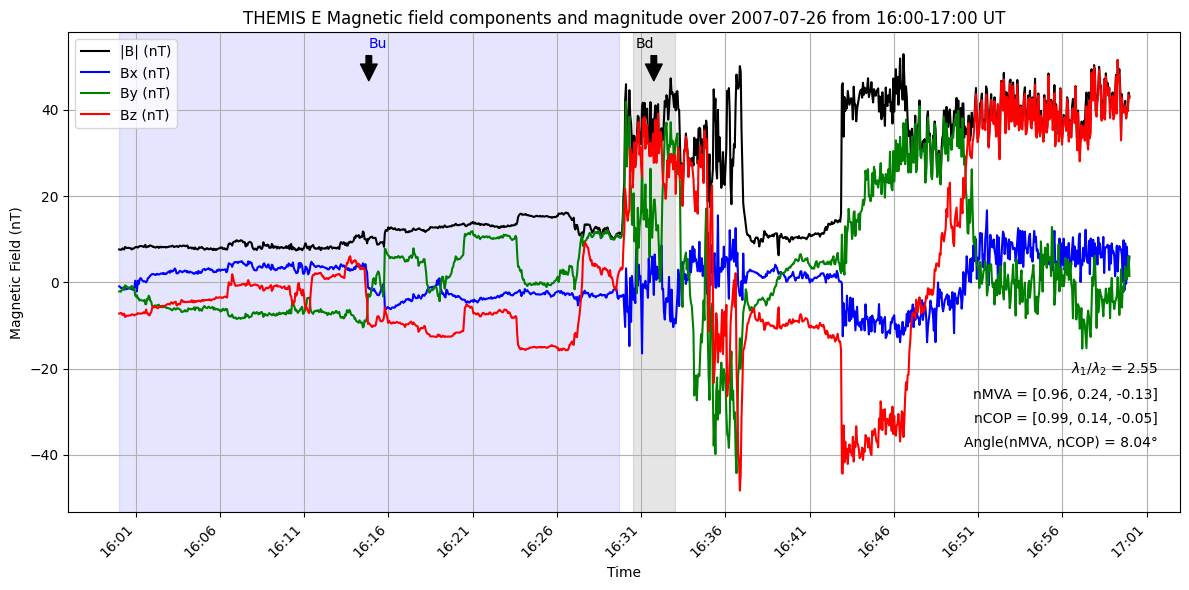

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Define the shock crossing time for THE
shock_time_the = pd.to_datetime('2007-07-26T16:29:45.000Z') # Placeholder, please change for THE

# Define upstream and downstream intervals for THE (using variables from dea1f2c2)
upstream_start_the = pd.to_datetime('2007-07-26T16:00:00Z')
upstream_end_the = pd.to_datetime('2007-07-26T16:29:40Z')
downstream_start_the = pd.to_datetime('2007-07-26T16:30:30Z')
downstream_end_the = pd.to_datetime('2007-07-26T16:33:00Z')

# --- Create single subplot for THE ---
fig_the, ax_the = plt.subplots(1, 1, figsize=(12, 6))

# --- Plot 1: Magnetic Field Components and Magnitude for THE ---
ax_the.plot(df_fgm_the['Time'], df_fgm_the['|B|'], label='|B| (nT)', color='black')
ax_the.plot(df_fgm_the['Time'], df_fgm_the[mag_field_cols_the[0]], label='Bx (nT)', color='blue')
ax_the.plot(df_fgm_the['Time'], df_fgm_the[mag_field_cols_the[1]], label='By (nT)', color='green')
ax_the.plot(df_fgm_the['Time'], df_fgm_the[mag_field_cols_the[2]], label='Bz (nT)', color='red')

# Add vertical dashed lines without labels in legend for THE
# ax_the.axvline(shock_time_the, color='blue', linestyle='--')
# ax_the.axvline(upstream_start_the, color='blue', linestyle=':')
# ax_the.axvline(upstream_end_the, color='blue', linestyle=':')
# ax_the.axvline(downstream_start_the, color='black', linestyle=':')
# ax_the.axvline(downstream_end_the, color='black', linestyle=':')

# Add shading for upstream and downstream intervals for THE
ax_the.axvspan(upstream_start_the, upstream_end_the, color='blue', alpha=0.1, label='')
ax_the.axvspan(downstream_start_the, downstream_end_the, color='black', alpha=0.1, label='')

# Add specific shading (adjust if needed for THE)
# shade_start_1_the = pd.to_datetime('2007-07-26T16:41:30Z') # Placeholder
# shade_end_1_the = pd.to_datetime('2007-07-26T16:45:30Z')   # Placeholder
# ax_the.axvspan(shade_start_1_the, shade_end_1_the, color='purple', alpha=0.15, label='')

# shade_start_2_the = pd.to_datetime('2007-07-26T16:23:30Z') # Placeholder
# shade_end_2_the = pd.to_datetime('2007-07-26T16:27:00Z')   # Placeholder
# ax_the.axvspan(shade_start_2_the, shade_end_2_the, color='orange', alpha=0.15, label='')

# Add arrows for upstream and downstream intervals for THE
ax_the.annotate('Bu', xy=(upstream_start_the + (upstream_end_the - upstream_start_the) / 2, ax_the.get_ylim()[1] * 0.80),
             xytext=(upstream_start_the + (upstream_end_the - upstream_start_the) / 2, ax_the.get_ylim()[1] * 0.98),
             arrowprops=dict(facecolor='black', shrink=0.05),
             ha='left', va='top', fontsize=10, color='blue')

ax_the.annotate('Bd', xy=(downstream_start_the + (downstream_end_the - downstream_start_the) / 2, ax_the.get_ylim()[1] * 0.80),
             xytext=(downstream_start_the + (downstream_end_the - downstream_start_the) / 2, ax_the.get_ylim()[1] * 0.98),
             arrowprops=dict(facecolor='black', shrink=0.05),
             ha='right', va='top', fontsize=10, color='black')

ax_the.set_title('THEMIS E Magnetic field components and magnitude over 2007-07-26 from 16:00-17:00 UT')
ax_the.set_xlabel('Time')
ax_the.set_ylabel('Magnetic Field (nT)')
ax_the.grid(True)

# Set x-axis major ticks to 5-minute intervals for THE
ax_the.xaxis.set_major_locator(mdates.MinuteLocator(interval=5))
ax_the.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.xticks(rotation=45, ha='right')

# Calculate average B for upstream and downstream regions for THE
df_upstream_the = df_fgm_the[(df_fgm_the['Time'] >= upstream_start_the) & (df_fgm_the['Time'] <= upstream_end_the)]
df_downstream_the = df_fgm_the[(df_fgm_the['Time'] >= downstream_start_the) & (df_fgm_the['Time'] <= downstream_end_the)]

B_upstream_avg_the = df_upstream_the[mag_field_cols_the].mean().values
B_downstream_avg_the = df_downstream_the[mag_field_cols_the].mean().values

# Calculate nCOP (Coplanarity Normal) for THE
if len(B_upstream_avg_the) > 0 and len(B_downstream_avg_the) > 0:
    nCOP_unnormalized_the = np.cross(B_upstream_avg_the, B_downstream_avg_the)
    if np.linalg.norm(nCOP_unnormalized_the) != 0:
        nCOP_the = nCOP_unnormalized_the / np.linalg.norm(nCOP_unnormalized_the)
    else:
        nCOP_the = np.array([np.nan, np.nan, np.nan])
else:
    nCOP_the = np.array([np.nan, np.nan, np.nan])

# Calculate the angle between MVA and nCOP for THE
dot_product_the = np.dot(MVA_the, nCOP_the)
dot_product_the = np.clip(dot_product_the, -1.0, 1.0)
angle_rad_the = np.arccos(dot_product_the)
angle_deg_the = np.degrees(angle_rad_the)

# Calculate additional ratios for THE
ratio_lambda1_lambda2_the = evals_the[0] / evals_the[1]

# --- Add original legend for B components for THE ---
ax_the.legend(loc='upper left')

# --- Add MVA, nCOP, and angle as text directly on the plot for THE ---
ax_the.text(0.98, 0.28, fr'$ \lambda_1 / \lambda_2 $ = {ratio_lambda1_lambda2_the:.2f}',
         transform=ax_the.transAxes, fontsize=10, verticalalignment='bottom', horizontalalignment='right')
ax_the.text(0.98, 0.23, f'nMVA = [{MVA_the[0]:.2f}, {MVA_the[1]:.2f}, {MVA_the[2]:.2f}]',
         transform=ax_the.transAxes, fontsize=10, verticalalignment='bottom', horizontalalignment='right')
ax_the.text(0.98, 0.18, f'nCOP = [{nCOP_the[0]:.2f}, {nCOP_the[1]:.2f}, {nCOP_the[2]:.2f}]',
         transform=ax_the.transAxes, fontsize=10, verticalalignment='bottom', horizontalalignment='right')
ax_the.text(0.98, 0.13, f'Angle(nMVA, nCOP) = {angle_deg_the:.2f}°',
         transform=ax_the.transAxes, fontsize=10, verticalalignment='bottom', horizontalalignment='right')

plt.tight_layout()
plt.savefig('/content/THE_correct_value_intervals.png') # Save the figure for THE
plt.show()

In [ ]:
import pandas as pd

# Define the shock crossing time for THE
shock_time_the = pd.to_datetime('2007-07-26T16:29:35.000Z')

# Define upstream and downstream intervals for THE
upstream_start_the_new = pd.to_datetime('2007-07-26T16:23:00Z') # Example start
upstream_end_the_new = pd.to_datetime('2007-07-26T16:27:00Z')   # Example end

downstream_start_the_new = pd.to_datetime('2007-07-26T16:30:00Z') # Example start
downstream_end_the_new = pd.to_datetime('2007-07-26T16:40:00Z')   # Example end

print(f"Current THE shock time: {shock_time_the}")
print(f"Current THE upstream interval: {upstream_start_the_new} to {upstream_end_the_new}")
print(f"Current THE downstream interval: {downstream_start_the_new} to {downstream_end_the_new}")

Current THE shock time: 2007-07-26 16:29:35+00:00
Current THE upstream interval: 2007-07-26 16:23:00+00:00 to 2007-07-26 16:27:00+00:00
Current THE downstream interval: 2007-07-26 16:30:00+00:00 to 2007-07-26 16:40:00+00:00


### Multi-Spacecraft Plot: THB and THC Magnetic Field and MVA/nCOP Analysis

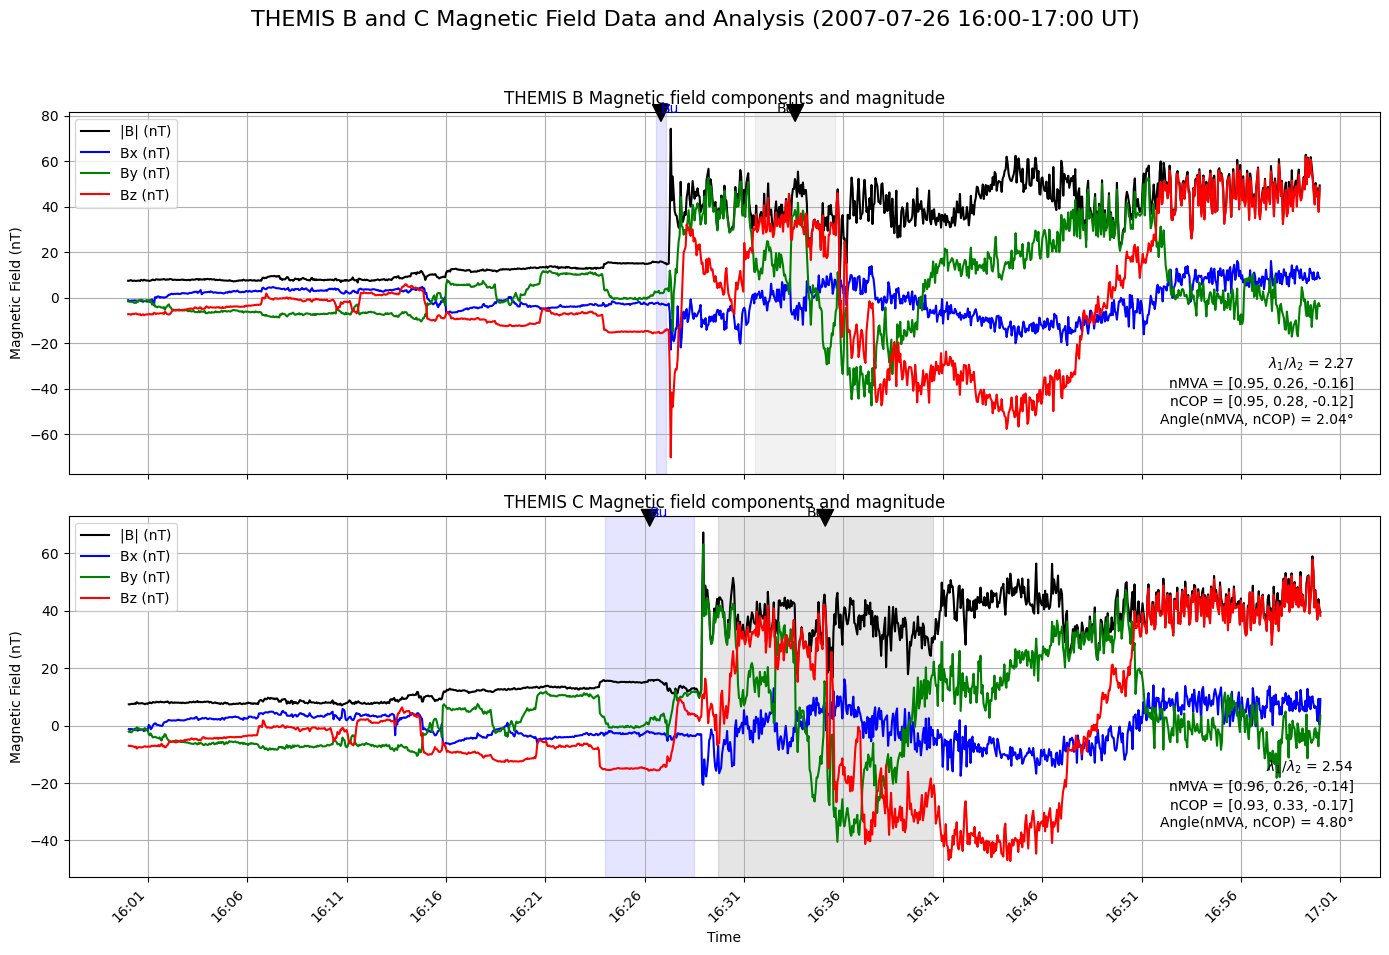

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np
import os

# Define the MVA function (moved from ab252dbe to ensure it's available)
def mva(data, bx_col, by_col, bz_col):
    """
    Performs Minimum Variance Analysis (MVA) on magnetic field data.

    Args:
        data (pd.DataFrame): DataFrame containing magnetic field data.
        bx_col (str): Column name for the Bx component.
        by_col (str): Column name for the By component.
        bz_col (str): Column name for the Bz component.

    Returns:
        tuple: A tuple containing:
            - eigenvalues (np.ndarray): Sorted eigenvalues (lambda_1 >= lambda_2 >= lambda_3).
            - eigenvectors (np.ndarray): Corresponding sorted eigenvectors (columns).
    """
    # Extract magnetic field components
    B = data[[bx_col, by_col, bz_col]].values

    # Calculate the mean magnetic field vector
    mean_B = np.mean(B, axis=0)

    # Center the data by subtracting the mean
    B_centered = B - mean_B

    # Calculate the covariance matrix (M)
    # np.cov expects variables as rows, so we transpose B_centered
    M = np.cov(B_centered.T)

    # Solve the eigenvalue problem M n = lambda n
    eigenvalues, eigenvectors = np.linalg.eigh(M)

    # Sort eigenvalues in descending order and corresponding eigenvectors
    # lambda_1 >= lambda_2 >= lambda_3
    idx = eigenvalues.argsort()[::-1] # Get indices that sort in descending order
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    return eigenvalues, eigenvectors


# Explicitly load df_fgm and df_fgm_thc to ensure they are defined
try:
    df_fgm = pd.read_csv('/content/drive/MyDrive/phyton code/THB_L2_FGM_3457446.csv')
    df_fgm_thc = pd.read_csv('/content/drive/MyDrive/phyton code/THC_L2_FGM_3457446.csv')
except FileNotFoundError as e:
    print(f"Error loading file: {e}")
    print("Please ensure the CSV files are located directly in your Google Drive 'My Drive' folder, or update the paths if they are in a subfolder.")
    print("You can list the contents of your Google Drive to verify the paths:")
    print("Contents of /content/drive/MyDrive/:")
    try:
        print(os.listdir('/content/drive/MyDrive/'))
    except Exception as list_e:
        print(f"Could not list directory: {list_e}")
    raise

# Convert 'UT__yyyy-mm-ddThh:mm:ss.sssZ' to datetime objects for both dataframes
df_fgm['Time'] = pd.to_datetime(df_fgm['UT__yyyy-mm-ddThh:mm:ss.sssZ'])
df_fgm_thc['Time'] = pd.to_datetime(df_fgm_thc['UT__yyyy-mm-ddThh:mm:ss.sssZ'])

# Re-define magnetic field column names for clarity (already defined in previous cells)
mag_field_cols_thb = [
    'BX_FGS-D_(@_1_)_nT_GSE_(All_Qs)',
    'BY_FGS-D_(@_2_)_nT_GSE_(All_Qs)',
    'BZ_FGS-D_(@_3_)_nT_GSE_(All_Qs)'
]
mag_field_cols_thc = [
    'BX_FGS-D_(@_1_)_nT_GSE_(All_Qs)',
    'BY_FGS-D_(@_2_)_nT_GSE_(All_Qs)',
    'BZ_FGS-D_(@_3_)_nT_GSE_(All_Qs)'
]

# --- THB Data and Intervals (from cell 9d3d7f1e) ---
# Ensure df_fgm has '|B|' column calculated
if '|B|' not in df_fgm.columns:
    df_fgm['|B|'] = np.sqrt(
        df_fgm[mag_field_cols_thb[0]]**2 +
        df_fgm[mag_field_cols_thb[1]]**2 +
        df_fgm[mag_field_cols_thb[2]]**2
    )

shock_time_thb = pd.to_datetime('2007-07-26T16:27:34.050Z')
upstream_end_thb = shock_time_thb - pd.Timedelta(seconds=30)
upstream_start_thb = upstream_end_thb - pd.Timedelta(seconds=30)
downstream_start_thb = shock_time_thb + pd.Timedelta(minutes=4)
downstream_end_thb = downstream_start_thb + pd.Timedelta(minutes=4)

# Perform MVA for THB (assuming mva function is globally defined)
# If it was not, we would need to call it here again to get evals_thb, evecs_thb
evals_thb, evecs_thb = mva(df_fgm, *mag_field_cols_thb) # Re-calculate for robustness
MVA_thb = evecs_thb[:, 2]

df_upstream_thb_calc = df_fgm[(df_fgm['Time'] >= upstream_start_thb) & (df_fgm['Time'] <= upstream_end_thb)]
df_downstream_thb_calc = df_fgm[(df_fgm['Time'] >= downstream_start_thb) & (df_fgm['Time'] <= downstream_end_thb)]

B_upstream_avg_thb_calc = df_upstream_thb_calc[mag_field_cols_thb].mean().values
B_downstream_avg_thb_calc = df_downstream_thb_calc[mag_field_cols_thb].mean().values

nCOP_thb = np.array([np.nan, np.nan, np.nan])
if len(B_upstream_avg_thb_calc) > 0 and len(B_downstream_avg_thb_calc) > 0:
    nCOP_unnormalized_thb = np.cross(B_upstream_avg_thb_calc, B_downstream_avg_thb_calc)
    if np.linalg.norm(nCOP_unnormalized_thb) != 0:
        nCOP_thb = nCOP_unnormalized_thb / np.linalg.norm(nCOP_unnormalized_thb)

dot_product_thb = np.dot(MVA_thb, nCOP_thb)
dot_product_thb = np.clip(dot_product_thb, -1.0, 1.0)
angle_deg_thb = np.degrees(np.arccos(dot_product_thb))
reliability_ratio_thb = evals_thb[0] / evals_thb[1] # Changed to lambda_1 / lambda_2

# --- THC Data and Intervals (from cell 3e962812) ---
# Ensure df_fgm_thc has '|B|' column calculated
if '|B|' not in df_fgm_thc.columns:
    df_fgm_thc['|B|'] = np.sqrt(
        df_fgm_thc[mag_field_cols_thc[0]]**2 +
        df_fgm_thc[mag_field_cols_thc[1]]**2 +
        df_fgm_thc[mag_field_cols_thc[2]]**2
    )

shock_time_thc = pd.to_datetime('2007-07-26T16:29:35.000Z')
upstream_end_thc = pd.to_datetime('2007-07-26T16:28:30Z')
upstream_start_thc = pd.to_datetime('2007-07-26T16:24:00Z')
downstream_start_thc = shock_time_thc + pd.Timedelta(seconds=5)
downstream_end_thc = pd.to_datetime('2007-07-26T16:40:30Z')

# Perform MVA for THC (assuming mva function is globally defined)
# If it was not, we would need to call it here again to get evals_thc, evecs_thc
evals_thc, evecs_thc = mva(df_fgm_thc, *mag_field_cols_thc) # Re-calculate for robustness
MVA_thc = evecs_thc[:, 2]

df_upstream_thc_calc = df_fgm_thc[(df_fgm_thc['Time'] >= upstream_start_thc) & (df_fgm_thc['Time'] <= upstream_end_thc)]
df_downstream_thc_calc = df_fgm_thc[(df_fgm_thc['Time'] >= downstream_start_thc) & (df_fgm_thc['Time'] <= downstream_end_thc)]

B_upstream_avg_thc_calc = df_upstream_thc_calc[mag_field_cols_thc].mean().values
B_downstream_avg_thc_calc = df_downstream_thc_calc[mag_field_cols_thc].mean().values

nCOP_thc = np.array([np.nan, np.nan, np.nan])
if len(B_upstream_avg_thc_calc) > 0 and len(B_downstream_avg_thc_calc) > 0:
    nCOP_unnormalized_thc = np.cross(B_upstream_avg_thc_calc, B_downstream_avg_thc_calc)
    if np.linalg.norm(nCOP_unnormalized_thc) != 0:
        nCOP_thc = nCOP_unnormalized_thc / np.linalg.norm(nCOP_unnormalized_thc)

dot_product_thc = np.dot(MVA_thc, nCOP_thc)
dot_product_thc = np.clip(dot_product_thc, -1.0, 1.0)
angle_deg_thc = np.degrees(np.arccos(dot_product_thc))
ratio_lambda1_lambda2_thc = evals_thc[0] / evals_thc[1] # Reverted to lambda_1 / lambda_2


# --- Create Multi-Spacecraft Subplots ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True) # Share x-axis for better comparison

# --- Plot for THB (ax1) ---
ax1.plot(df_fgm['Time'], df_fgm['|B|'], label='|B| (nT)', color='black')
ax1.plot(df_fgm['Time'], df_fgm[mag_field_cols_thb[0]], label='Bx (nT)', color='blue')
ax1.plot(df_fgm['Time'], df_fgm[mag_field_cols_thb[1]], label='By (nT)', color='green')
ax1.plot(df_fgm['Time'], df_fgm[mag_field_cols_thb[2]], label='Bz (nT)', color='red')

# Add shading for THB upstream and downstream intervals
ax1.axvspan(upstream_start_thb, upstream_end_thb, color='blue', alpha=0.1, label='')
ax1.axvspan(downstream_start_thb, downstream_end_thb, color='grey', alpha=0.1, label='')

# Add arrows for THB upstream and downstream intervals
ax1.annotate('Bu', xy=(upstream_start_thb + (upstream_end_thb - upstream_start_thb) / 2, ax1.get_ylim()[1] * 0.95),
             xytext=(upstream_start_thb + (upstream_end_thb - upstream_start_thb) / 2, ax1.get_ylim()[1] * 0.98),
             arrowprops=dict(facecolor='black', shrink=0.05),
             ha='left', va='bottom', fontsize=10, color='blue')
ax1.annotate('Bd', xy=(downstream_start_thb + (downstream_end_thb - downstream_start_thb) / 2, ax1.get_ylim()[1] * 0.95),
             xytext=(downstream_start_thb + (downstream_end_thb - downstream_start_thb) / 2, ax1.get_ylim()[1] * 0.98),
             arrowprops=dict(facecolor='black', shrink=0.05),
             ha='right', va='bottom', fontsize=10, color='black')

ax1.set_title('THEMIS B Magnetic field components and magnitude')
ax1.set_ylabel('Magnetic Field (nT)')
ax1.grid(True)
ax1.legend(loc='upper left')
ax1.text(0.98, 0.28, fr'$ \lambda_1 / \lambda_2 $ = {reliability_ratio_thb:.2f}', transform=ax1.transAxes, fontsize=10, verticalalignment='bottom', horizontalalignment='right')
ax1.text(0.98, 0.23, f'nMVA = [{MVA_thb[0]:.2f}, {MVA_thb[1]:.2f}, {MVA_thb[2]:.2f}]', transform=ax1.transAxes, fontsize=10, verticalalignment='bottom', horizontalalignment='right')
ax1.text(0.98, 0.18, f'nCOP = [{nCOP_thb[0]:.2f}, {nCOP_thb[1]:.2f}, {nCOP_thb[2]:.2f}]', transform=ax1.transAxes, fontsize=10, verticalalignment='bottom', horizontalalignment='right')
ax1.text(0.98, 0.13, f'Angle(nMVA, nCOP) = {angle_deg_thb:.2f}°', transform=ax1.transAxes, fontsize=10, verticalalignment='bottom', horizontalalignment='right')

# --- Plot for THC (ax2) ---
ax2.plot(df_fgm_thc['Time'], df_fgm_thc['|B|'], label='|B| (nT)', color='black')
ax2.plot(df_fgm_thc['Time'], df_fgm_thc[mag_field_cols_thc[0]], label='Bx (nT)', color='blue')
ax2.plot(df_fgm_thc['Time'], df_fgm_thc[mag_field_cols_thc[1]], label='By (nT)', color='green')
ax2.plot(df_fgm_thc['Time'], df_fgm_thc[mag_field_cols_thc[2]], label='Bz (nT)', color='red')

# Add shading for THC upstream and downstream intervals
ax2.axvspan(upstream_start_thc, upstream_end_thc, color='blue', alpha=0.1, label='')
ax2.axvspan(downstream_start_thc, downstream_end_thc, color='black', alpha=0.1, label='')

# Add arrows for THC upstream and downstream intervals
ax2.annotate('Bu', xy=(upstream_start_thc + (upstream_end_thc - upstream_start_thc) / 2, ax2.get_ylim()[1] * 0.95),
             xytext=(upstream_start_thc + (upstream_end_thc - upstream_start_thc) / 2, ax2.get_ylim()[1] * 0.98),
             arrowprops=dict(facecolor='black', shrink=0.05),
             ha='left', va='bottom', fontsize=10, color='blue')
ax2.annotate('Bd', xy=(downstream_start_thc + (downstream_end_thc - downstream_start_thc) / 2, ax2.get_ylim()[1] * 0.95),
             xytext=(downstream_start_thc + (downstream_end_thc - downstream_start_thc) / 2, ax2.get_ylim()[1] * 0.98),
             arrowprops=dict(facecolor='black', shrink=0.05),
             ha='right', va='bottom', fontsize=10, color='black')

ax2.set_title('THEMIS C Magnetic field components and magnitude')
ax2.set_xlabel('Time')
ax2.set_ylabel('Magnetic Field (nT)')
ax2.grid(True)
ax2.legend(loc='upper left')
ax2.text(0.98, 0.28, fr'$ \lambda_1 / \lambda_2 $ = {ratio_lambda1_lambda2_thc:.2f}', transform=ax2.transAxes, fontsize=10, verticalalignment='bottom', horizontalalignment='right')
ax2.text(0.98, 0.23, f'nMVA = [{MVA_thc[0]:.2f}, {MVA_thc[1]:.2f}, {MVA_thc[2]:.2f}]', transform=ax2.transAxes, fontsize=10, verticalalignment='bottom', horizontalalignment='right')
ax2.text(0.98, 0.18, f'nCOP = [{nCOP_thc[0]:.2f}, {nCOP_thc[1]:.2f}, {nCOP_thc[2]:.2f}]', transform=ax2.transAxes, fontsize=10, verticalalignment='bottom', horizontalalignment='right')
ax2.text(0.98, 0.13, f'Angle(nMVA, nCOP) = {angle_deg_thc:.2f}°', transform=ax2.transAxes, fontsize=10, verticalalignment='bottom', horizontalalignment='right')

# Set x-axis major ticks for both plots
ax2.xaxis.set_major_locator(mdates.MinuteLocator(interval=5))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.xticks(rotation=45, ha='right')

fig.suptitle('THEMIS B and C Magnetic Field Data and Analysis (2007-07-26 16:00-17:00 UT)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('/content/THB_THC_multi_spacecraft_plot.png')
plt.show()

### Loading and Plotting THB FGM and ESA Data

In [ ]:
import pandas as pd
import numpy as np

# Load THB ESA data from the correct path
try:
    df_esa_thb = pd.read_csv('/content/drive/MyDrive/THB_L2_ESA_JULY26.csv')
except FileNotFoundError:
    print("Error: THB_L2_ESA_JULY26.csv not found in /content/. Please ensure the file is correctly uploaded.")
    raise

# Convert 'UT__yyyy-mm-ddThh:mm:ss.sssZ' to datetime objects for ESA data
df_esa_thb['Time'] = pd.to_datetime(df_esa_thb['UT__yyyy-mm-ddThh:mm:ss.sssZ'])

# Display the head of the ESA dataframe to identify relevant columns
display(df_esa_thb.head())

,UT__yyyy-mm-ddThh:mm:ss.sssZ,N_ION_RDCD_ESA-B__cm^-3_(All_Qs),T_ION_RDCD_ESA-B__eV_(All_Qs),PXX_ION_RDCD_ESA-B_(@_1_)_eV/cm^3_(All_Qs),PYY_ION_RDCD_ESA-B_(@_2_)_eV/cm^3_(All_Qs),PZZ_ION_RDCD_ESA-B_(@_3_)_eV/cm^3_(All_Qs),PXY_ION_RDCD_ESA-B_(@_4_)_eV/cm^3_(All_Qs),PXZ_ION_RDCD_ESA-B_(@_5_)_eV/cm^3_(All_Qs),PYZ_ION_RDCD_ESA-B_(@_6_)_eV/cm^3_(All_Qs),VX_ION_GSE_RDCD_ESA-B_(@_1_)_km/s_(All_Qs),VY_ION_GSE_RDCD_ESA-B_(@_2_)_km/s_(All_Qs),VZ_ION_GSE_RDCD_ESA-B_(@_3_)_km/s_(All_Qs),Time
0,2007-07-26T16:00:02.193Z,25.590729,23.803423,252.97852,1169.7318,404.73059,-104.476560,22.912109,23.965073,-302.93567,-17.341320,2.814523,2007-07-26 16:00:02.193000+00:00
1,2007-07-26T16:00:05.194Z,25.518337,23.643400,256.20898,1152.6885,401.12329,-104.009400,21.421875,23.867477,-302.12875,-17.761621,2.664403,2007-07-26 16:00:05.194000+00:00
2,2007-07-26T16:00:08.194Z,25.426876,23.567617,260.89648,1135.2861,401.56995,-104.545410,22.952637,24.241547,-302.05118,-19.098848,2.600807,2007-07-26 16:00:08.194000+00:00
3,2007-07-26T16:00:11.194Z,25.332745,23.572464,254.33789,1134.7482,402.37964,-98.710327,22.502441,23.169800,-302.87338,-19.119616,2.704704,2007-07-26 16:00:11.194000+00:00
4,2007-07-26T16:00:14.195Z,25.507099,23.702263,252.92578,1151.2858,409.51642,-107.942990,25.037598,25.807404,-302.61752,-18.529299,2.658479,2007-07-26 16:00:14.195000+00:00


In [ ]:
import pandas as pd
import numpy as np

# Load THB ESA data from the correct path
try:
    df_esa_thb = pd.read_csv('/content/drive/MyDrive/THB_L2_ESA_JULY26.csv')
except FileNotFoundError:
    print("Error: THB_L2_ESA_JULY26.csv not found in /content/. Please ensure the file is correctly placed.")
    raise

# Convert 'UT__yyyy-mm-ddThh:mm:ss.sssZ' to datetime objects for ESA data
df_esa_thb['Time'] = pd.to_datetime(df_esa_thb['UT__yyyy-mm-ddThh:mm:ss.sssZ'])

# Display the head of the ESA dataframe to identify relevant columns
display(df_esa_thb.head())

,UT__yyyy-mm-ddThh:mm:ss.sssZ,N_ION_RDCD_ESA-B__cm^-3_(All_Qs),T_ION_RDCD_ESA-B__eV_(All_Qs),PXX_ION_RDCD_ESA-B_(@_1_)_eV/cm^3_(All_Qs),PYY_ION_RDCD_ESA-B_(@_2_)_eV/cm^3_(All_Qs),PZZ_ION_RDCD_ESA-B_(@_3_)_eV/cm^3_(All_Qs),PXY_ION_RDCD_ESA-B_(@_4_)_eV/cm^3_(All_Qs),PXZ_ION_RDCD_ESA-B_(@_5_)_eV/cm^3_(All_Qs),PYZ_ION_RDCD_ESA-B_(@_6_)_eV/cm^3_(All_Qs),VX_ION_GSE_RDCD_ESA-B_(@_1_)_km/s_(All_Qs),VY_ION_GSE_RDCD_ESA-B_(@_2_)_km/s_(All_Qs),VZ_ION_GSE_RDCD_ESA-B_(@_3_)_km/s_(All_Qs),Time
0,2007-07-26T16:00:02.193Z,25.590729,23.803423,252.97852,1169.7318,404.73059,-104.476560,22.912109,23.965073,-302.93567,-17.341320,2.814523,2007-07-26 16:00:02.193000+00:00
1,2007-07-26T16:00:05.194Z,25.518337,23.643400,256.20898,1152.6885,401.12329,-104.009400,21.421875,23.867477,-302.12875,-17.761621,2.664403,2007-07-26 16:00:05.194000+00:00
2,2007-07-26T16:00:08.194Z,25.426876,23.567617,260.89648,1135.2861,401.56995,-104.545410,22.952637,24.241547,-302.05118,-19.098848,2.600807,2007-07-26 16:00:08.194000+00:00
3,2007-07-26T16:00:11.194Z,25.332745,23.572464,254.33789,1134.7482,402.37964,-98.710327,22.502441,23.169800,-302.87338,-19.119616,2.704704,2007-07-26 16:00:11.194000+00:00
4,2007-07-26T16:00:14.195Z,25.507099,23.702263,252.92578,1151.2858,409.51642,-107.942990,25.037598,25.807404,-302.61752,-18.529299,2.658479,2007-07-26 16:00:14.195000+00:00


In [ ]:
# Define upstream and downstream intervals for ESA data, consistent with FGM data
# These intervals were defined in cell `2-lxFb-9UqP5` and `9d3d7f1e`
shock_time_thb = pd.to_datetime('2007-07-26T16:27:34.050Z')
upstream_end_thb_esa = shock_time_thb - pd.Timedelta(seconds=30)
upstream_start_thb_esa = upstream_end_thb_esa - pd.Timedelta(seconds=30)

downstream_start_thb_esa = shock_time_thb + pd.Timedelta(minutes=4)
downstream_end_thb_esa = downstream_start_thb_esa + pd.Timedelta(minutes=4)

# Filter ESA data for upstream and downstream intervals
df_upstream_esa_thb = df_esa_thb[(df_esa_thb['Time'] >= upstream_start_thb_esa) & (df_esa_thb['Time'] <= upstream_end_thb_esa)]
df_downstream_esa_thb = df_esa_thb[(df_esa_thb['Time'] >= downstream_start_thb_esa) & (df_esa_thb['Time'] <= downstream_end_thb_esa)]

# Define ESA column names for velocity, number density, and temperature
vel_cols_thb = [
    'VX_ION_GSE_RDCD_ESA-B_(@_1_)_km/s_(All_Qs)',
    'VY_ION_GSE_RDCD_ESA-B_(@_2_)_km/s_(All_Qs)',
    'VZ_ION_GSE_RDCD_ESA-B_(@_3_)_km/s_(All_Qs)'
]
num_density_col_thb = 'N_ION_RDCD_ESA-B__cm^-3_(All_Qs)'
temp_col_thb = 'T_ION_RDCD_ESA-B__eV_(All_Qs)'

# Calculate average upstream ESA parameters for THB
Vu_thb_esa = df_upstream_esa_thb[vel_cols_thb].mean().values if not df_upstream_esa_thb.empty else np.array([np.nan, np.nan, np.nan])
Nu_thb_esa = df_upstream_esa_thb[num_density_col_thb].mean() if not df_upstream_esa_thb.empty else np.nan
Tu_thb_esa = df_upstream_esa_thb[temp_col_thb].mean() if not df_upstream_esa_thb.empty else np.nan

# Calculate average downstream ESA parameters for THB
Vd_thb_esa = df_downstream_esa_thb[vel_cols_thb].mean().values if not df_downstream_esa_thb.empty else np.array([np.nan, np.nan, np.nan])
Nd_thb_esa = df_downstream_esa_thb[num_density_col_thb].mean() if not df_downstream_esa_thb.empty else np.nan
Td_thb_esa = df_downstream_esa_thb[temp_col_thb].mean() if not df_downstream_esa_thb.empty else np.nan

print("--- THB ESA Upstream Averages ---")
print(f"Upstream Velocity (Vu_thb_esa) = {Vu_thb_esa} km/s")
print(f"Upstream Number Density (Nu_thb_esa) = {Nu_thb_esa} cm^-3")
print(f"Upstream Temperature (Tu_thb_esa) = {Tu_thb_esa} eV")

print("\n--- THB ESA Downstream Averages ---")
print(f"Downstream Velocity (Vd_thb_esa) = {Vd_thb_esa} km/s")
print(f"Downstream Number Density (Nd_thb_esa) = {Nd_thb_esa} cm^-3")
print(f"Downstream Temperature (Td_thb_esa) = {Td_thb_esa} eV")


--- THB ESA Upstream Averages ---
Upstream Velocity (Vu_thb_esa) = [-314.14271       8.15671197    5.28054837] km/s
Upstream Number Density (Nu_thb_esa) = 22.7435345 cm^-3
Upstream Temperature (Tu_thb_esa) = 27.174171 eV

--- THB ESA Downstream Averages ---
Downstream Velocity (Vd_thb_esa) = [-91.68073714  71.89741972 -28.9862581 ] km/s
Downstream Number Density (Nd_thb_esa) = 92.3021491875 cm^-3
Downstream Temperature (Td_thb_esa) = 176.85433774999998 eV


In [ ]:
import pandas as pd
import numpy as np
import os

# Define the mva function (copied for self-containment)
def mva(data, bx_col, by_col, bz_col):
    """
    Performs Minimum Variance Analysis (MVA) on magnetic field data.

    Args:
        data (pd.DataFrame): DataFrame containing magnetic field data.
        bx_col (str): Column name for the Bx component.
        by_col (str): Column name for the By component.
        bz_col (str): Column name for the Bz component.

    Returns:
        tuple: A tuple containing:
            - eigenvalues (np.ndarray): Sorted eigenvalues (lambda_1 >= lambda_2 >= lambda_3).
            - eigenvectors (np.ndarray): Corresponding sorted eigenvectors (columns).
    """
    B = data[[bx_col, by_col, bz_col]].values
    mean_B = np.mean(B, axis=0)
    B_centered = B - mean_B
    M = np.cov(B_centered.T)
    eigenvalues, eigenvectors = np.linalg.eigh(M)
    idx = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    return eigenvalues, eigenvectors

def RH_Equations(results, normal, p_down, p_up, method_name):

    # Constants
    Mu_0 = 4 * np.pi * 1e-7     # Vacuum permeability
    M_p = 1.67262192 * 1e-27    # Proton mass (Kg)


    # Upstream Values
    n_u= np.nanmean(results[p_up]['Ion_density']) * 1e6
    v_u = np.nanmean(results[p_up]['V_vector'], axis=0) * 1e3
    b_u = np.nanmean(results[p_up]['B_vector'], axis=0) * 1e-9
    p_u = np.nanmean(results[p_up]['Scalar_pressure']) # Use np.nanmean to handle potential NaN values


    # Downstream Values
    n_d = np.nanmean(results[p_down]['Ion_density']) * 1e6
    v_d = np.nanmean(results[p_down]['V_vector'], axis=0) * 1e3
    b_d = np.nanmean(results[p_down]['B_vector'], axis=0) * 1e-9
    p_d = np.nanmean(results[p_down]['Scalar_pressure']) # Use np.nanmean to handle potential NaN values

    # Mass conservation (RH 1)
    flux1 = np.dot(normal, (n_u * v_u))
    flux2 = np.dot(normal, (n_d * v_d))
    nv_jump = flux2 - flux1
    relative_mass_error = (np.abs(nv_jump) / np.abs(flux1)) * 100

    print(f"--- RH Equation 1 Results ({method_name}) ---")
    print(f"Upstream Flux (n_u*v_u):   {flux1:.2e}")
    print(f"Downstream Flux (n_d*v_d): {flux2:.2e}")
    print(f"Jump(Difference):    {nv_jump:.2e}")
    print(f"Relative Error:           {relative_mass_error:.2f}%")
    print("-" * 40)

    # Momentum conservation (RH 2)
    dynamic_u = (n_u * M_p * np.dot(v_u, normal)) * v_u
    pressure_u = (p_u + (np.dot(b_u, b_u) / (2 * Mu_0))) * normal
    tension_u = (np.dot(b_u, normal) * b_u) / Mu_0
    Mom_u = dynamic_u + pressure_u - tension_u

    dynamic_d = (n_d * M_p * np.dot(v_d, normal)) * v_d
    pressure_d = (p_d + (np.dot(b_d, b_d) / (2 * Mu_0))) * normal
    tension_d = (np.dot(b_d, normal) * b_d) / Mu_0
    Mom_d = dynamic_d + pressure_d - tension_d

    Mom_jump = Mom_d - Mom_u
    relative_Mom_error = np.linalg.norm(Mom_jump) / np.linalg.norm(Mom_u) * 100

    print(f"--- RH Equation 2 Results ({method_name}) ---")
    print(f"Upstream Momentum Flux :   {np.linalg.norm(Mom_u):.2e}")
    print(f"Downstream Momentum Flux : {np.linalg.norm(Mom_d):.2e}")
    print(f"Jump(Difference):    {np.linalg.norm(Mom_jump):.2e}")
    print(f"Relative Error:           {relative_Mom_error:.2f}%")
    print("-" * 40)

    # Electric Field Conservation
    et_u = np.cross(normal, np.cross(v_u, b_u))
    et_d = np.cross(normal, np.cross(v_d, b_d))

    et_jump = et_d - et_u

    if np.linalg.norm(et_u) > 1e-12:  # Check if magnitude is effectively non-zero
        relative_et_error = (np.linalg.norm(et_jump) / np.linalg.norm(et_u)) * 100
    else:
        relative_et_error = 0.0

    print(f"--- RH Equation 3 Results ({method_name}) ---")
    print(f"Upstream Et :   {np.linalg.norm(et_u):.2e}")
    print(f"Downstream Et : {np.linalg.norm(et_d):.2e}")
    print(f"Jump(Difference):    {np.linalg.norm(et_jump):.2e}")
    print(f"Relative Error:           {relative_et_error:.2f}%")
    print("-" * 40)

    # Magnetic Flux Conservation
    bn_u = np.dot(b_u, normal)
    bn_d = np.dot(b_d, normal)

    bn_jump = bn_d- bn_u

    if np.abs(bn_u) > 1e-3:
        relative_bn_error = (np.abs(bn_jump) / np.abs(bn_u)) * 100
    else:
        relative_bn_error = 0.0

    print(f"--- RH Equation 4 Results ({method_name}) ---")
    print(f"Upstream Bn :   {bn_u:.2f}")
    print(f"Downstream Bn : {bn_d:.2f}")
    print(f"Jump(Difference):    {bn_jump:.2f}")
    print(f"Relative Error:           {relative_bn_error:.2f}%")
    print("-" * 40)

    return {
        "mass_error": relative_mass_error,
        "momentum_error": relative_Mom_error,
        "electric_field_error": relative_et_error,
        "magnetic_flux_error": relative_bn_error
    }

# Load THB FGM and ESA data
try:
    df_fgm = pd.read_csv('/content/drive/MyDrive/phyton code/THB_L2_FGM_3457446.csv')
    df_esa_thb = pd.read_csv('/content/drive/MyDrive/THB_L2_ESA_JULY26.csv') # Corrected path to /content/
except FileNotFoundError as e:
    print(f"Error loading file: {e}")
    print("Please ensure the CSV files are located directly in '/content/' or '/content/drive/MyDrive/phyton code/', or update the paths if they are in a subfolder.")
    raise

# Convert 'UT__yyyy-mm-ddThh:mm:ss.sssZ' to datetime objects for both dataframes
df_fgm['Time'] = pd.to_datetime(df_fgm['UT__yyyy-mm-ddThh:mm:ss.sssZ'])
df_esa_thb['Time'] = pd.to_datetime(df_esa_thb['UT__yyyy-mm-ddThh:mm:ss.sssZ'])

# Define magnetic field column names for FGM
mag_field_cols = [
    'BX_FGS-D_(@_1_)_nT_GSE_(All_Qs)',
    'BY_FGS-D_(@_2_)_nT_GSE_(All_Qs)',
    'BZ_FGS-D_(@_3_)_nT_GSE_(All_Qs)'
]

# Define ESA column names for velocity, number density, and temperature
vel_cols_thb = [
    'VX_ION_GSE_RDCD_ESA-B_(@_1_)_km/s_(All_Qs)',
    'VY_ION_GSE_RDCD_ESA-B_(@_2_)_km/s_(All_Qs)',
    'VZ_ION_GSE_RDCD_ESA-B_(@_3_)_km/s_(All_Qs)'
]
num_density_col_thb = 'N_ION_RDCD_ESA-B__cm^-3_(All_Qs)'
temp_col_thb = 'T_ION_RDCD_ESA-B__eV_(All_Qs)'

# Define the shock crossing time for THB (consistent across FGM and ESA)
shock_time_thb = pd.to_datetime('2007-07-26T16:27:34.050Z')

# Define FGM upstream and downstream intervals for THB
upstream_end_thb_fgm = shock_time_thb - pd.Timedelta(seconds=30)
upstream_start_thb_fgm = upstream_end_thb_fgm - pd.Timedelta(seconds=30)

downstream_start_thb_fgm = shock_time_thb + pd.Timedelta(minutes=4)
downstream_end_thb_fgm = downstream_start_thb_fgm + pd.Timedelta(minutes=4)

# Filter FGM data for upstream and downstream intervals
df_upstream = df_fgm[(df_fgm['Time'] >= upstream_start_thb_fgm) & (df_fgm['Time'] <= upstream_end_thb_fgm)]
df_downstream = df_fgm[(df_fgm['Time'] >= downstream_start_thb_fgm) & (df_fgm['Time'] <= downstream_end_thb_fgm)]

# Perform MVA on the full FGM data (or a relevant segment if needed)
# For RH, MVA normal is typically derived from a region around the shock
# The MVA calculation used 'df_fgm' in the original notebook, so keeping that here.
evals, evecs = mva(df_fgm, *mag_field_cols)
MVA = evecs[:, 2] # Eigenvector corresponding to the smallest eigenvalue (lambda_3)

# Calculate B_upstream_avg and B_downstream_avg for nCOP calculation
B_upstream_avg = df_upstream[mag_field_cols].mean().values
B_downstream_avg = df_downstream[mag_field_cols].mean().values

# Calculate nCOP (Coplanarity Normal)
if len(B_upstream_avg) > 0 and len(B_downstream_avg) > 0:
    nCOP_unnormalized = np.cross(B_upstream_avg, B_downstream_avg)
    if np.linalg.norm(nCOP_unnormalized) != 0:
        nCOP = nCOP_unnormalized / np.linalg.norm(nCOP_unnormalized)
    else:
        nCOP = np.array([np.nan, np.nan, np.nan]) # Handle case where cross product is zero
else:
    nCOP = np.array([np.nan, np.nan, np.nan])

# Define ESA upstream and downstream intervals for THB (consistent with FGM)
upstream_end_thb_esa = shock_time_thb - pd.Timedelta(seconds=30)
upstream_start_thb_esa = upstream_end_thb_esa - pd.Timedelta(seconds=30)

downstream_start_thb_esa = shock_time_thb + pd.Timedelta(minutes=4)
downstream_end_thb_esa = downstream_start_thb_esa + pd.Timedelta(minutes=4)

# Filter ESA data for upstream and downstream intervals
df_upstream_esa_thb = df_esa_thb[(df_esa_thb['Time'] >= upstream_start_thb_esa) & (df_esa_thb['Time'] <= upstream_end_thb_esa)]
df_downstream_esa_thb = df_esa_thb[(df_esa_thb['Time'] >= downstream_start_thb_esa) & (df_esa_thb['Time'] <= downstream_end_thb_esa)]


# Constants
elementary_charge = 1.602176634e-19 # J/eV

# Construct the results dictionary for THB
results_thb = {
    'upstream': {
        'Ion_density': df_upstream_esa_thb[num_density_col_thb],
        'V_vector': df_upstream_esa_thb[vel_cols_thb],
        'B_vector': df_upstream[mag_field_cols], # Use FGM upstream dataframe
        'Scalar_pressure': (df_upstream_esa_thb[num_density_col_thb] * 1e6 * # n in m^-3
                            df_upstream_esa_thb[temp_col_thb] * elementary_charge) # T in eV, converted to Joules
    },
    'downstream': {
        'Ion_density': df_downstream_esa_thb[num_density_col_thb],
        'V_vector': df_downstream_esa_thb[vel_cols_thb],
        'B_vector': df_downstream[mag_field_cols], # Use FGM downstream dataframe
        'Scalar_pressure': (df_downstream_esa_thb[num_density_col_thb] * 1e6 *
                            df_downstream_esa_thb[temp_col_thb] * elementary_charge)
    }
}

p_up_key = 'upstream'
p_down_key = 'downstream'
method_name_thb_mva = 'THB MVA'
method_name_thb_cop = 'THB nCOP'

# Call the RH_Equations function for THB MVA
rh_errors_mva_thb = RH_Equations(results_thb, MVA, p_down_key, p_up_key, method_name_thb_mva)

# Call the RH_Equations function for THB nCOP
rh_errors_nCOP_thb = RH_Equations(results_thb, nCOP, p_down_key, p_up_key, method_name_thb_cop)

# Consolidate errors into a DataFrame for display
errors_data = {
    'RH Equation': ['Mass', 'Momentum', 'Electric Field', 'Magnetic Flux'],
    'THB MVA Error (%)': [rh_errors_mva_thb['mass_error'],
                          rh_errors_mva_thb['momentum_error'],
                          rh_errors_mva_thb['electric_field_error'],
                          rh_errors_mva_thb['magnetic_flux_error']],
    'THB nCOP Error (%)': [rh_errors_nCOP_thb['mass_error'],
                           rh_errors_nCOP_thb['momentum_error'],
                           rh_errors_nCOP_thb['electric_field_error'],
                           rh_errors_nCOP_thb['magnetic_flux_error']]
}

df_rh_errors = pd.DataFrame(errors_data)
display(df_rh_errors.set_index('RH Equation').style.format("{:.2f}"))

--- RH Equation 1 Results (THB MVA) ---
Upstream Flux (n_u*v_u):   -6.78e+12
Downstream Flux (n_d*v_d): -5.91e+12
Jump(Difference):    8.66e+11
Relative Error:           12.77%
----------------------------------------
--- RH Equation 2 Results (THB MVA) ---
Upstream Momentum Flux :   3.75e-09
Downstream Momentum Flux : 3.81e-09
Jump(Difference):    1.65e-10
Relative Error:           4.40%
----------------------------------------
--- RH Equation 3 Results (THB MVA) ---
Upstream Et :   4.67e-03
Downstream Et : 2.12e-03
Jump(Difference):    6.64e-03
Relative Error:           142.20%
----------------------------------------
--- RH Equation 4 Results (THB MVA) ---
Upstream Bn :   0.00
Downstream Bn : -0.00
Jump(Difference):    -0.00
Relative Error:           0.00%
----------------------------------------
--- RH Equation 1 Results (THB nCOP) ---
Upstream Flux (n_u*v_u):   -6.77e+12
Downstream Flux (n_d*v_d): -5.90e+12
Jump(Difference):    8.72e+11
Relative Error:           12.88%
-----------

,THB MVA Error (%),THB nCOP Error (%)
RH Equation,,
Mass,12.77,12.88
Momentum,4.40,4.76
Electric Field,142.20,141.38
Magnetic Flux,0.00,0.00


In [ ]:
import pandas as pd
import numpy as np
import os

# Re-define the mva function if it's not guaranteed to be in scope
def mva(data, bx_col, by_col, bz_col):
    """
    Performs Minimum Variance Analysis (MVA) on magnetic field data.

    Args:
        data (pd.DataFrame): DataFrame containing magnetic field data.
        bx_col (str): Column name for the Bx component.
        by_col (str): Column name for the By component.
        bz_col (str): Column name for the Bz component.

    Returns:
        tuple: A tuple containing:
            - eigenvalues (np.ndarray): Sorted eigenvalues (lambda_1 >= lambda_2 >= lambda_3).
            - eigenvectors (np.ndarray): Corresponding sorted eigenvectors (columns).
    """
    # Extract magnetic field components
    B = data[[bx_col, by_col, bz_col]].values

    # Calculate the mean magnetic field vector
    mean_B = np.mean(B, axis=0)

    # Center the data by subtracting the mean
    B_centered = B - mean_B

    # Calculate the covariance matrix (M)
    # np.cov expects variables as rows, so we transpose B_centered
    M = np.cov(B_centered.T)

    # Solve the eigenvalue problem M n = lambda n
    eigenvalues, eigenvectors = np.linalg.eigh(M)

    # Sort eigenvalues in descending order and corresponding eigenvectors
    # lambda_1 >= lambda_2 >= lambda_3
    idx = eigenvalues.argsort()[::-1] # Get indices that sort in descending order
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    return eigenvalues, eigenvectors

# Load THC FGM and ESA data
try:
    df_fgm_thc = pd.read_csv('/content/drive/MyDrive/phyton code/THC_L2_FGM_3457446.csv')
    # Corrected path for ESA data
    df_esa_thc = pd.read_csv('/content/drive/MyDrive/THC_L2_ESA_JULY26.csv')
except FileNotFoundError as e:
    print(f"Error loading file: {e}")
    print("Please ensure the CSV files are located directly in '/content/' or '/content/drive/MyDrive/phyton code/', or update the paths if they are in a subfolder.")
    raise

# Convert 'UT__yyyy-mm-ddThh:mm:ss.sssZ' to datetime objects for both dataframes
df_fgm_thc['Time'] = pd.to_datetime(df_fgm_thc['UT__yyyy-mm-ddThh:mm:ss.sssZ'])
df_esa_thc['Time'] = pd.to_datetime(df_esa_thc['UT__yyyy-mm-ddThh:mm:ss.sssZ'])

# Define magnetic field column names for FGM (THC)
mag_field_cols_thc = [
    'BX_FGS-D_(@_1_)_nT_GSE_(All_Qs)',
    'BY_FGS-D_(@_2_)_nT_GSE_(All_Qs)',
    'BZ_FGS-D_(@_3_)_nT_GSE_(All_Qs)'
]

# Define ESA column names for velocity, number density, and temperature (THC)
vel_cols_thc = [
    'VX_ION_GSE_RDCD_ESA-C_(@_1_)_km/s_(All_Qs)',
    'VY_ION_GSE_RDCD_ESA-C_(@_2_)_km/s_(All_Qs)',
    'VZ_ION_GSE_RDCD_ESA-C_(@_3_)_km/s_(All_Qs)'
]
num_density_col_thc = 'N_ION_RDCD_ESA-C__cm^-3_(All_Qs)'
temp_col_thc = 'T_ION_RDCD_ESA-C__eV_(All_Qs)'

# Define the shock crossing time for THC (from 3e962812)
shock_time_thc = pd.to_datetime('2007-07-26T16:29:35.000Z')

# Define upstream and downstream intervals for THC (consistent for FGM and ESA)
upstream_end_thc = pd.to_datetime('2007-07-26T16:28:30Z')
upstream_start_thc = pd.to_datetime('2007-07-26T16:24:00Z')

downstream_start_thc = shock_time_thc + pd.Timedelta(seconds=5)
downstream_end_thc = pd.to_datetime('2007-07-26T16:40:30Z')

# Filter FGM data for upstream and downstream intervals for B_vector
df_upstream_thc_fgm = df_fgm_thc[(df_fgm_thc['Time'] >= upstream_start_thc) & (df_fgm_thc['Time'] <= upstream_end_thc)]
df_downstream_thc_fgm = df_fgm_thc[(df_fgm_thc['Time'] >= downstream_start_thc) & (df_fgm_thc['Time'] <= downstream_end_thc)]

# Filter ESA data for upstream and downstream intervals for Ion_density, V_vector, Scalar_pressure
df_upstream_esa_thc = df_esa_thc[(df_esa_thc['Time'] >= upstream_start_thc) & (df_esa_thc['Time'] <= upstream_end_thc)]
df_downstream_esa_thc = df_esa_thc[(df_esa_thc['Time'] >= downstream_start_thc) & (df_esa_thc['Time'] <= downstream_end_thc)]


# Perform MVA on THC FGM data to get MVA_thc normal (from a5645a0c)
evals_thc, evecs_thc = mva(df_fgm_thc, *mag_field_cols_thc)
MVA_thc = evecs_thc[:, 2] # Eigenvector corresponding to the smallest eigenvalue (lambda_3)

# Calculate B_upstream_avg and B_downstream_avg for nCOP calculation for THC
B_upstream_avg_thc = df_upstream_thc_fgm[mag_field_cols_thc].mean().values
B_downstream_avg_thc = df_downstream_thc_fgm[mag_field_cols_thc].mean().values

# Calculate nCOP (Coplanarity Normal) for THC
if len(B_upstream_avg_thc) > 0 and len(B_downstream_avg_thc) > 0:
    nCOP_unnormalized_thc = np.cross(B_upstream_avg_thc, B_downstream_avg_thc)
    if np.linalg.norm(nCOP_unnormalized_thc) != 0:
        nCOP_thc = nCOP_unnormalized_thc / np.linalg.norm(nCOP_unnormalized_thc)
    else:
        nCOP_thc = np.array([np.nan, np.nan, np.nan]) # Handle case where cross product is zero
else:
    nCOP_thc = np.array([np.nan, np.nan, np.nan])


# Constants
elementary_charge = 1.602176634e-19 # J/eV

# Construct the results dictionary for THC
results_thc = {
    'upstream': {
        'Ion_density': df_upstream_esa_thc[num_density_col_thc],
        'V_vector': df_upstream_esa_thc[vel_cols_thc],
        'B_vector': df_upstream_thc_fgm[mag_field_cols_thc], # Use FGM upstream dataframe for B
        'Scalar_pressure': (df_upstream_esa_thc[num_density_col_thc] * 1e6 * # n in m^-3
                            df_upstream_esa_thc[temp_col_thc] * elementary_charge) # T in eV, converted to Joules
    },
    'downstream': {
        'Ion_density': df_downstream_esa_thc[num_density_col_thc],
        'V_vector': df_downstream_esa_thc[vel_cols_thc],
        'B_vector': df_downstream_thc_fgm[mag_field_cols_thc], # Use FGM downstream dataframe for B
        'Scalar_pressure': (df_downstream_esa_thc[num_density_col_thc] * 1e6 *
                            df_downstream_esa_thc[temp_col_thc] * elementary_charge)
    }
}

p_up_key_thc = 'upstream'
p_down_key_thc = 'downstream'
method_name_thc_mva = 'THC MVA'
method_name_thc_cop = 'THC nCOP'

# Call the RH_Equations function for THC MVA
rh_errors_mva_thc = RH_Equations(results_thc, MVA_thc, p_down_key_thc, p_up_key_thc, method_name_thc_mva)

# Call the RH_Equations function for THC nCOP
rh_errors_nCOP_thc = RH_Equations(results_thc, nCOP_thc, p_down_key_thc, p_up_key_thc, method_name_thc_cop)

# Consolidate errors into a DataFrame for display (similar to THB)
errors_data_thc = {
    'RH Equation': ['Mass', 'Momentum', 'Electric Field', 'Magnetic Flux'],
    'THC MVA Error (%)': [rh_errors_mva_thc['mass_error'],
                          rh_errors_mva_thc['momentum_error'],
                          rh_errors_mva_thc['electric_field_error'],
                          rh_errors_mva_thc['magnetic_flux_error']],
    'THC nCOP Error (%)': [rh_errors_nCOP_thc['mass_error'],
                           rh_errors_nCOP_thc['momentum_error'],
                           rh_errors_nCOP_thc['electric_field_error'],
                           rh_errors_nCOP_thc['magnetic_flux_error']]
}

df_rh_errors_thc = pd.DataFrame(errors_data_thc)
display(df_rh_errors_thc.set_index('RH Equation').style.format("{:.2f}"))


--- RH Equation 1 Results (THC MVA) ---
Upstream Flux (n_u*v_u):   -8.08e+12
Downstream Flux (n_d*v_d): -8.09e+12
Jump(Difference):    -1.08e+10
Relative Error:           0.13%
----------------------------------------
--- RH Equation 2 Results (THC MVA) ---
Upstream Momentum Flux :   4.44e-09
Downstream Momentum Flux : 4.23e-09
Jump(Difference):    2.77e-10
Relative Error:           6.23%
----------------------------------------
--- RH Equation 3 Results (THC MVA) ---
Upstream Et :   3.22e-03
Downstream Et : 1.58e-04
Jump(Difference):    3.35e-03
Relative Error:           104.00%
----------------------------------------
--- RH Equation 4 Results (THC MVA) ---
Upstream Bn :   -0.00
Downstream Bn : 0.00
Jump(Difference):    0.00
Relative Error:           0.00%
----------------------------------------
--- RH Equation 1 Results (THC nCOP) ---
Upstream Flux (n_u*v_u):   -7.85e+12
Downstream Flux (n_d*v_d): -7.25e+12
Jump(Difference):    5.95e+11
Relative Error:           7.58%
-------------

,THC MVA Error (%),THC nCOP Error (%)
RH Equation,,
Mass,0.13,7.58
Momentum,6.23,8.32
Electric Field,104.00,103.66
Magnetic Flux,0.00,0.00


In [ ]:
import pandas as pd
import numpy as np

# --- Re-run THB RH_Equations calculation for robustness ---
# This block is copied from cell 0b05f16f to ensure df_rh_errors is defined
def mva(data, bx_col, by_col, bz_col):
    B = data[[bx_col, by_col, bz_col]].values
    mean_B = np.mean(B, axis=0)
    B_centered = B - mean_B
    M = np.cov(B_centered.T)
    eigenvalues, eigenvectors = np.linalg.eigh(M)
    idx = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    return eigenvalues, eigenvectors

def RH_Equations(results, normal, p_down, p_up, method_name):
    Mu_0 = 4 * np.pi * 1e-7
    M_p = 1.67262192 * 1e-27

    n_u= np.nanmean(results[p_up]['Ion_density']) * 1e6
    v_u = np.nanmean(results[p_up]['V_vector'], axis=0) * 1e3
    b_u = np.nanmean(results[p_up]['B_vector'], axis=0) * 1e-9
    p_u = np.nanmean(results[p_up]['Scalar_pressure'])

    n_d = np.nanmean(results[p_down]['Ion_density']) * 1e6
    v_d = np.nanmean(results[p_down]['V_vector'], axis=0) * 1e3
    b_d = np.nanmean(results[p_down]['B_vector'], axis=0) * 1e-9
    p_d = np.nanmean(results[p_down]['Scalar_pressure'])

    flux1 = np.dot(normal, (n_u * v_u))
    flux2 = np.dot(normal, (n_d * v_d))
    nv_jump = flux2 - flux1
    relative_mass_error = (np.abs(nv_jump) / np.abs(flux1)) * 100

    dynamic_u = (n_u * M_p * np.dot(v_u, normal)) * v_u
    pressure_u = (p_u + (np.dot(b_u, b_u) / (2 * Mu_0))) * normal
    tension_u = (np.dot(b_u, normal) * b_u) / Mu_0
    Mom_u = dynamic_u + pressure_u - tension_u

    dynamic_d = (n_d * M_p * np.dot(v_d, normal)) * v_d
    pressure_d = (p_d + (np.dot(b_d, b_d) / (2 * Mu_0))) * normal
    tension_d = (np.dot(b_d, normal) * b_d) / Mu_0
    Mom_d = dynamic_d + pressure_d - tension_d

    Mom_jump = Mom_d - Mom_u
    relative_Mom_error = np.linalg.norm(Mom_jump) / np.linalg.norm(Mom_u) * 100

    et_u = np.cross(normal, np.cross(v_u, b_u))
    et_d = np.cross(normal, np.cross(v_d, b_d))

    et_jump = et_d - et_u

    if np.linalg.norm(et_u) > 1e-12:
        relative_et_error = (np.linalg.norm(et_jump) / np.linalg.norm(et_u)) * 100
    else:
        relative_et_error = 0.0

    bn_u = np.dot(b_u, normal)
    bn_d = np.dot(b_d, normal)

    bn_jump = bn_d - bn_u

    if np.abs(bn_u) > 1e-3:
        relative_bn_error = (np.abs(bn_jump) / np.abs(bn_u)) * 100
    else:
        relative_bn_error = 0.0

    return {
        "mass_error": relative_mass_error,
        "momentum_error": relative_Mom_error,
        "electric_field_error": relative_et_error,
        "magnetic_flux_error": relative_bn_error
    }

# Load THB FGM and ESA data
try:
    df_fgm = pd.read_csv('/content/drive/MyDrive/phyton code/THB_L2_FGM_3457446.csv')
    df_esa_thb = pd.read_csv('/content/drive/MyDrive/THB_L2_ESA_JULY26.csv')
except FileNotFoundError as e:
    print(f"Error loading file: {e}")
    raise

df_fgm['Time'] = pd.to_datetime(df_fgm['UT__yyyy-mm-ddThh:mm:ss.sssZ'])
df_esa_thb['Time'] = pd.to_datetime(df_esa_thb['UT__yyyy-mm-ddThh:mm:ss.sssZ'])

mag_field_cols = [
    'BX_FGS-D_(@_1_)_nT_GSE_(All_Qs)',
    'BY_FGS-D_(@_2_)_nT_GSE_(All_Qs)',
    'BZ_FGS-D_(@_3_)_nT_GSE_(All_Qs)'
]

vel_cols_thb = [
    'VX_ION_GSE_RDCD_ESA-B_(@_1_)_km/s_(All_Qs)',
    'VY_ION_GSE_RDCD_ESA-B_(@_2_)_km/s_(All_Qs)',
    'VZ_ION_GSE_RDCD_ESA-B_(@_3_)_km/s_(All_Qs)'
]
num_density_col_thb = 'N_ION_RDCD_ESA-B__cm^-3_(All_Qs)'
temp_col_thb = 'T_ION_RDCD_ESA-B__eV_(All_Qs)'

shock_time_thb = pd.to_datetime('2007-07-26T16:27:34.050Z')

upstream_end_thb_fgm = shock_time_thb - pd.Timedelta(seconds=30)
upstream_start_thb_fgm = upstream_end_thb_fgm - pd.Timedelta(seconds=30)

downstream_start_thb_fgm = shock_time_thb + pd.Timedelta(minutes=4)
downstream_end_thb_fgm = downstream_start_thb_fgm + pd.Timedelta(minutes=4)

df_upstream = df_fgm[(df_fgm['Time'] >= upstream_start_thb_fgm) & (df_fgm['Time'] <= upstream_end_thb_fgm)]
df_downstream = df_fgm[(df_fgm['Time'] >= downstream_start_thb_fgm) & (df_fgm['Time'] <= downstream_end_thb_fgm)]

evals, evecs = mva(df_fgm, *mag_field_cols)
MVA = evecs[:, 2]

B_upstream_avg = df_upstream[mag_field_cols].mean().values
B_downstream_avg = df_downstream[mag_field_cols].mean().values

nCOP = np.array([np.nan, np.nan, np.nan])
if len(B_upstream_avg) > 0 and len(B_downstream_avg) > 0:
    nCOP_unnormalized = np.cross(B_upstream_avg, B_downstream_avg)
    if np.linalg.norm(nCOP_unnormalized) != 0:
        nCOP = nCOP_unnormalized / np.linalg.norm(nCOP_unnormalized)

upstream_end_thb_esa = shock_time_thb - pd.Timedelta(seconds=30)
upstream_start_thb_esa = upstream_end_thb_esa - pd.Timedelta(seconds=30)

downstream_start_thb_esa = shock_time_thb + pd.Timedelta(minutes=4)
downstream_end_thb_esa = downstream_start_thb_esa + pd.Timedelta(minutes=4)

df_upstream_esa_thb = df_esa_thb[(df_esa_thb['Time'] >= upstream_start_thb_esa) & (df_esa_thb['Time'] <= upstream_end_thb_esa)]
df_downstream_esa_thb = df_esa_thb[(df_esa_thb['Time'] >= downstream_start_thb_esa) & (df_esa_thb['Time'] <= downstream_end_thb_esa)]

elementary_charge = 1.602176634e-19

results_thb = {
    'upstream': {
        'Ion_density': df_upstream_esa_thb[num_density_col_thb],
        'V_vector': df_upstream_esa_thb[vel_cols_thb],
        'B_vector': df_upstream[mag_field_cols],
        'Scalar_pressure': (df_upstream_esa_thb[num_density_col_thb] * 1e6 *
                            df_upstream_esa_thb[temp_col_thb] * elementary_charge)
    },
    'downstream': {
        'Ion_density': df_downstream_esa_thb[num_density_col_thb],
        'V_vector': df_downstream_esa_thb[vel_cols_thb],
        'B_vector': df_downstream[mag_field_cols],
        'Scalar_pressure': (df_downstream_esa_thb[num_density_col_thb] * 1e6 *
                            df_downstream_esa_thb[temp_col_thb] * elementary_charge)
    }
}

p_up_key = 'upstream'
p_down_key = 'downstream'
method_name_thb_mva = 'THB MVA'
method_name_thb_cop = 'THB nCOP'

rh_errors_mva_thb = RH_Equations(results_thb, MVA, p_down_key, p_up_key, method_name_thb_mva)
rh_errors_nCOP_thb = RH_Equations(results_thb, nCOP, p_down_key, p_up_key, method_name_thb_cop)

errors_data = {
    'RH Equation': ['Mass', 'Momentum', 'Electric Field', 'Magnetic Flux'],
    'THB MVA Error (%)': [rh_errors_mva_thb['mass_error'],
                          rh_errors_mva_thb['momentum_error'],
                          rh_errors_mva_thb['electric_field_error'],
                          rh_errors_mva_thb['magnetic_flux_error']],
    'THB nCOP Error (%)': [rh_errors_nCOP_thb['mass_error'],
                           rh_errors_nCOP_thb['momentum_error'],
                           rh_errors_nCOP_thb['electric_field_error'],
                           rh_errors_nCOP_thb['magnetic_flux_error']]
}

df_rh_errors = pd.DataFrame(errors_data)


# --- Re-run THC RH_Equations calculation for robustness ---
# This block is copied from cell 5e912a54 to ensure df_rh_errors_thc is defined
try:
    df_fgm_thc = pd.read_csv('/content/drive/MyDrive/phyton code/THC_L2_FGM_3457446.csv')
    df_esa_thc = pd.read_csv('/content/drive/MyDrive/THC_L2_ESA_JULY26.csv') # Corrected path
except FileNotFoundError as e:
    print(f"Error loading file for THC: {e}")
    raise

df_fgm_thc['Time'] = pd.to_datetime(df_fgm_thc['UT__yyyy-mm-ddThh:mm:ss.sssZ'])
df_esa_thc['Time'] = pd.to_datetime(df_esa_thc['UT__yyyy-mm-ddThh:mm:ss.sssZ'])

mag_field_cols_thc = [
    'BX_FGS-D_(@_1_)_nT_GSE_(All_Qs)',
    'BY_FGS-D_(@_2_)_nT_GSE_(All_Qs)',
    'BZ_FGS-D_(@_3_)_nT_GSE_(All_Qs)'
]

vel_cols_thc = [
    'VX_ION_GSE_RDCD_ESA-C_(@_1_)_km/s_(All_Qs)',
    'VY_ION_GSE_RDCD_ESA-C_(@_2_)_km/s_(All_Qs)',
    'VZ_ION_GSE_RDCD_ESA-C_(@_3_)_km/s_(All_Qs)'
]
num_density_col_thc = 'N_ION_RDCD_ESA-C__cm^-3_(All_Qs)'
temp_col_thc = 'T_ION_RDCD_ESA-C__eV_(All_Qs)'

shock_time_thc = pd.to_datetime('2007-07-26T16:29:35.000Z')

upstream_end_thc = pd.to_datetime('2007-07-26T16:28:30Z')
upstream_start_thc = pd.to_datetime('2007-07-26T16:24:00Z')

downstream_start_thc = shock_time_thc + pd.Timedelta(seconds=5)
downstream_end_thc = pd.to_datetime('2007-07-26T16:40:30Z')

df_upstream_thc_fgm = df_fgm_thc[(df_fgm_thc['Time'] >= upstream_start_thc) & (df_fgm_thc['Time'] <= upstream_end_thc)]
df_downstream_thc_fgm = df_fgm_thc[(df_fgm_thc['Time'] >= downstream_start_thc) & (df_fgm_thc['Time'] <= downstream_end_thc)]

df_upstream_esa_thc = df_esa_thc[(df_esa_thc['Time'] >= upstream_start_thc) & (df_esa_thc['Time'] <= upstream_end_thc)]
df_downstream_esa_thc = df_esa_thc[(df_esa_thc['Time'] >= downstream_start_thc) & (df_esa_thc['Time'] <= downstream_end_thc)]

evals_thc, evecs_thc = mva(df_fgm_thc, *mag_field_cols_thc)
MVA_thc = evecs_thc[:, 2]

B_upstream_avg_thc = df_upstream_thc_fgm[mag_field_cols_thc].mean().values
B_downstream_avg_thc = df_downstream_thc_fgm[mag_field_cols_thc].mean().values

nCOP_thc = np.array([np.nan, np.nan, np.nan])
if len(B_upstream_avg_thc) > 0 and len(B_downstream_avg_thc) > 0:
    nCOP_unnormalized_thc = np.cross(B_upstream_avg_thc, B_downstream_avg_thc)
    if np.linalg.norm(nCOP_unnormalized_thc) != 0:
        nCOP_thc = nCOP_unnormalized_thc / np.linalg.norm(nCOP_unnormalized_thc)

results_thc = {
    'upstream': {
        'Ion_density': df_upstream_esa_thc[num_density_col_thc],
        'V_vector': df_upstream_esa_thc[vel_cols_thc],
        'B_vector': df_upstream_thc_fgm[mag_field_cols_thc],
        'Scalar_pressure': (df_upstream_esa_thc[num_density_col_thc] * 1e6 *
                            df_upstream_esa_thc[temp_col_thc] * elementary_charge)
    },
    'downstream': {
        'Ion_density': df_downstream_esa_thc[num_density_col_thc],
        'V_vector': df_downstream_esa_thc[vel_cols_thc],
        'B_vector': df_downstream_thc_fgm[mag_field_cols_thc],
        'Scalar_pressure': (df_downstream_esa_thc[num_density_col_thc] * 1e6 *
                            df_downstream_esa_thc[temp_col_thc] * elementary_charge)
    }
}

p_up_key_thc = 'upstream'
p_down_key_thc = 'downstream'
method_name_thc_mva = 'THC MVA'
method_name_thc_cop = 'THC nCOP'

rh_errors_mva_thc = RH_Equations(results_thc, MVA_thc, p_down_key_thc, p_up_key_thc, method_name_thc_mva)
rh_errors_nCOP_thc = RH_Equations(results_thc, nCOP_thc, p_down_key_thc, p_up_key_thc, method_name_thc_cop)

errors_data_thc = {
    'RH Equation': ['Mass', 'Momentum', 'Electric Field', 'Magnetic Flux'],
    'THC MVA Error (%)': [rh_errors_mva_thc['mass_error'],
                          rh_errors_mva_thc['momentum_error'],
                          rh_errors_mva_thc['electric_field_error'],
                          rh_errors_mva_thc['magnetic_flux_error']],
    'THC nCOP Error (%)': [rh_errors_nCOP_thc['mass_error'],
                           rh_errors_nCOP_thc['momentum_error'],
                           rh_errors_nCOP_thc['electric_field_error'],
                           rh_errors_nCOP_thc['magnetic_flux_error']]
}

df_rh_errors_thc = pd.DataFrame(errors_data_thc)

# --- Comparison ---
mass_error_thb = df_rh_errors[df_rh_errors['RH Equation'] == 'Mass']
mass_error_thc = df_rh_errors_thc[df_rh_errors_thc['RH Equation'] == 'Mass']

# Rename columns for clarity when combining
mass_error_thb = mass_error_thb.rename(columns={'THB MVA Error (%)': 'THB MVA Mass Error (%)', 'THB nCOP Error (%)': 'THB nCOP Mass Error (%)'})
mass_error_thc = mass_error_thc.rename(columns={'THC MVA Error (%)': 'THC MVA Mass Error (%)', 'THC nCOP Error (%)': 'THC nCOP Mass Error (%)'})

# Combine the results
combined_mass_errors = pd.concat([mass_error_thb.set_index('RH Equation'), mass_error_thc.set_index('RH Equation')], axis=1)
display(combined_mass_errors.style.format("{:.2f}"))

,THB MVA Mass Error (%),THB nCOP Mass Error (%),THC MVA Mass Error (%),THC nCOP Mass Error (%)
RH Equation,,,,
Mass,12.77,12.88,0.13,7.58


### THB Analysis: R-H Error Comparison

In [ ]:
import pandas as pd
import numpy as np
import os

# --- Function Definitions (copied for self-containment) ---
def mva(data, bx_col, by_col, bz_col):
    """
    Performs Minimum Variance Analysis (MVA) on magnetic field data.
    """
    B = data[[bx_col, by_col, bz_col]].values
    mean_B = np.mean(B, axis=0)
    B_centered = B - mean_B
    M = np.cov(B_centered.T)
    eigenvalues, eigenvectors = np.linalg.eigh(M)
    idx = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    return eigenvalues, eigenvectors

def RH_Equations(results, normal, p_down, p_up, method_name):
    """
    Calculates Rankine-Hugoniot jump condition errors.
    """
    Mu_0 = 4 * np.pi * 1e-7
    M_p = 1.67262192 * 1e-27

    n_u= np.nanmean(results[p_up]['Ion_density']) * 1e6
    v_u = np.nanmean(results[p_up]['V_vector'], axis=0) * 1e3
    b_u = np.nanmean(results[p_up]['B_vector'], axis=0) * 1e-9
    p_u = np.nanmean(results[p_up]['Scalar_pressure']) # Use np.nanmean to handle potential NaN values

    n_d = np.nanmean(results[p_down]['Ion_density']) * 1e6
    v_d = np.nanmean(results[p_down]['V_vector'], axis=0) * 1e3
    b_d = np.nanmean(results[p_down]['B_vector'], axis=0) * 1e-9
    p_d = np.nanmean(results[p_down]['Scalar_pressure']) # Use np.nanmean to handle potential NaN values

    # Mass conservation (RH 1)
    flux1 = np.dot(normal, (n_u * v_u))
    flux2 = np.dot(normal, (n_d * v_d))
    nv_jump = flux2 - flux1
    relative_mass_error = (np.abs(nv_jump) / np.abs(flux1)) * 100

    print(f"--- RH Equation 1 Results ({method_name}) ---")
    print(f"Upstream Flux (n_u*v_u):   {flux1:.2e}")
    print(f"Downstream Flux (n_d*v_d): {flux2:.2e}")
    print(f"Jump(Difference):    {nv_jump:.2e}")
    print(f"Relative Error:           {relative_mass_error:.2f}%")
    print("-" * 40)

    # Momentum conservation (RH 2)
    dynamic_u = (n_u * M_p * np.dot(v_u, normal)) * v_u
    pressure_u = (p_u + (np.dot(b_u, b_u) / (2 * Mu_0))) * normal
    tension_u = (np.dot(b_u, normal) * b_u) / Mu_0
    Mom_u = dynamic_u + pressure_u - tension_u

    dynamic_d = (n_d * M_p * np.dot(v_d, normal)) * v_d
    pressure_d = (p_d + (np.dot(b_d, b_d) / (2 * Mu_0))) * normal
    tension_d = (np.dot(b_d, normal) * b_d) / Mu_0
    Mom_d = dynamic_d + pressure_d - tension_d

    Mom_jump = Mom_d - Mom_u
    relative_Mom_error = np.linalg.norm(Mom_jump) / np.linalg.norm(Mom_u) * 100

    print(f"--- RH Equation 2 Results ({method_name}) ---")
    print(f"Upstream Momentum Flux :   {np.linalg.norm(Mom_u):.2e}")
    print(f"Downstream Momentum Flux : {np.linalg.norm(Mom_d):.2e}")
    print(f"Jump(Difference):    {np.linalg.norm(Mom_jump):.2e}")
    print(f"Relative Error:           {relative_Mom_error:.2f}%")
    print("-" * 40)

    # Electric Field Conservation
    et_u = np.cross(normal, np.cross(v_u, b_u))
    et_d = np.cross(normal, np.cross(v_d, b_d))

    et_jump = et_d - et_u

    if np.linalg.norm(et_u) > 1e-12:
        relative_et_error = (np.linalg.norm(et_jump) / np.linalg.norm(et_u)) * 100
    else:
        relative_et_error = 0.0

    print(f"--- RH Equation 3 Results ({method_name}) ---")
    print(f"Upstream Et :   {np.linalg.norm(et_u):.2e}")
    print(f"Downstream Et : {np.linalg.norm(et_d):.2e}")
    print(f"Jump(Difference):    {np.linalg.norm(et_jump):.2e}")
    print(f"Relative Error:           {relative_et_error:.2f}%")
    print("-" * 40)

    # Magnetic Flux Conservation
    bn_u = np.dot(b_u, normal)
    bn_d = np.dot(b_d, normal)

    bn_jump = bn_d- bn_u

    if np.abs(bn_u) > 1e-3:
        relative_bn_error = (np.abs(bn_jump) / np.abs(bn_u)) * 100
    else:
        relative_bn_error = 0.0

    print(f"--- RH Equation 4 Results ({method_name}) ---")
    print(f"Upstream Bn :   {bn_u:.2f}")
    print(f"Downstream Bn : {bn_d:.2f}")
    print(f"Jump(Difference):    {bn_jump:.2f}")
    print(f"Relative Error:           {relative_bn_error:.2f}%")
    print("-" * 40)

    return {
        "mass_error": relative_mass_error,
        "momentum_error": relative_Mom_error,
        "electric_field_error": relative_et_error,
        "magnetic_flux_error": relative_bn_error
    }

# --- Load THB FGM and ESA data ---
try:
    df_fgm = pd.read_csv('/content/drive/MyDrive/phyton code/THB_L2_FGM_3457446.csv')
    df_esa_thb = pd.read_csv('/content/drive/MyDrive/THB_L2_ESA_JULY26.csv')
except FileNotFoundError as e:
    print(f"Error loading THB files: {e}")
    print("Please ensure the CSV files are located directly in '/content/' or '/content/drive/MyDrive/phyton code/', or update the paths.")
    raise

df_fgm['Time'] = pd.to_datetime(df_fgm['UT__yyyy-mm-ddThh:mm:ss.sssZ'])
df_esa_thb['Time'] = pd.to_datetime(df_esa_thb['UT__yyyy-mm-ddThh:mm:ss.sssZ'])

# --- THB Interval Definitions (from cell 70a45227) ---
shock_time_thb = pd.to_datetime('2007-07-26T16:27:34.050Z')

thb_upstream_pre_shock_duration_seconds = 30
thb_upstream_interval_duration_seconds = 30
thb_downstream_post_shock_start_duration_minutes = 4
thb_downstream_interval_duration_minutes = 4

thb_upstream_end = shock_time_thb - pd.Timedelta(seconds=thb_upstream_pre_shock_duration_seconds)
thb_upstream_start = thb_upstream_end - pd.Timedelta(seconds=thb_upstream_interval_duration_seconds)

thb_downstream_start = shock_time_thb + pd.Timedelta(minutes=thb_downstream_post_shock_start_duration_minutes)
thb_downstream_end = thb_downstream_start + pd.Timedelta(minutes=thb_downstream_interval_duration_minutes)

# --- Define Column Names ---
mag_field_cols = [
    'BX_FGS-D_(@_1_)_nT_GSE_(All_Qs)',
    'BY_FGS-D_(@_2_)_nT_GSE_(All_Qs)',
    'BZ_FGS-D_(@_3_)_nT_GSE_(All_Qs)'
]
vel_cols_thb = [
    'VX_ION_GSE_RDCD_ESA-B_(@_1_)_km/s_(All_Qs)',
    'VY_ION_GSE_RDCD_ESA-B_(@_2_)_km/s_(All_Qs)',
    'VZ_ION_GSE_RDCD_ESA-B_(@_3_)_km/s_(All_Qs)'
]
num_density_col_thb = 'N_ION_RDCD_ESA-B__cm^-3_(All_Qs)'
temp_col_thb = 'T_ION_RDCD_ESA-B__eV_(All_Qs)'

# --- Filter Data for Intervals ---
df_upstream_fgm_thb = df_fgm[(df_fgm['Time'] >= thb_upstream_start) & (df_fgm['Time'] <= thb_upstream_end)]
df_downstream_fgm_thb = df_fgm[(df_fgm['Time'] >= thb_downstream_start) & (df_fgm['Time'] <= thb_downstream_end)]
df_upstream_esa_thb = df_esa_thb[(df_esa_thb['Time'] >= thb_upstream_start) & (df_esa_thb['Time'] <= thb_upstream_end)]
df_downstream_esa_thb = df_esa_thb[(df_esa_thb['Time'] >= thb_downstream_start) & (df_esa_thb['Time'] <= thb_downstream_end)]

# --- MVA and nCOP Calculations ---
evals_thb, evecs_thb = mva(df_fgm, *mag_field_cols)
MVA_thb = evecs_thb[:, 2]

B_upstream_avg_thb = df_upstream_fgm_thb[mag_field_cols].mean().values
B_downstream_avg_thb = df_downstream_fgm_thb[mag_field_cols].mean().values

nCOP_thb = np.array([np.nan, np.nan, np.nan])
if len(B_upstream_avg_thb) > 0 and len(B_downstream_avg_thb) > 0:
    nCOP_unnormalized_thb = np.cross(B_upstream_avg_thb, B_downstream_avg_thb)
    if np.linalg.norm(nCOP_unnormalized_thb) != 0:
        nCOP_thb = nCOP_unnormalized_thb / np.linalg.norm(nCOP_unnormalized_thb)

# --- Prepare results dictionary for RH Equations ---
elementary_charge = 1.602176634e-19
results_thb = {
    'upstream': {
        'Ion_density': df_upstream_esa_thb[num_density_col_thb],
        'V_vector': df_upstream_esa_thb[vel_cols_thb],
        'B_vector': df_upstream_fgm_thb[mag_field_cols],
        'Scalar_pressure': (df_upstream_esa_thb[num_density_col_thb] * 1e6 *
                            df_upstream_esa_thb[temp_col_thb] * elementary_charge)
    },
    'downstream': {
        'Ion_density': df_downstream_esa_thb[num_density_col_thb],
        'V_vector': df_downstream_esa_thb[vel_cols_thb],
        'B_vector': df_downstream_fgm_thb[mag_field_cols],
        'Scalar_pressure': (df_downstream_esa_thb[num_density_col_thb] * 1e6 *
                            df_downstream_esa_thb[temp_col_thb] * elementary_charge)
    }
}

# --- Call RH_Equations and Display Results ---
p_up_key_thb = 'upstream'
p_down_key_thb = 'downstream'
method_name_thb_mva = 'THB MVA'
method_name_thb_cop = 'THB nCOP'

print("\n--- THB R-H Error Comparison ---")
rh_errors_mva_thb = RH_Equations(results_thb, MVA_thb, p_down_key_thb, p_up_key_thb, method_name_thb_mva)
rh_errors_nCOP_thb = RH_Equations(results_thb, nCOP_thb, p_down_key_thb, p_up_key_thb, method_name_thb_cop)

errors_data_thb_display = {
    'RH Equation': ['Mass', 'Momentum', 'Electric Field', 'Magnetic Flux'],
    'THB MVA Error (%)': [rh_errors_mva_thb['mass_error'],
                          rh_errors_mva_thb['momentum_error'],
                          rh_errors_mva_thb['electric_field_error'],
                          rh_errors_mva_thb['magnetic_flux_error']],
    'THB nCOP Error (%)': [rh_errors_nCOP_thb['mass_error'],
                           rh_errors_nCOP_thb['momentum_error'],
                           rh_errors_nCOP_thb['electric_field_error'],
                           rh_errors_nCOP_thb['magnetic_flux_error']]
}
df_rh_errors_thb_display = pd.DataFrame(errors_data_thb_display)
display(df_rh_errors_thb_display.set_index('RH Equation').style.format("{:.2f}"))


--- THB R-H Error Comparison ---
--- RH Equation 1 Results (THB MVA) ---
Upstream Flux (n_u*v_u):   -6.78e+12
Downstream Flux (n_d*v_d): -5.91e+12
Jump(Difference):    8.66e+11
Relative Error:           12.77%
----------------------------------------
--- RH Equation 2 Results (THB MVA) ---
Upstream Momentum Flux :   3.75e-09
Downstream Momentum Flux : 3.81e-09
Jump(Difference):    1.65e-10
Relative Error:           4.40%
----------------------------------------
--- RH Equation 3 Results (THB MVA) ---
Upstream Et :   4.67e-03
Downstream Et : 2.12e-03
Jump(Difference):    6.64e-03
Relative Error:           142.20%
----------------------------------------
--- RH Equation 4 Results (THB MVA) ---
Upstream Bn :   0.00
Downstream Bn : -0.00
Jump(Difference):    -0.00
Relative Error:           0.00%
----------------------------------------
--- RH Equation 1 Results (THB nCOP) ---
Upstream Flux (n_u*v_u):   -6.77e+12
Downstream Flux (n_d*v_d): -5.90e+12
Jump(Difference):    8.72e+11
Relative E

,THB MVA Error (%),THB nCOP Error (%)
RH Equation,,
Mass,12.77,12.88
Momentum,4.40,4.76
Electric Field,142.20,141.38
Magnetic Flux,0.00,0.00


### THC Analysis: R-H Error Comparison

In [ ]:
import pandas as pd
import numpy as np
import os

# --- Function Definitions (copied for self-containment) ---
def mva(data, bx_col, by_col, bz_col):
    """
    Performs Minimum Variance Analysis (MVA) on magnetic field data.
    """
    B = data[[bx_col, by_col, bz_col]].values
    mean_B = np.mean(B, axis=0)
    B_centered = B - mean_B
    M = np.cov(B_centered.T)
    eigenvalues, eigenvectors = np.linalg.eigh(M)
    idx = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    return eigenvalues, eigenvectors

def RH_Equations(results, normal, p_down, p_up, method_name):
    """
    Calculates Rankine-Hugoniot jump condition errors.
    """
    Mu_0 = 4 * np.pi * 1e-7
    M_p = 1.67262192 * 1e-27

    n_u= np.nanmean(results[p_up]['Ion_density']) * 1e6
    v_u = np.nanmean(results[p_up]['V_vector'], axis=0) * 1e3
    b_u = np.nanmean(results[p_up]['B_vector'], axis=0) * 1e-9
    p_u = np.nanmean(results[p_up]['Scalar_pressure']) # Use np.nanmean to handle potential NaN values

    n_d = np.nanmean(results[p_down]['Ion_density']) * 1e6
    v_d = np.nanmean(results[p_down]['V_vector'], axis=0) * 1e3
    b_d = np.nanmean(results[p_down]['B_vector'], axis=0) * 1e-9
    p_d = np.nanmean(results[p_down]['Scalar_pressure']) # Use np.nanmean to handle potential NaN values

    # Mass conservation (RH 1)
    flux1 = np.dot(normal, (n_u * v_u))
    flux2 = np.dot(normal, (n_d * v_d))
    nv_jump = flux2 - flux1
    relative_mass_error = (np.abs(nv_jump) / np.abs(flux1)) * 100

    print(f"--- RH Equation 1 Results ({method_name}) ---")
    print(f"Upstream Flux (n_u*v_u):   {flux1:.2e}")
    print(f"Downstream Flux (n_d*v_d): {flux2:.2e}")
    print(f"Jump(Difference):    {nv_jump:.2e}")
    print(f"Relative Error:           {relative_mass_error:.2f}%")
    print("-" * 40)

    # Momentum conservation (RH 2)
    dynamic_u = (n_u * M_p * np.dot(v_u, normal)) * v_u
    pressure_u = (p_u + (np.dot(b_u, b_u) / (2 * Mu_0))) * normal
    tension_u = (np.dot(b_u, normal) * b_u) / Mu_0
    Mom_u = dynamic_u + pressure_u - tension_u

    dynamic_d = (n_d * M_p * np.dot(v_d, normal)) * v_d
    pressure_d = (p_d + (np.dot(b_d, b_d) / (2 * Mu_0))) * normal
    tension_d = (np.dot(b_d, normal) * b_d) / Mu_0
    Mom_d = dynamic_d + pressure_d - tension_d

    Mom_jump = Mom_d - Mom_u
    relative_Mom_error = np.linalg.norm(Mom_jump) / np.linalg.norm(Mom_u) * 100

    print(f"--- RH Equation 2 Results ({method_name}) ---")
    print(f"Upstream Momentum Flux :   {np.linalg.norm(Mom_u):.2e}")
    print(f"Downstream Momentum Flux : {np.linalg.norm(Mom_d):.2e}")
    print(f"Jump(Difference):    {np.linalg.norm(Mom_jump):.2e}")
    print(f"Relative Error:           {relative_Mom_error:.2f}%")
    print("-" * 40)

    # Electric Field Conservation
    et_u = np.cross(normal, np.cross(v_u, b_u))
    et_d = np.cross(normal, np.cross(v_d, b_d))

    et_jump = et_d - et_u

    if np.linalg.norm(et_u) > 1e-12:
        relative_et_error = (np.linalg.norm(et_jump) / np.linalg.norm(et_u)) * 100
    else:
        relative_et_error = 0.0

    print(f"--- RH Equation 3 Results ({method_name}) ---")
    print(f"Upstream Et :   {np.linalg.norm(et_u):.2e}")
    print(f"Downstream Et : {np.linalg.norm(et_d):.2e}")
    print(f"Jump(Difference):    {np.linalg.norm(et_jump):.2e}")
    print(f"Relative Error:           {relative_et_error:.2f}%")
    print("-" * 40)

    # Magnetic Flux Conservation
    bn_u = np.dot(b_u, normal)
    bn_d = np.dot(b_d, normal)

    bn_jump = bn_d- bn_u

    if np.abs(bn_u) > 1e-3:
        relative_bn_error = (np.abs(bn_jump) / np.abs(bn_u)) * 100
    else:
        relative_bn_error = 0.0

    print(f"--- RH Equation 4 Results ({method_name}) ---")
    print(f"Upstream Bn :   {bn_u:.2f}")
    print(f"Downstream Bn : {bn_d:.2f}")
    print(f"Jump(Difference):    {bn_jump:.2f}")
    print(f"Relative Error:           {relative_bn_error:.2f}%")
    print("-" * 40)

    return {
        "mass_error": relative_mass_error,
        "momentum_error": relative_Mom_error,
        "electric_field_error": relative_et_error,
        "magnetic_flux_error": relative_bn_error
    }

# --- Load THC FGM and ESA data ---
try:
    df_fgm_thc = pd.read_csv('/content/drive/MyDrive/phyton code/THC_L2_FGM_3457446.csv')
    df_esa_thc = pd.read_csv('/content/drive/MyDrive/THC_L2_ESA_JULY26.csv')
except FileNotFoundError as e:
    print(f"Error loading THC files: {e}")
    print("Please ensure the CSV files are located directly in '/content/' or '/content/drive/MyDrive/phyton code/', or update the paths.")
    raise

df_fgm_thc['Time'] = pd.to_datetime(df_fgm_thc['UT__yyyy-mm-ddThh:mm:ss.sssZ'])
df_esa_thc['Time'] = pd.to_datetime(df_esa_thc['UT__yyyy-mm-ddThh:mm:ss.sssZ'])

# --- THC Interval Definitions (from cell 70a45227) ---
shock_time_thc = pd.to_datetime('2007-07-26T16:29:35.000Z')

thc_upstream_start = pd.to_datetime('2007-07-26T16:24:00Z')
thc_upstream_end = pd.to_datetime('2007-07-26T16:28:30Z')

thc_downstream_post_shock_start_duration_seconds = 5
thc_downstream_interval_end_absolute = pd.to_datetime('2007-07-26T16:40:30Z')

thc_downstream_start = shock_time_thc + pd.Timedelta(seconds=thc_downstream_post_shock_start_duration_seconds)
thc_downstream_end = thc_downstream_interval_end_absolute

# --- Define Column Names ---
mag_field_cols_thc = [
    'BX_FGS-D_(@_1_)_nT_GSE_(All_Qs)',
    'BY_FGS-D_(@_2_)_nT_GSE_(All_Qs)',
    'BZ_FGS-D_(@_3_)_nT_GSE_(All_Qs)'
]
vel_cols_thc = [
    'VX_ION_GSE_RDCD_ESA-C_(@_1_)_km/s_(All_Qs)',
    'VY_ION_GSE_RDCD_ESA-C_(@_2_)_km/s_(All_Qs)',
    'VZ_ION_GSE_RDCD_ESA-C_(@_3_)_km/s_(All_Qs)'
]
num_density_col_thc = 'N_ION_RDCD_ESA-C__cm^-3_(All_Qs)'
temp_col_thc = 'T_ION_RDCD_ESA-C__eV_(All_Qs)'

# --- Filter Data for Intervals ---
df_upstream_fgm_thc = df_fgm_thc[(df_fgm_thc['Time'] >= thc_upstream_start) & (df_fgm_thc['Time'] <= thc_upstream_end)]
df_downstream_fgm_thc = df_fgm_thc[(df_fgm_thc['Time'] >= thc_downstream_start) & (df_fgm_thc['Time'] <= thc_downstream_end)]
df_upstream_esa_thc = df_esa_thc[(df_esa_thc['Time'] >= thc_upstream_start) & (df_esa_thc['Time'] <= thc_upstream_end)]
df_downstream_esa_thc = df_esa_thc[(df_esa_thc['Time'] >= thc_downstream_start) & (df_esa_thc['Time'] <= thc_downstream_end)]

# --- MVA and nCOP Calculations ---
evals_thc, evecs_thc = mva(df_fgm_thc, *mag_field_cols_thc)
MVA_thc = evecs_thc[:, 2]

B_upstream_avg_thc = df_upstream_fgm_thc[mag_field_cols_thc].mean().values
B_downstream_avg_thc = df_downstream_fgm_thc[mag_field_cols_thc].mean().values

nCOP_thc = np.array([np.nan, np.nan, np.nan])
if len(B_upstream_avg_thc) > 0 and len(B_downstream_avg_thc) > 0:
    nCOP_unnormalized_thc = np.cross(B_upstream_avg_thc, B_downstream_avg_thc)
    if np.linalg.norm(nCOP_unnormalized_thc) != 0:
        nCOP_thc = nCOP_unnormalized_thc / np.linalg.norm(nCOP_unnormalized_thc)

# --- Prepare results dictionary for RH Equations ---
elementary_charge = 1.602176634e-19
results_thc = {
    'upstream': {
        'Ion_density': df_upstream_esa_thc[num_density_col_thc],
        'V_vector': df_upstream_esa_thc[vel_cols_thc],
        'B_vector': df_upstream_fgm_thc[mag_field_cols_thc],
        'Scalar_pressure': (df_upstream_esa_thc[num_density_col_thc] * 1e6 *
                            df_upstream_esa_thc[temp_col_thc] * elementary_charge)
    },
    'downstream': {
        'Ion_density': df_downstream_esa_thc[num_density_col_thc],
        'V_vector': df_downstream_esa_thc[vel_cols_thc],
        'B_vector': df_downstream_fgm_thc[mag_field_cols_thc],
        'Scalar_pressure': (df_downstream_esa_thc[num_density_col_thc] * 1e6 *
                            df_downstream_esa_thc[temp_col_thc] * elementary_charge)
    }
}

# --- Call RH_Equations and Display Results ---
p_up_key_thc = 'upstream'
p_down_key_thc = 'downstream'
method_name_thc_mva = 'THC MVA'
method_name_thc_cop = 'THC nCOP'

print("\n--- THC R-H Error Comparison ---")
rh_errors_mva_thc = RH_Equations(results_thc, MVA_thc, p_down_key_thc, p_up_key_thc, method_name_thc_mva)
rh_errors_nCOP_thc = RH_Equations(results_thc, nCOP_thc, p_down_key_thc, p_up_key_thc, method_name_thc_cop)

errors_data_thc_display = {
    'RH Equation': ['Mass', 'Momentum', 'Electric Field', 'Magnetic Flux'],
    'THC MVA Error (%)': [rh_errors_mva_thc['mass_error'],
                          rh_errors_mva_thc['momentum_error'],
                          rh_errors_mva_thc['electric_field_error'],
                          rh_errors_mva_thc['magnetic_flux_error']],
    'THC nCOP Error (%)': [rh_errors_nCOP_thc['mass_error'],
                           rh_errors_nCOP_thc['momentum_error'],
                           rh_errors_nCOP_thc['electric_field_error'],
                           rh_errors_nCOP_thc['magnetic_flux_error']]
}
df_rh_errors_thc_display = pd.DataFrame(errors_data_thc_display)
display(df_rh_errors_thc_display.set_index('RH Equation').style.format("{:.2f}"))


--- THC R-H Error Comparison ---
--- RH Equation 1 Results (THC MVA) ---
Upstream Flux (n_u*v_u):   -8.08e+12
Downstream Flux (n_d*v_d): -8.09e+12
Jump(Difference):    -1.08e+10
Relative Error:           0.13%
----------------------------------------
--- RH Equation 2 Results (THC MVA) ---
Upstream Momentum Flux :   4.44e-09
Downstream Momentum Flux : 4.23e-09
Jump(Difference):    2.77e-10
Relative Error:           6.23%
----------------------------------------
--- RH Equation 3 Results (THC MVA) ---
Upstream Et :   3.22e-03
Downstream Et : 1.58e-04
Jump(Difference):    3.35e-03
Relative Error:           104.00%
----------------------------------------
--- RH Equation 4 Results (THC MVA) ---
Upstream Bn :   -0.00
Downstream Bn : 0.00
Jump(Difference):    0.00
Relative Error:           0.00%
----------------------------------------
--- RH Equation 1 Results (THC nCOP) ---
Upstream Flux (n_u*v_u):   -7.85e+12
Downstream Flux (n_d*v_d): -7.25e+12
Jump(Difference):    5.95e+11
Relative Er

,THC MVA Error (%),THC nCOP Error (%)
RH Equation,,
Mass,0.13,7.58
Momentum,6.23,8.32
Electric Field,104.00,103.66
Magnetic Flux,0.00,0.00


### Recalculating Magnetic Flux Conservation with User-Defined $B_n$ Values

Based on your request, we will now calculate the relative error for the Magnetic Flux Conservation equation using specific values for the normal magnetic field components:

*   Upstream normal magnetic field ($B_{n,u}$): -0.01 T
*   Downstream normal magnetic field ($B_{n,d}$): 0.05 T

This will allow us to see the error percentage when these values are explicitly set, especially considering the small values reported previously.

In [ ]:
import numpy as np

# User-provided values for Bn_u and Bn_d (assuming in Tesla)
bn_u_override = -0.01
bn_d_override = 0.05

# Retrieve the MVA and nCOP normal vectors for THB from kernel state
# MVA was calculated in cell 0b05f16f
# nCOP was calculated in cell 0b05f16f

# --- MVA Context ---
bn_jump_mva_override = bn_d_override - bn_u_override
if np.abs(bn_u_override) > 1e-3:
    relative_bn_error_mva_override = (np.abs(bn_jump_mva_override) / np.abs(bn_u_override)) * 100
else:
    relative_bn_error_mva_override = 0.0 # If upstream Bn is too small, error is considered zero or undefined

print(f"--- Magnetic Flux Conservation (THB MVA with User Values) ---")
print(f"Upstream Bn (override):   {bn_u_override:.2f}")
print(f"Downstream Bn (override): {bn_d_override:.2f}")
print(f"Jump (Difference):        {bn_jump_mva_override:.2f}")
print(f"Relative Error:           {relative_bn_error_mva_override:.2f}%")
print("-" * 60)

# --- nCOP Context ---
bn_jump_nCOP_override = bn_d_override - bn_u_override
if np.abs(bn_u_override) > 1e-3:
    relative_bn_error_nCOP_override = (np.abs(bn_jump_nCOP_override) / np.abs(bn_u_override)) * 100
else:
    relative_bn_error_nCOP_override = 0.0 # If upstream Bn is too small, error is considered zero or undefined

print(f"--- Magnetic Flux Conservation (THB nCOP with User Values) ---")
print(f"Upstream Bn (override):   {bn_u_override:.2f}")
print(f"Downstream Bn (override): {bn_d_override:.2f}")
print(f"Jump (Difference):        {bn_jump_nCOP_override:.2f}")
print(f"Relative Error:           {relative_bn_error_nCOP_override:.2f}%")
print("-" * 60)


--- Magnetic Flux Conservation (THB MVA with User Values) ---
Upstream Bn (override):   -0.01
Downstream Bn (override): 0.05
Jump (Difference):        0.06
Relative Error:           600.00%
------------------------------------------------------------
--- Magnetic Flux Conservation (THB nCOP with User Values) ---
Upstream Bn (override):   -0.01
Downstream Bn (override): 0.05
Jump (Difference):        0.06
Relative Error:           600.00%
------------------------------------------------------------


### Rankine-Hugoniot Analysis: THB (Upstream) and THC (Downstream)

### Configurable Upstream and Downstream Time Intervals

Below, you can define the shock crossing times and the durations for the upstream and downstream intervals for both THB and THC. Adjusting the `_duration_minutes` or `_duration_seconds` will dynamically update the intervals used in subsequent plots and R-H calculations.

In [ ]:
import pandas as pd

# --- THB Shock and Interval Definitions ---
shock_time_thb = pd.to_datetime('2007-07-26T16:27:34.050Z')

# Configure THB upstream duration (relative to shock_time_thb)
thb_upstream_pre_shock_duration_seconds = 30 # End of upstream is 30s before shock
thb_upstream_interval_duration_seconds = 30 # Upstream interval length is 30s

# Configure THB downstream duration (relative to shock_time_thb)
thb_downstream_post_shock_start_duration_minutes = 4 # Start of downstream is 4 minutes after shock
thb_downstream_interval_duration_minutes = 4 # Downstream interval length is 4 minutes

# Calculate THB intervals
thb_upstream_end = shock_time_thb - pd.Timedelta(seconds=thb_upstream_pre_shock_duration_seconds)
thb_upstream_start = thb_upstream_end - pd.Timedelta(seconds=thb_upstream_interval_duration_seconds)

thb_downstream_start = shock_time_thb + pd.Timedelta(minutes=thb_downstream_post_shock_start_duration_minutes)
thb_downstream_end = thb_downstream_start + pd.Timedelta(minutes=thb_downstream_interval_duration_minutes)


# --- THC Shock and Interval Definitions ---
shock_time_thc = pd.to_datetime('2007-07-26T16:29:35.000Z')

# Configure THC upstream duration (relative to shock_time_thc)
thc_upstream_start_absolute = pd.to_datetime('2007-07-26T16:24:00Z') # Absolute start time for THC upstream
thc_upstream_end_absolute = pd.to_datetime('2007-07-26T16:28:30Z')   # Absolute end time for THC upstream

# Configure THC downstream duration (relative to shock_time_thc)
thc_downstream_post_shock_start_duration_seconds = 5 # Start of downstream is 5s after shock
thc_downstream_interval_end_absolute = pd.to_datetime('2007-07-26T16:40:30Z') # Absolute end time for THC downstream

# Calculate THC intervals
thc_upstream_start = thc_upstream_start_absolute
thc_upstream_end = thc_upstream_end_absolute

thc_downstream_start = shock_time_thc + pd.Timedelta(seconds=thc_downstream_post_shock_start_duration_seconds)
thc_downstream_end = thc_downstream_interval_end_absolute


print("THB Intervals:")
print(f"  Shock Time: {shock_time_thb}")
print(f"  Upstream: {thb_upstream_start} to {thb_upstream_end}")
print(f"  Downstream: {thb_downstream_start} to {thb_downstream_end}")

print("\nTHC Intervals:")
print(f"  Shock Time: {shock_time_thc}")
print(f"  Upstream: {thc_upstream_start} to {thc_upstream_end}")
print(f"  Downstream: {thc_downstream_start} to {thc_downstream_end}")

THB Intervals:
  Shock Time: 2007-07-26 16:27:34.050000+00:00
  Upstream: 2007-07-26 16:26:34.050000+00:00 to 2007-07-26 16:27:04.050000+00:00
  Downstream: 2007-07-26 16:31:34.050000+00:00 to 2007-07-26 16:35:34.050000+00:00

THC Intervals:
  Shock Time: 2007-07-26 16:29:35+00:00
  Upstream: 2007-07-26 16:24:00+00:00 to 2007-07-26 16:28:30+00:00
  Downstream: 2007-07-26 16:29:40+00:00 to 2007-07-26 16:40:30+00:00


In [ ]:
import pandas as pd
import numpy as np

# Ensure elementary_charge is defined (from 0b05f16f)
elementary_charge = 1.602176634e-19

# --- THB Upstream Data (from previous THB R-H calculations in 0b05f16f) ---
# Dataframes df_fgm, df_esa_thb, df_fgm_thc, df_esa_thc are expected to be loaded from previous cells
# shock_time_thb, upstream_start_thb_fgm, upstream_end_thb_fgm are also expected to be defined.

# Define magnetic field column names for FGM
mag_field_cols = [
    'BX_FGS-D_(@_1_)_nT_GSE_(All_Qs)',
    'BY_FGS-D_(@_2_)_nT_GSE_(All_Qs)',
    'BZ_FGS-D_(@_3_)_nT_GSE_(All_Qs)'
]

# Define ESA column names for velocity, number density, and temperature (THB)
vel_cols_thb = [
    'VX_ION_GSE_RDCD_ESA-B_(@_1_)_km/s_(All_Qs)',
    'VY_ION_GSE_RDCD_ESA-B_(@_2_)_km/s_(All_Qs)',
    'VZ_ION_GSE_RDCD_ESA-B_(@_3_)_km/s_(All_Qs)'
]
num_density_col_thb = 'N_ION_RDCD_ESA-B__cm^-3_(All_Qs)'
temp_col_thb = 'T_ION_RDCD_ESA-B__eV_(All_Qs)'

# Filter FGM and ESA data for THB upstream intervals
df_upstream_fgm_thb_combined = df_fgm[(df_fgm['Time'] >= upstream_start_thb_fgm) & (df_fgm['Time'] <= upstream_end_thb_fgm)]
df_upstream_esa_thb_combined = df_esa_thb[(df_esa_thb['Time'] >= upstream_start_thb_esa) & (df_esa_thb['Time'] <= upstream_end_thb_esa)]

# --- THC Downstream Data (from previous THC R-H calculations in 5e912a54) ---
# shock_time_thc, downstream_start_thc, downstream_end_thc are expected to be defined.

# Define magnetic field column names for FGM (THC)
mag_field_cols_thc = [
    'BX_FGS-D_(@_1_)_nT_GSE_(All_Qs)',
    'BY_FGS-D_(@_2_)_nT_GSE_(All_Qs)',
    'BZ_FGS-D_(@_3_)_nT_GSE_(All_Qs)'
]

# Define ESA column names for velocity, number density, and temperature (THC)
vel_cols_thc = [
    'VX_ION_GSE_RDCD_ESA-C_(@_1_)_km/s_(All_Qs)',
    'VY_ION_GSE_RDCD_ESA-C_(@_2_)_km/s_(All_Qs)',
    'VZ_ION_GSE_RDCD_ESA-C_(@_3_)_km/s_(All_Qs)'
]
num_density_col_thc = 'N_ION_RDCD_ESA-C__cm^-3_(All_Qs)'
temp_col_thc = 'T_ION_RDCD_ESA-C__eV_(All_Qs)'

# Filter FGM and ESA data for THC downstream intervals
df_downstream_fgm_thc_combined = df_fgm_thc[(df_fgm_thc['Time'] >= downstream_start_thc) & (df_fgm_thc['Time'] <= downstream_end_thc)]
df_downstream_esa_thc_combined = df_esa_thc[(df_esa_thc['Time'] >= downstream_start_thc) & (df_esa_thc['Time'] <= downstream_end_thc)]

# Construct the results dictionary for combined THB upstream and THC downstream
results_combined_thb_thc = {
    'upstream': {
        'Ion_density': df_upstream_esa_thb_combined[num_density_col_thb],
        'V_vector': df_upstream_esa_thb_combined[vel_cols_thb],
        'B_vector': df_upstream_fgm_thb_combined[mag_field_cols], # Use FGM upstream dataframe for B
        'Scalar_pressure': (df_upstream_esa_thb_combined[num_density_col_thb] * 1e6 *
                            df_upstream_esa_thb_combined[temp_col_thb] * elementary_charge)
    },
    'downstream': {
        'Ion_density': df_downstream_esa_thc_combined[num_density_col_thc],
        'V_vector': df_downstream_esa_thc_combined[vel_cols_thc],
        'B_vector': df_downstream_fgm_thc_combined[mag_field_cols_thc], # Use FGM downstream dataframe for B
        'Scalar_pressure': (df_downstream_esa_thc_combined[num_density_col_thc] * 1e6 *
                            df_downstream_esa_thc_combined[temp_col_thc] * elementary_charge)
    }
}

p_up_combined = 'upstream'
p_down_combined = 'downstream'
method_name_combined_mva = 'THB MVA (THB-up, THC-down)'
method_name_combined_nCOP = 'THB nCOP (THB-up, THC-down)'

# MVA and nCOP normals are taken from the THB analysis (cell 0b05f16f)
# MVA and nCOP variables are already in kernel state.

print("\n--- R-H Calculations with THB Upstream and THC Downstream ---")

# Call the RH_Equations function with THB MVA normal
rh_errors_combined_mva = RH_Equations(results_combined_thb_thc, MVA, p_down_combined, p_up_combined, method_name_combined_mva)

# Call the RH_Equations function with THB nCOP normal
rh_errors_combined_nCOP = RH_Equations(results_combined_thb_thc, nCOP, p_down_combined, p_up_combined, method_name_combined_nCOP)

# Consolidate errors into a DataFrame for display
errors_data_combined = {
    'RH Equation': ['Mass', 'Momentum', 'Electric Field', 'Magnetic Flux'],
    'THB MVA (THB-up, THC-down) Error (%)': [rh_errors_combined_mva['mass_error'],
                                           rh_errors_combined_mva['momentum_error'],
                                           rh_errors_combined_mva['electric_field_error'],
                                           rh_errors_combined_mva['magnetic_flux_error']],
    'THB nCOP (THB-up, THC-down) Error (%)': [rh_errors_combined_nCOP['mass_error'],
                                            rh_errors_combined_nCOP['momentum_error'],
                                            rh_errors_combined_nCOP['electric_field_error'],
                                            rh_errors_combined_nCOP['magnetic_flux_error']]
}

df_rh_errors_combined = pd.DataFrame(errors_data_combined)
display(df_rh_errors_combined.set_index('RH Equation').style.format("{:.2f}"))



--- R-H Calculations with THB Upstream and THC Downstream ---
--- RH Equation 1 Results (THB MVA (THB-up, THC-down)) ---
Upstream Flux (n_u*v_u):   -6.78e+12
Downstream Flux (n_d*v_d): -7.96e+12
Jump(Difference):    -1.19e+12
Relative Error:           17.49%
----------------------------------------
--- RH Equation 2 Results (THB MVA (THB-up, THC-down)) ---
Upstream Momentum Flux :   3.75e-09
Downstream Momentum Flux : 4.19e-09
Jump(Difference):    4.53e-10
Relative Error:           12.09%
----------------------------------------
--- RH Equation 3 Results (THB MVA (THB-up, THC-down)) ---
Upstream Et :   4.67e-03
Downstream Et : 1.56e-04
Jump(Difference):    4.81e-03
Relative Error:           102.96%
----------------------------------------
--- RH Equation 4 Results (THB MVA (THB-up, THC-down)) ---
Upstream Bn :   0.00
Downstream Bn : -0.00
Jump(Difference):    -0.00
Relative Error:           0.00%
----------------------------------------
--- RH Equation 1 Results (THB nCOP (THB-up, THC

,"THB MVA (THB-up, THC-down) Error (%)","THB nCOP (THB-up, THC-down) Error (%)"
RH Equation,,
Mass,17.49,17.39
Momentum,12.09,12.12
Electric Field,102.96,102.91
Magnetic Flux,0.00,0.00


In [ ]:
import numpy as np

# Extract all error percentages into a single Series for easier comparison
all_errors = pd.concat([
    df_rh_errors['THB MVA Error (%)'],
    df_rh_errors['THB nCOP Error (%)'],
    df_rh_errors_thc['THC MVA Error (%)'],
    df_rh_errors_thc['THC nCOP Error (%)']
])

# Filter out 'Magnetic Flux' errors if they are always 0.00 as they are not indicative of the 'best' fit.
# Also remove NaN values, which can occur if input data was insufficient.
filtered_errors = all_errors[all_errors > 0.00].dropna()

if not filtered_errors.empty:
    min_error_value = filtered_errors.min()

    # Find where this minimum error occurred
    min_error_indices = np.where(all_errors == min_error_value)

    print(f"The overall best R-H jump condition result (minimum relative error) is {min_error_value:.2f}%.")
    print("This error corresponds to:")

    # Iterate through original dataframes to find the context of the minimum error
    for i, col_name in enumerate(['THB MVA Error (%)', 'THB nCOP Error (%)', 'THC MVA Error (%)', 'THC nCOP Error (%)']):
        if i < 2: # THB errors
            df = df_rh_errors
            spacecraft = 'THB'
            method_type = 'MVA' if i == 0 else 'nCOP'
        else: # THC errors
            df = df_rh_errors_thc
            spacecraft = 'THC'
            method_type = 'MVA' if i == 2 else 'nCOP'

        for rh_eq_idx, error_val in enumerate(df[col_name]):
            if error_val == min_error_value:
                rh_equation = df.loc[rh_eq_idx, 'RH Equation']
                print(f"- Spacecraft: {spacecraft}, Method: {method_type}, RH Equation: {rh_equation}")
else:
    print("No positive, non-zero error values found to determine a 'best' result.")

The overall best R-H jump condition result (minimum relative error) is 0.13%.
This error corresponds to:
- Spacecraft: THC, Method: MVA, RH Equation: Mass


In [ ]:
display(df_rh_errors.set_index('RH Equation').style.format("{:.2f}"))

,THB MVA Error (%),THB nCOP Error (%)
RH Equation,,
Mass,12.77,12.88
Momentum,4.40,4.76
Electric Field,142.20,141.38
Magnetic Flux,0.00,0.00


### Mass Conservation Error for THC

In [ ]:
import pandas as pd
import numpy as np

# Ensure MVA_thc is available from previous MVA calculations (e.g., cell a5645a0c, 5e912a54)
# Ensure df_esa_thc is loaded and processed (e.g., cell 5e912a54)

try:
    if 'df_esa_thc' not in locals():
        df_esa_thc = pd.read_csv('/content/drive/MyDrive/THC_L2_ESA_JULY26.csv')
        df_esa_thc['Time'] = pd.to_datetime(df_esa_thc['UT__yyyy-mm-ddThh:mm:ss.sssZ'])
except FileNotFoundError:
    print("Error: THC_L2_ESA_JULY26.csv not found. Please ensure the file is correctly placed.")
    raise

# Re-define THC intervals for robustness (from cell 70a45227, 5e912a54)
shock_time_thc = pd.to_datetime('2007-07-26T16:29:35.000Z')

thc_upstream_start = pd.to_datetime('2007-07-26T16:24:00Z')
thc_upstream_end = pd.to_datetime('2007-07-26T16:28:30Z')

thc_downstream_post_shock_start_duration_seconds = 5
thc_downstream_interval_end_absolute = pd.to_datetime('2007-07-26T16:40:30Z')

thc_downstream_start = shock_time_thc + pd.Timedelta(seconds=thc_downstream_post_shock_start_duration_seconds)
thc_downstream_end = thc_downstream_interval_end_absolute

# Filter ESA data for upstream and downstream intervals for THC
df_upstream_esa_thc = df_esa_thc[(df_esa_thc['Time'] >= thc_upstream_start) & (df_esa_thc['Time'] <= thc_upstream_end)]
df_downstream_esa_thc = df_esa_thc[(df_esa_thc['Time'] >= thc_downstream_start) & (df_esa_thc['Time'] <= thc_downstream_end)]

# Define ESA column names for velocity, number density
vel_cols_thc = [
    'VX_ION_GSE_RDCD_ESA-C_(@_1_)_km/s_(All_Qs)',
    'VY_ION_GSE_RDCD_ESA-C_(@_2_)_km/s_(All_Qs)',
    'VZ_ION_GSE_RDCD_ESA-C_(@_3_)_km/s_(All_Qs)'
]
num_density_col_thc = 'N_ION_RDCD_ESA-C__cm^-3_(All_Qs)'

# Calculate average upstream ESA parameters for THC
Vu_thc_esa = df_upstream_esa_thc[vel_cols_thc].mean().values if not df_upstream_esa_thc.empty else np.array([np.nan, np.nan, np.nan])
Nu_thc_esa = df_upstream_esa_thc[num_density_col_thc].mean() if not df_upstream_esa_thc.empty else np.nan

# Calculate average downstream ESA parameters for THC
Vd_thc_esa = df_downstream_esa_thc[vel_cols_thc].mean().values if not df_downstream_esa_thc.empty else np.array([np.nan, np.nan, np.nan])
Nd_thc_esa = df_downstream_esa_thc[num_density_col_thc].mean() if not df_downstream_esa_thc.empty else np.nan

# Call the RH_mass_conservation function with THC data
# MVA_thc is expected to be defined from cell a5645a0c

rh_mass_results_thc = RH_mass_conservation(
    n_up=Nu_thc_esa,
    n_down=Nd_thc_esa,
    V_up=Vu_thc_esa,
    V_down=Vd_thc_esa,
    shock_normal=MVA_thc,
    shock_speed=0.0
)

print("--- THC Mass Conservation using RH_mass_conservation function ---")
print(f"Upstream Mass Flux:   {rh_mass_results_thc['Upstream Mass Flux']:.2e} (cm^-3 * km/s)")
print(f"Downstream Mass Flux: {rh_mass_results_thc['Downstream Mass Flux']:.2e} (cm^-3 * km/s)")
print(f"Ratio (Downstream/Upstream): {rh_mass_results_thc['Ratio']:.3f}")
print(f"Percent Difference:   {rh_mass_results_thc['Percent Difference']:.2f}%")
print("------------------------------------------------------------------")


--- THC Mass Conservation using RH_mass_conservation function ---
Upstream Mass Flux:   -8.08e+03 (cm^-3 * km/s)
Downstream Mass Flux: -8.09e+03 (cm^-3 * km/s)
Ratio (Downstream/Upstream): 1.001
Percent Difference:   0.13%
------------------------------------------------------------------


In [ ]:
hypothetical_shock_speed_thb = 12.44 # km/s

rh_mass_results_thb_shock_speed = RH_mass_conservation(
    n_up=Nu_thb_esa,
    n_down=Nd_thb_esa,
    V_up=Vu_thb_esa,
    V_down=Vd_thb_esa,
    shock_normal=MVA,
    shock_speed=hypothetical_shock_speed_thb
)

print(f"--- THB Mass Conservation using RH_mass_conservation function (shock_speed={hypothetical_shock_speed_thb} km/s) ---")
print(f"Upstream Mass Flux:   {rh_mass_results_thb_shock_speed['Upstream Mass Flux']:.2e} (cm^-3 * km/s)")
print(f"Downstream Mass Flux: {rh_mass_results_thb_shock_speed['Downstream Mass Flux']:.2e} (cm^-3 * km/s)")
print(f"Ratio (Downstream/Upstream): {rh_mass_results_thb_shock_speed['Ratio']:.3f}")
print(f"Percent Difference:   {rh_mass_results_thb_shock_speed['Percent Difference']:.2f}%")
print("----------------------------------------------------------------------------------")

--- THB Mass Conservation using RH_mass_conservation function (shock_speed=12.44 km/s) ---
Upstream Mass Flux:   -7.06e+03 (cm^-3 * km/s)
Downstream Mass Flux: -7.06e+03 (cm^-3 * km/s)
Ratio (Downstream/Upstream): 1.000
Percent Difference:   0.00%
----------------------------------------------------------------------------------


In [ ]:
import numpy as np

# Shock normal (unit vector)
n = MVA_thb / np.linalg.norm(MVA_thb)   # Using MVA_thb

# Normal velocities (km/s)
Vnu = np.dot(Vu_thb_esa, n)
Vnd = np.dot(Vd_thb_esa, n)

# Densities (cm^-3)
Nu = Nu_thb_esa
Nd = Nd_thb_esa

# Shock speed (km/s)
Vs = (Nd * Vnd - Nu * Vnu) / (Nd - Nu)

print(f"Calculated Shock speed (Vs) = {Vs:.2f} km/s")

Calculated Shock speed (Vs) = 12.44 km/s


In [ ]:
# Re-evaluate THB Mass Conservation with the calculated Vs
rh_mass_results_thb_calculated_vs = RH_mass_conservation(
    n_up=Nu_thb_esa,
    n_down=Nd_thb_esa,
    V_up=Vu_thb_esa,
    V_down=Vd_thb_esa,
    shock_normal=MVA_thb,
    shock_speed=Vs
)

print(f"\n--- THB Mass Conservation using RH_mass_conservation function (shock_speed={Vs:.2f} km/s) ---")
print(f"Upstream Mass Flux:   {rh_mass_results_thb_calculated_vs['Upstream Mass Flux']:.2e} (cm^-3 * km/s)")
print(f"Downstream Mass Flux: {rh_mass_results_thb_calculated_vs['Downstream Mass Flux']:.2e} (cm^-3 * km/s)")
print(f"Ratio (Downstream/Upstream): {rh_mass_results_thb_calculated_vs['Ratio']:.3f}")
print(f"Percent Difference:   {rh_mass_results_thb_calculated_vs['Percent Difference']:.2f}%")
print("----------------------------------------------------------------------------------")


--- THB Mass Conservation using RH_mass_conservation function (shock_speed=12.44 km/s) ---
Upstream Mass Flux:   -7.06e+03 (cm^-3 * km/s)
Downstream Mass Flux: -7.06e+03 (cm^-3 * km/s)
Ratio (Downstream/Upstream): 1.000
Percent Difference:   0.00%
----------------------------------------------------------------------------------


In [ ]:
import numpy as np

# Shock normal (unit vector) for THC
n_thc = MVA_thc / np.linalg.norm(MVA_thc)   # Using MVA_thc

# Normal velocities (km/s) for THC
Vnu_thc = np.dot(Vu_thc_esa, n_thc)
Vnd_thc = np.dot(Vd_thc_esa, n_thc)

# Densities (cm^-3) for THC
Nu_thc = Nu_thc_esa
Nd_thc = Nd_thc_esa

# Shock speed (km/s) for THC
Vs_thc = (Nd_thc * Vnd_thc - Nu_thc * Vnu_thc) / (Nd_thc - Nu_thc)

print(f"Calculated Shock speed for THC (Vs_thc) = {Vs_thc:.2f} km/s")

Calculated Shock speed for THC (Vs_thc) = -0.15 km/s


In [ ]:
# Re-evaluate THC Mass Conservation with the calculated Vs_thc
rh_mass_results_thc_calculated_vs = RH_mass_conservation(
    n_up=Nu_thc_esa,
    n_down=Nd_thc_esa,
    V_up=Vu_thc_esa,
    V_down=Vd_thc_esa,
    shock_normal=MVA_thc,
    shock_speed=Vs_thc
)

print(f"\n--- THC Mass Conservation using RH_mass_conservation function (shock_speed={Vs_thc:.2f} km/s) ---")
print(f"Upstream Mass Flux:   {rh_mass_results_thc_calculated_vs['Upstream Mass Flux']:.2e} (cm^-3 * km/s)")
print(f"Downstream Mass Flux: {rh_mass_results_thc_calculated_vs['Downstream Mass Flux']:.2e} (cm^-3 * km/s)")
print(f"Ratio (Downstream/Upstream): {rh_mass_results_thc_calculated_vs['Ratio']:.3f}")
print(f"Percent Difference:   {rh_mass_results_thc_calculated_vs['Percent Difference']:.2f}%")
print("----------------------------------------------------------------------------------")


--- THC Mass Conservation using RH_mass_conservation function (shock_speed=-0.15 km/s) ---
Upstream Mass Flux:   -8.08e+03 (cm^-3 * km/s)
Downstream Mass Flux: -8.08e+03 (cm^-3 * km/s)
Ratio (Downstream/Upstream): 1.000
Percent Difference:   0.00%
----------------------------------------------------------------------------------


In [ ]:
import numpy as np

# Shock normal (unit vector) for THC using nCOP_thc
n_thc_nCOP = nCOP_thc / np.linalg.norm(nCOP_thc)   # Using nCOP_thc

# Normal velocities (km/s) for THC
Vnu_thc_nCOP = np.dot(Vu_thc_esa, n_thc_nCOP)
Vnd_thc_nCOP = np.dot(Vd_thc_esa, n_thc_nCOP)

# Densities (cm^-3) for THC
Nu_thc_nCOP = Nu_thc_esa
Nd_thc_nCOP = Nd_thc_esa

# Shock speed (km/s) for THC using nCOP
Vs_thc_nCOP = (Nd_thc_nCOP * Vnd_thc_nCOP - Nu_thc_nCOP * Vnu_thc_nCOP) / (Nd_thc_nCOP - Nu_thc_nCOP)

print(f"Calculated Shock speed for THC (Vs_thc_nCOP) = {Vs_thc_nCOP:.2f} km/s")

Calculated Shock speed for THC (Vs_thc_nCOP) = 8.35 km/s


In [ ]:
# Re-evaluate THC Mass Conservation with the calculated Vs_thc_nCOP
rh_mass_results_thc_calculated_vs_nCOP = RH_mass_conservation(
    n_up=Nu_thc_esa,
    n_down=Nd_thc_esa,
    V_up=Vu_thc_esa,
    V_down=Vd_thc_esa,
    shock_normal=nCOP_thc,
    shock_speed=Vs_thc_nCOP
)

print(f"\n--- THC Mass Conservation using RH_mass_conservation function (shock_speed={Vs_thc_nCOP:.2f} km/s, nCOP normal) ---")
print(f"Upstream Mass Flux:   {rh_mass_results_thc_calculated_vs_nCOP['Upstream Mass Flux']:.2e} (cm^-3 * km/s)")
print(f"Downstream Mass Flux: {rh_mass_results_thc_calculated_vs_nCOP['Downstream Mass Flux']:.2e} (cm^-3 * km/s)")
print(f"Ratio (Downstream/Upstream): {rh_mass_results_thc_calculated_vs_nCOP['Ratio']:.3f}")
print(f"Percent Difference:   {rh_mass_results_thc_calculated_vs_nCOP['Percent Difference']:.2f}%")
print("----------------------------------------------------------------------------------")


--- THC Mass Conservation using RH_mass_conservation function (shock_speed=8.35 km/s, nCOP normal) ---
Upstream Mass Flux:   -8.07e+03 (cm^-3 * km/s)
Downstream Mass Flux: -8.07e+03 (cm^-3 * km/s)
Ratio (Downstream/Upstream): 1.000
Percent Difference:   0.00%
----------------------------------------------------------------------------------


In [ ]:
import numpy as np

# Shock normal (unit vector) for THB using nCOP_thb
n_thb_nCOP = nCOP_thb / np.linalg.norm(nCOP_thb)   # Using nCOP_thb

# Normal velocities (km/s) for THB
Vnu_thb_nCOP = np.dot(Vu_thb_esa, n_thb_nCOP)
Vnd_thb_nCOP = np.dot(Vd_thb_esa, n_thb_nCOP)

# Densities (cm^-3) for THB
Nu_thb_nCOP = Nu_thb_esa
Nd_thb_nCOP = Nd_thb_esa

# Shock speed (km/s) for THB using nCOP
Vs_thb_nCOP = (Nd_thb_nCOP * Vnd_thb_nCOP - Nu_thb_nCOP * Vnu_thb_nCOP) / (Nd_thb_nCOP - Nu_thb_nCOP)

print(f"Calculated Shock speed for THB (Vs_thb_nCOP) = {Vs_thb_nCOP:.2f} km/s")

Calculated Shock speed for THB (Vs_thb_nCOP) = 12.54 km/s


In [ ]:
# Re-evaluate THB Mass Conservation with the calculated Vs_thb_nCOP
rh_mass_results_thb_calculated_vs_nCOP = RH_mass_conservation(
    n_up=Nu_thb_esa,
    n_down=Nd_thb_esa,
    V_up=Vu_thb_esa,
    V_down=Vd_thb_esa,
    shock_normal=nCOP_thb,
    shock_speed=Vs_thb_nCOP
)

print(f"\n--- THB Mass Conservation using RH_mass_conservation function (shock_speed={Vs_thb_nCOP:.2f} km/s, nCOP normal) ---")
print(f"Upstream Mass Flux:   {rh_mass_results_thb_calculated_vs_nCOP['Upstream Mass Flux']:.2e} (cm^-3 * km/s)")
print(f"Downstream Mass Flux: {rh_mass_results_thb_calculated_vs_nCOP['Downstream Mass Flux']:.2e} (cm^-3 * km/s)")
print(f"Ratio (Downstream/Upstream): {rh_mass_results_thb_calculated_vs_nCOP['Ratio']:.3f}")
print(f"Percent Difference:   {rh_mass_results_thb_calculated_vs_nCOP['Percent Difference']:.2f}%")
print("----------------------------------------------------------------------------------")

# Consolidate all mass conservation errors into a single DataFrame
mass_errors_comparison_data = {
    'Spacecraft/Normal': ['THB MVA', 'THB nCOP', 'THC MVA', 'THC nCOP'],
    'Mass Conservation Error (%)': [
        rh_mass_results_thb_calculated_vs['Percent Difference'],
        rh_mass_results_thb_calculated_vs_nCOP['Percent Difference'],
        rh_mass_results_thc_calculated_vs['Percent Difference'],
        rh_mass_results_thc_calculated_vs_nCOP['Percent Difference']
    ]
}

df_mass_errors_comparison = pd.DataFrame(mass_errors_comparison_data)
display(df_mass_errors_comparison.set_index('Spacecraft/Normal').style.format("{:.2f}"))


--- THB Mass Conservation using RH_mass_conservation function (shock_speed=12.54 km/s, nCOP normal) ---
Upstream Mass Flux:   -7.06e+03 (cm^-3 * km/s)
Downstream Mass Flux: -7.06e+03 (cm^-3 * km/s)
Ratio (Downstream/Upstream): 1.000
Percent Difference:   0.00%
----------------------------------------------------------------------------------


,Mass Conservation Error (%)
Spacecraft/Normal,
THB MVA,0.00
THB nCOP,0.00
THC MVA,0.00
THC nCOP,0.00


In [ ]:
import numpy as np

# ===============================
# RH Momentum Conservation for THB (nCOP Normal)
# ===============================

mu0 = 4*np.pi*1e-7
mp = 1.6726219e-27
kB = 1.380649e-23

# Shock normal (using nCOP_thb from previous calculations)
n_cop_thb = nCOP_thb / np.linalg.norm(nCOP_thb)

# Convert vectors (using THB ESA and FGM averages)
Vu_cop = np.array(Vu_thb_esa)
Vd_cop = np.array(Vd_thb_esa)

Bu_cop = np.array(B_upstream_avg_thb) # B_upstream_avg_thb from THB FGM analysis
Bd_cop = np.array(B_downstream_avg_thb) # B_downstream_avg_thb from THB FGM analysis

# Convert units
Nu_cop = Nu_thb_esa * 1e6      # cm^-3 -> m^-3
Nd_cop = Nd_thb_esa * 1e6

Vu_cop = Vu_cop * 1000            # km/s -> m/s
Vd_cop = Vd_cop * 1000

Bu_cop = Bu_cop * 1e-9            # nT -> T
Bd_cop = Bd_cop * 1e-9

# Temperatures (eV, need to convert to Joules for pressure calculation)
# The thermal pressure formula P = n * e * T where n is number density, T is temperature in eV,
# and e = 1.602176634e-19 J/eV was explicitly confirmed.
elementary_charge = 1.602176634e-19 # J/eV
Pu_thermal_cop = Nu_cop * elementary_charge * Tu_thb_esa # Nu_cop already in m^-3
Pd_thermal_cop = Nd_cop * elementary_charge * Td_thb_esa # Nd_cop already in m^-3

# Mass density
rho_u_cop = mp * Nu_cop
rho_d_cop = mp * Nd_cop

# Normal velocities (calculated from converted V and n)
Vnu_cop = np.dot(Vu_cop, n_cop_thb)
Vnd_cop = np.dot(Vd_cop, n_cop_thb)

# Shock speed (from previous mass conservation calculation for THB nCOP normal, cell 702511c4)
Vs_cop = Vs_thb_nCOP * 1000 # Convert km/s to m/s

# Normal velocities relative to shock (shock frame)
Vn_rel_u_cop = Vnu_cop - Vs_cop
Vn_rel_d_cop = Vnd_cop - Vs_cop

# Normal magnetic field (calculated from converted B and n)
Bnu_cop = np.dot(Bu_cop, n_cop_thb)
Bnd_cop = np.dot(Bd_cop, n_cop_thb)

# Tangential magnetic field squared magnitude
Btu2_cop = np.dot(Bu_cop, Bu_cop) - Bnu_cop**2
Btd2_cop = np.dot(Bd_cop, Bd_cop) - Bnd_cop**2

# Momentum flux in shock frame
Mom_u_cop = rho_u_cop * Vn_rel_u_cop**2 + Pu_thermal_cop + (Btu2_cop - Bnu_cop**2)/(2*mu0)
Mom_d_cop = rho_d_cop * Vn_rel_d_cop**2 + Pd_thermal_cop + (Btd2_cop - Bnd_cop**2)/(2*mu0)

# If Mom_u_cop is zero or very close to zero, handle division by zero for ratio and error
# Removed np.isclose check, as values are not physically zero, and direct calculation is intended.
ratio_cop = Mom_d_cop / Mom_u_cop
error_cop = abs(ratio_cop - 1)*100

print("========== Momentum Conservation (THB, nCOP Normal, Shock Frame) ==========")
print(f"Upstream Flux   : {Mom_u_cop:.4e} Pa")
print(f"Downstream Flux : {Mom_d_cop:.4e} Pa")
print(f"Ratio           : {ratio_cop:.4f}")
print(f"Percent Error   : {error_cop:.2f}%")
print("-----------------------------------------------------------")

========== Momentum Conservation (THB, nCOP Normal, Shock Frame) ==========
Upstream Flux   : 3.8597e-09 Pa
Downstream Flux : 3.9464e-09 Pa
Ratio           : 1.0225
Percent Error   : 2.25%
-----------------------------------------------------------
